# 1. Setup

In [ ]:
IS_COLAB = True

# Install dependencies
!pip install -q supabase transformers accelerate bitsandbytes huggingface_hub sentence-transformers rank-bm25

if IS_COLAB:
    !pip install -q torch

import os
import sys
import re
import time
import json
import requests
import random
import math
import uuid

from pprint import pprint
from enum import Enum
from tqdm.auto import tqdm
from dataclasses import dataclass
from functools import lru_cache
from collections import Counter, defaultdict
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import nltk
import spacy

if IS_COLAB:
    from google.colab import drive, userdata
else:
    from kaggle_secrets import UserSecretsClient
    USER_SECRETS = UserSecretsClient()


def get_env_variable(key: str) -> str:
    if IS_COLAB:
        return userdata.get(key)
    else:
        return USER_SECRETS.get_secret(key)

os.environ["HF_TOKEN"] = get_env_variable('HF_TOKEN')

from huggingface_hub import login
login()


if IS_COLAB:
    drive.mount('/content/gdrive/')
    PACKAGE_DIR = '/content/gdrive/MyDrive/NLP_assignment'
    WORKING_DIR = '/content/gdrive/MyDrive/NLP_assignment'
else:
    PACKAGE_DIR = '/kaggle/input/datasets/cosimogiovanninegri/nlp-clients'
    WORKING_DIR = '/kaggle/working'

MODELS_DIR = os.path.join(WORKING_DIR, "models")
VALIDATION_LOGS_DIR = os.path.join(WORKING_DIR, "final_logs", "validation")
TEST_LOGS_DIR = os.path.join(WORKING_DIR, "final_logs", "test")


# Append custom package path
if PACKAGE_DIR not in sys.path:
    sys.path.append(PACKAGE_DIR)
print(f"\nsys.path: {sys.path}")

from millionaire_client import MillionaireClient, AuthenticationError, Question, Option

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 11.7 MB/s eta 0:00:00
Mounted at /content/gdrive/

sys.path: ['/content', '/env/python', '/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload', '', '/usr/local/lib/python3.12/dist-packages', '/usr/lib/python3/dist-packages', '/usr/local/lib/python3.12/dist-packages/IPython/extensions', '/root/.ipython', '/content/gdrive/MyDrive/NLP_assignment']


In [ ]:
API_URL = "http://131.175.15.22:51111/"
USERNAME = get_env_variable('poli-millionaire-username')
PASSWORD = get_env_variable('poli-millionaire')

# Connect to PoliMillionaire
client = MillionaireClient(API_URL)
try:
    user = client.login(USERNAME, PASSWORD)
    print(f"Welcome, {user.username}! (Role: {user.role})")
except AuthenticationError as e:
    print(f"Login failed: {e}")

Welcome, filippo1904! (Role: student)


In [ ]:
# List available competitions
print("\n=== Available Competitions ===")
competitions = client.competitions.list_all()
for comp in competitions:
    print(f"{comp.id}: {comp.name} ({comp.max_levels} questions)")


=== Available Competitions ===
0: Entertainment (15 questions)
1: Ancient History and Politics (15 questions)
2: Science and Nature (15 questions)
3: Maths (15 questions)
4: Philosophy and Psychology (15 questions)
5: News (15 questions)


In [ ]:
def question_to_dict(question):
    return {
        "question_id": getattr(question, "id", None),
        "question_text": question.text,
        "level": question.level,
        "options": [
            {
                "id": opt.id,
                "text": opt.text,
            }
            for opt in question.options
        ],
    }


def play_game(game, solver_fn=None, solver_kwargs=None, verbose=False):
    if solver_kwargs is None:
        solver_kwargs = {}

    print(f"Session ID: {game.session_id}")
    print(f"Total number of questions: {game.state.competition.max_levels}\n")

    metadata_list = []

    while game.in_progress:
        question = game.current_question
        question.level = game.current_level

        if not question:
            print("No question available. Game may have ended.")
            break

        print(f"\n--- Level {game.current_level} ---")
        print(f"Q: {question.text}")
        print()

        for opt in question.options:
            print(f"  [{opt.id}] {opt.text}")

        # Get time remaining
        time_left = game.time_remaining
        if time_left:
            print(f"\nTime remaining: {time_left:.1f}s")

        # Get answer
        if solver_fn is None:
            metadata = {}
            try:
                answer_input = input("\nYour answer (option ID): ").strip()
                answer_id = int(answer_input)
            except ValueError:
                print("Invalid input. Please enter a number.")
                continue
        else:
            metadata = solver_fn(
                question,
                game.state.competition.name,
                **solver_kwargs,
            )
            answer_id = metadata["chosen_id"]

        # Submit answer
        result = game.answer(answer_id)

        metadata["question"] = question_to_dict(question)
        metadata["is_correct"] = result.correct
        metadata["timed_out"] = result.timed_out

        if result.correct:
            metadata["failure_reason"] = None
        elif result.timed_out:
            metadata["failure_reason"] = "timeout"
        else:
            metadata["failure_reason"] = "wrong"

        metadata_list.append(metadata)

        if result.correct:
            print("✅ CORRECT!")
            if result.game_over:
                print(f"CONGRATULATIONS! You completed the game!")
                print(f"Final earnings: ${result.earned_amount:,.2f}")
            else:
                print(f"Earned so far: ${result.earned_amount:,.2f}")
        elif result.timed_out:
            print("⏰ TIMED OUT!")
            print(f"Game Over!")
            print(f"Final earnings: ${result.earned_amount:,.2f}")
        elif not result.correct:
            print("❌ WRONG ANSWER!")
            print(f"Game Over!")
            print(f"Final earnings: ${result.earned_amount:,.2f}")

    print("\n=== Game Summary ===")
    print(f"Reached Level: {game.current_level}")
    print(f"Total Earnings: ${game.earned_amount:,.2f}")

    return metadata_list

In [ ]:
# ============================================================
# Class to connect to Supabase database
# ============================================================

from supabase import create_client

DB_URL = "https://imxdbgdqrhpfykpvoxip.supabase.co"
DB_KEY = get_env_variable('supabase-key')


class SupabaseClient:

    competitions = [
        'Entertainment',
        'Ancient History and Politics',
        'Science and Nature',
        'Maths',
    ]

    def __init__(self, url: str, key: str):
        self.db = create_client(url, key)
        print("[DB] Successfully connected to the database.")


    def insert(self, question: Question, competition: str, correct_option_id: int = None):
        """
        Insert a question in the database only if correct_option_id is known.
        """
        if correct_option_id is None:
            print('[DB] Skipping question because correct_option_id is None.')
            return

        assert len(question.options) == 4
        assert 0 <= correct_option_id <= 3

        row = {
            'id': question.id,
            'question': question.text,
            'options': [
                {'id': opt.id, 'text': opt.text}
                for opt in question.options
            ],
            'competition': competition,
            'correct_option_id': correct_option_id,
            'level': question.level,
        }

        self.db.table('questions_v2') \
            .upsert(row, on_conflict='id', ignore_duplicates=True) \
            .execute()

        print(f'[DB] Question saved in the database.')


    def load(self, competitions=None) -> dict:
        """
        Load questions from the database.
        """
        if competitions is None:
            competitions = self.competitions

        query = (
            self.db.table('questions_v2')
                .select('id, question, options, correct_option_id', 'competition', 'level')
                .in_('competition', competitions)
                .order("id")
        )

        response = query.execute()

        results = []
        for row in response.data:
            question = Question.from_dict({
                'id': row['id'],
                'text': row['question'],
                'options': row['options'],
                'level': row['level'],
            })
            results.append({
                'question': question,
                'competition': row['competition'],
                'correct_option_id': row['correct_option_id'],
            })

        print(f'[DB] Loaded {len(results)} questions from the database.')
        return results


# Connect to Supabase
db_client = SupabaseClient(DB_URL, DB_KEY)

[DB] Successfully connected to the database.


In [ ]:
# ============================================================
# Start Wikipedia session as a verified user
# ============================================================

WIKIPEDIA_URL = "https://en.wikipedia.org/w/api.php"

WIKIPEDIA_USERNAME = get_env_variable("wikipedia-username")
WIKIPEDIA_PASSWORD = get_env_variable("wikipedia-bot")

USER_AGENT = "CosimoNegriWikipediaRAG/1.0 (cosimogiovanni.negri@mail.polimi.it)"

SESSION = requests.Session()

SESSION.headers.update({
    "User-Agent": USER_AGENT,
})


def wikipedia_login():
    # Step 1: get login token
    r1 = SESSION.get(
        WIKIPEDIA_URL,
        params={
            "action": "query",
            "meta": "tokens",
            "type": "login",
            "format": "json",
        },
        timeout=10,
    )
    r1.raise_for_status()
    login_token = r1.json()["query"]["tokens"]["logintoken"]

    # Step 2: login
    r2 = SESSION.post(
        WIKIPEDIA_URL,
        data={
            "action": "login",
            "lgname": WIKIPEDIA_USERNAME,
            "lgpassword": WIKIPEDIA_PASSWORD,
            "lgtoken": login_token,
            "format": "json",
        },
        timeout=10,
    )
    r2.raise_for_status()
    result = r2.json()

    if result["login"]["result"] != "Success":
        raise RuntimeError(result)

    print("Logged in successfully in Wikipedia")


wikipedia_login()

In [ ]:
# ============================================================
# Save/load JSONL logs
# ============================================================

def load_jsonl(filepath):
    rows = []
    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                rows.append(json.loads(line))
    return rows


def write_jsonl(rows, filepath):
    with open(filepath, "w", encoding="utf-8") as f:
        for row in rows:
            f.write(json.dumps(row, ensure_ascii=False) + "\n")


def get_log_path(output_dir, file_id, experiment_name=None):
    os.makedirs(output_dir, exist_ok=True)

    safe_file_id = file_id.replace("/", "_")
    filename = f"{safe_file_id}.json"
    if experiment_name:
        filename = f"{experiment_name}_{filename}"

    return os.path.join(output_dir, filename)


def load_existing_logs(log_paths):
    if isinstance(log_paths, (str, os.PathLike)):
        log_paths = [log_paths]

    log_files = []

    for path in log_paths:
        if not os.path.exists(path):
            continue

        if os.path.isfile(path):
            log_files.append(path)

        elif os.path.isdir(path):
            log_files.extend(
                sorted(
                    os.path.join(path, name)
                    for name in os.listdir(path)
                    if os.path.isfile(os.path.join(path, name))
                )
            )

        else:
            raise ValueError(f"Unsupported log path: {path}")

    rows = []

    for filepath in log_files:
        with open(filepath, "r", encoding="utf-8") as f:
            for line in f:
                if line.strip():
                    rows.append(json.loads(line))

    return pd.DataFrame(rows)


def append_log(log_path, record):
    parent_dir = os.path.dirname(log_path)

    if parent_dir:
        os.makedirs(parent_dir, exist_ok=True)

    with open(log_path, "a", encoding="utf-8") as f:
        f.write(json.dumps(record, ensure_ascii=False) + "\n")
        f.flush()

## Load Models


In [ ]:
from transformers import BitsAndBytesConfig, AutoTokenizer, AutoModelForCausalLM

MODEL_ID = "Qwen/Qwen2.5-7B-Instruct" # <--- Change this with the model you want to evaluate

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

llm_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    dtype=torch.bfloat16,
    device_map="auto",
)
llm_model.eval()

print(f"\nModel loaded on {llm_model.device}")

config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

...

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]


Model loaded on cuda:0


In [ ]:
from sentence_transformers import SentenceTransformer

EMBEDDER_MODEL_ID = "BAAI/bge-base-en-v1.5"

embedder = SentenceTransformer(
    EMBEDDER_MODEL_ID,
    device="cuda",
)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/94.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/777 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/366 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
from sentence_transformers import CrossEncoder

RERANKER_MODEL_ID = "BAAI/bge-reranker-v2-m3"

reranker = CrossEncoder(
    RERANKER_MODEL_ID,
    device="cuda"
)

config.json:   0%|          | 0.00/795 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.27G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/1.17k [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

# 2. Dataset Analysis

Since the PoliMillionaire platform does not provide a downloadable benchmark, we built our own **labeled dataset** by automatically playing multiple game sessions using external proprietary LLMs (ChatGPT and Gemini). A question was added to the dataset only when the selected model answered correctly, allowing us to reliably recover the correct label from the game.

Using such models for data collection serves two purposes:
- First, they enable deeper progression into the game, making it possible to collect a meaningful number of **higher-level questions** that would be difficult to obtain with weaker models.
- Second, they reduce **evaluation bias**. Since only correctly answered questions can be labeled and stored, collecting the dataset using one of the open-weight models that we later evaluate would introduce **data leakage**, unfairly favoring that model.

In [ ]:
df = pd.DataFrame(db_client.load())
df["level"] = df["question"].apply(lambda q: q.level)
df["question_id"] = df["question"].apply(lambda q: q.id)

COMPETITIONS_ORDER = ["Entertainment", "Ancient History and Politics", "Science and Nature", "Maths"]
competition_counts = df["competition"].value_counts().reindex(COMPETITIONS_ORDER)

print("\nTotal questions per competition:")
for competition, count in competition_counts.items():
    print(f"- {competition}: {count}")

[DB] Loaded 630 questions from the database.

Total questions per competition:
- Entertainment: 159
- Ancient History and Politics: 159
- Science and Nature: 157
- Maths: 155


The PoliMillionaire game is structured across **4 competitions** and **15 levels**. Before evaluating our models, we first examine how the dataset is distributed across these categories, since imbalances could make some question types easier or harder to evaluate reliably.

The heatmap below shows the number of validation questions available for each **(competition, level)** pair.

Overall, the dataset appearsreasonably balanced across both competitions and levels, with no major missing regions. As expected, later levels contain fewer samples, reflecting the fact that collecting high-level questions is naturally more difficult, since game sessions terminate as soon as an incorrect answer is given.

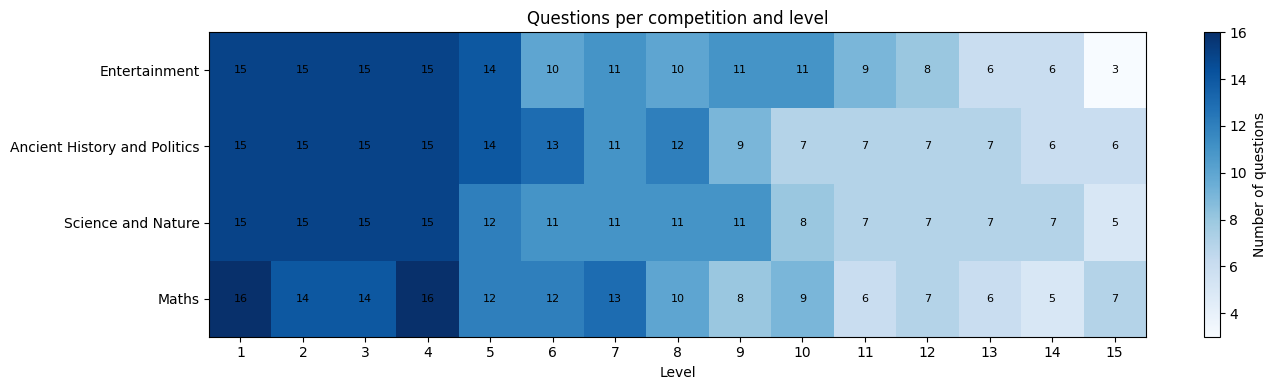

In [ ]:
def plot_competition_level_chart(df):
    level_order = list(range(1, 16))
    heatmap_data = (
        df
        .groupby(["competition", "level"])
        .size()
        .unstack(fill_value=0)
        .reindex(index=COMPETITIONS_ORDER, columns=level_order, fill_value=0)
    )
    plt.figure(figsize=(14, 4))
    im = plt.imshow(heatmap_data, aspect="auto", cmap="Blues")
    plt.xticks(range(len(level_order)), level_order)
    plt.yticks(range(len(COMPETITIONS_ORDER)), COMPETITIONS_ORDER)
    plt.xlabel("Level")
    plt.title("Questions per competition and level")
    cbar = plt.colorbar(im)
    cbar.set_label("Number of questions")
    for i in range(heatmap_data.shape[0]):
        for j in range(heatmap_data.shape[1]):
            count = heatmap_data.iloc[i, j]
            plt.text(j, i, str(count), ha="center", va="center", fontsize=8)
    plt.tight_layout()
    plt.show()

plot_competition_level_chart(df)

While the fine-grained view is useful for understanding the exact structure of the dataset, evaluating model performance at the individual level would likely produce **noisy and unstable estimates**, especially for later levels where the number of available samples becomes relatively small.

To obtain more statistically robust comparisons, we aggregate levels into three broader difficulty bands:

- **Easy**: levels 1–5
- **Medium**: levels 6–10
- **Hard**: levels 11–15

This grouping is a heuristic approximation, using game progression as a proxy for question difficulty. While question level does not strictly guarantee intrinsic difficulty, it provides a practical and intuitive abstraction for analysis.

The aggregated view below confirms that the dataset remains reasonably balanced across competitions while **reducing variance** caused by small exact-level sample sizes. This representation will also be used later when comparing model performance across different difficulty bands.

In [ ]:
def level_to_difficulty(level):
    if 1 <= level <= 5:
        return "Easy"
    if 6 <= level <= 10:
        return "Medium"
    if 11 <= level <= 15:
        return "Hard"
    raise ValueError(f"Invalid question level: {level}. Expected an integer between 1 and 15.")

df["difficulty"] = df["level"].apply(level_to_difficulty)

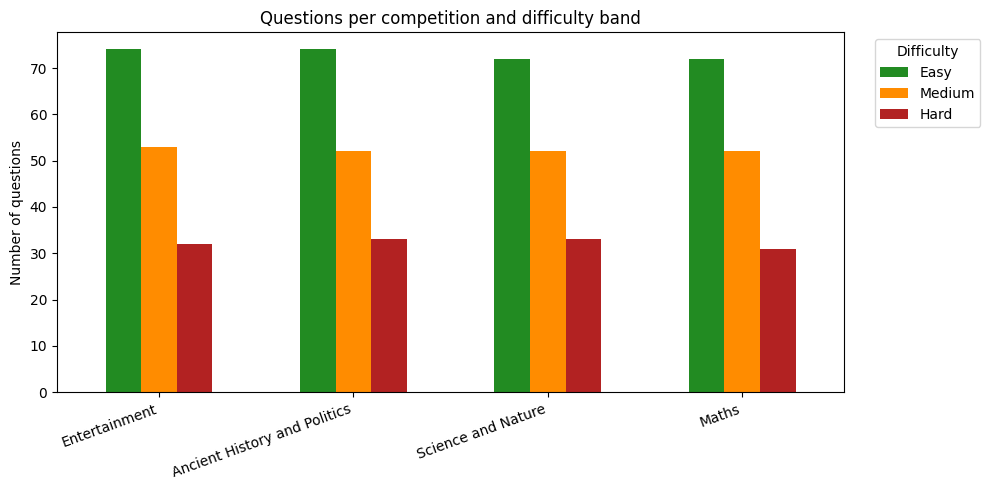

In [ ]:
DIFFICULTY_ORDER = ["Easy", "Medium", "Hard"]

def plot_competition_difficulty_chart(df, title="Questions per competition and difficulty band"):
    difficulty_counts = (
        df
        .groupby(["competition", "difficulty"])
        .size()
        .unstack(fill_value=0)
        .reindex(index=COMPETITIONS_ORDER, columns=DIFFICULTY_ORDER, fill_value=0)
    )
    ax = difficulty_counts.plot(
        kind="bar",
        stacked=False,
        figsize=(10, 5),
        width=0.55,
        color=["forestgreen", "darkorange", "firebrick"]
    )
    ax.set_xlabel("")
    plt.ylabel("Number of questions")
    plt.title(title)
    plt.xticks(rotation=20, ha="right")
    plt.legend(title="Difficulty", bbox_to_anchor=(1.03, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

plot_competition_difficulty_chart(df)

Since the dataset is relatively small, we reserve only a modest held-out **test set (15%)** for final offline evaluation, while using the majority of the data as a **validation set (85%)** for iterative model development. Final performance is assessed through live gameplay rather than relying exclusively on static offline metrics.

In [ ]:
def split_dataset(df, ratio):
    data_1 = []
    data_2 = []

    for _, group in df.groupby(["competition", "difficulty"]):
        group = group.sort_values("question_id")

        n = len(group)
        n1 = int(n * ratio)

        data_1.append(group.iloc[:n1])
        data_2.append(group.iloc[n1:])

    df1 = pd.concat(data_1, ignore_index=True)
    df2 = pd.concat(data_2, ignore_index=True)

    return df1, df2


validation_df, test_df = split_dataset(df, ratio=0.85)
total = len(validation_df) + len(test_df)

print(f"Validation set size: {len(validation_df)} ({len(validation_df) / total:.1%})")
print(f"Test set size: {len(test_df)} ({len(test_df) / total:.1%})")

Validation set size: 532 (84.4%)
Test set size: 98 (15.6%)


The split preserves the **original dataset distribution** across competitions and aggregated difficulty bands.

In [ ]:
def print_split_summary(validation_df, test_df):
    header = f"{'Category':<30} {'Validation %':>12} {'Test %':>10}"

    for column in ["competition", "difficulty"]:
        summary = pd.DataFrame({
            "Validation %": validation_df[column].value_counts(normalize=True) * 100,
            "Test %": test_df[column].value_counts(normalize=True) * 100,
        }).round(1)

        print(f"\nDistribution by {column}:")
        print(header)

        for idx, row in summary.iterrows():
            print(f"{idx:<30} {row['Validation %']:>11.1f}% {row['Test %']:>9.1f}%")


print_split_summary(validation_df, test_df)


Distribution by competition:
Category                       Validation %     Test %
Ancient History and Politics          25.2%      25.5%
Entertainment                         25.2%      25.5%
Maths                                 24.6%      24.5%
Science and Nature                    25.0%      24.5%

Distribution by difficulty:
Category                       Validation %     Test %
Easy                                  46.2%      46.9%
Medium                                33.3%      32.7%
Hard                                  20.5%      20.4%


# 3. Base LLMs Comparison

In [ ]:
class ParseStatus(str, Enum):
    SUCCESS = "success"
    WARNING = "warning"
    ERROR = "error"


def build_numeric_options_str(question, competition, first_option_id=1):
    return "\n".join(
        f"{opt.id + first_option_id}) {opt.text}"
        for opt in question.options
      )


def build_base_llm_prompt(question, competition):
    options_str = build_numeric_options_str(question, competition, first_option_id=1)
    return [
        {
            "role": "system",
            "content": (
                "You are a quiz expert. Answer the following multiple choice question.\n"
                "Reply with ONLY the number of the correct option, nothing else.\n"
            )
        },
        {
            "role": "user",
            "content": (
                f"Topic: {competition}\n\n"
                f"Question: {question.text}\n\n"
                f"Options:\n{options_str}\n\n"
                "Answer (from 1 to 4):"
            )
        }
    ]


def parse_simple_answer(raw_output):
    cleaned = raw_output.strip()

    success_patterns = [
        r"^\s*([1-4])(?:\b|[\).\]:,-])", # 2 + puncuation character
        r"\bfinal answer\s*:?\s*([1-4])\b", # Final answer: 2
        r"\banswer\s*:?\s*([1-4])\b", # Answer: 2
        r"\b(?:the\s+)?correct answer(?:\s+is)?\s*:?\s*([1-4])\b", # The correct answer is 2
        r"\boption\s*([1-4])\b", # Option 2
    ]

    for pattern in success_patterns:
        matches = re.search(pattern, cleaned, re.IGNORECASE)
        if matches:
            return int(matches.group(1)) - 1, ParseStatus.SUCCESS

    matches = re.findall(r"\b([1-4])\b", cleaned)
    if len(matches) == 1:
        return int(matches[0]) - 1, ParseStatus.WARNING

    return None, ParseStatus.ERROR


@torch.inference_mode()
def invoke_llm(llm_model, tokenizer, messages, max_new_tokens=8, do_sample=False):
    inputs = tokenizer.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_tensors="pt",
        return_dict=True,
    ).to(llm_model.device)

    gen_kwargs = {
        "max_new_tokens": max_new_tokens,
        "do_sample": do_sample,
        "temperature": None,
        "top_k": None,
        "top_p": None,
        "pad_token_id": tokenizer.eos_token_id,
        "eos_token_id": tokenizer.eos_token_id,
        "use_cache": True,
    }

    output_ids = llm_model.generate(**inputs, **gen_kwargs)
    generated_ids = output_ids[0][inputs["input_ids"].shape[-1]:]

    return tokenizer.decode(generated_ids, skip_special_tokens=True).strip()


def solve_with_llm(
    question,
    competition,
    llm_model,
    tokenizer,
    prompt_builder,
    parser=parse_simple_answer,
    verbose=False
):
    messages = prompt_builder(question, competition)

    t0 = time.time()
    raw_output = invoke_llm(
        llm_model=llm_model,
        tokenizer=tokenizer,
        messages=messages,
        max_new_tokens=8,
        do_sample=False,
    )
    elapsed = time.time() - t0

    chosen_id, parse_status = parser(raw_output)

    if verbose:
        print(f"  Prompt        : {messages}")
        print(f"  Raw output    : {raw_output.strip()}")
        print(f"  Chosen option : {chosen_id}")
        print(f"  Parse status  : {parse_status.value}")
        print(f"  Latency       : {elapsed:.2f}s")

    return {
        "chosen_id": chosen_id,
        "raw_output": raw_output,
        "parse_status": parse_status.value,
        "latency_seconds": elapsed,
    }

In [ ]:
def evaluate_chatbot(
    df,
    chatbot_fn,
    model_id,
    output_dir,
    experiment_name=None,
    exclude_competitions=None,
    chatbot_kwargs=None,
    verbose=False
):
    if chatbot_kwargs is None:
        chatbot_kwargs = {}

    if exclude_competitions is not None:
        df = df[~df["competition"].isin(exclude_competitions)].copy()

    log_path = get_log_path(
        output_dir=output_dir,
        file_id=model_id,
        experiment_name=experiment_name,
    )

    logs_df = load_existing_logs(log_path)

    completed_ids = set(logs_df["question_id"]) if len(logs_df) > 0 else set()
    rows_to_run = df[~df["question_id"].isin(completed_ids)].copy()

    print(f"Log path          : {log_path}")
    print(f"Already completed : {len(completed_ids)}")
    print(f"Remaining         : {len(rows_to_run)}")

    for j, (_, row) in enumerate(tqdm(rows_to_run.iterrows(), total=len(rows_to_run))):
        result = chatbot_fn(
            question=row["question"],
            competition=row["competition"],
            verbose=(verbose and j == 0),
            **chatbot_kwargs,
        )

        predicted_answer = result["chosen_id"]
        is_correct = (
            predicted_answer == row["correct_option_id"]
            if predicted_answer is not None
            else False
        )

        record = {
            "model_id": model_id,
            "experiment_name": experiment_name,
            "question_id": int(row["question_id"]),
            "competition": row["competition"],
            "level": int(row["level"]),
            "correct_option_id": int(row["correct_option_id"]),
            "predicted_answer": (
                int(predicted_answer)
                if predicted_answer is not None
                else None
            ),
            "is_correct": bool(is_correct),
            **result,
        }

        append_log(log_path, record)

In [ ]:
BASE_MODELS_LOGS_DIR = os.path.join(VALIDATION_LOGS_DIR, "base_models")

# evaluate_chatbot(
#     df=validation_df,
#     chatbot_fn=solve_with_llm,
#     model_id=MODEL_ID,
#     output_dir=BASE_MODELS_LOGS_DIR,
#     chatbot_kwargs={
#         "llm_model": llm_model,
#         "tokenizer": tokenizer,
#         "prompt_builder": build_base_llm_prompt,
#     },
# )

In [ ]:
def build_display_model_id(row):
    experiment_name = row.get("experiment_name")
    if experiment_name:
        return f"{experiment_name} | {row['model_id']}"
    return row["model_id"]

base_logs_df = load_existing_logs(BASE_MODELS_LOGS_DIR)
base_logs_df["difficulty"] = base_logs_df["level"].apply(level_to_difficulty)
base_logs_df["display_model_id"] = base_logs_df.apply(build_display_model_id, axis=1)

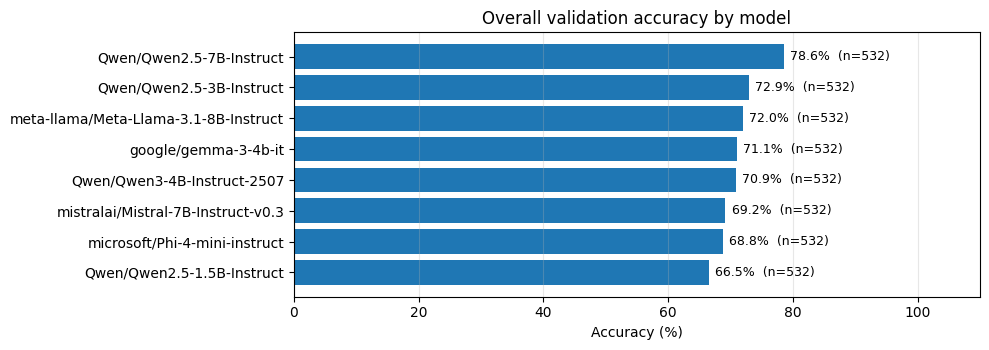

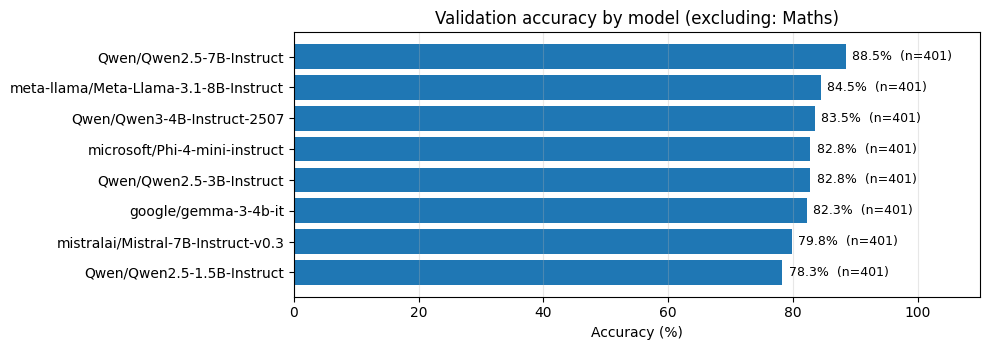

In [ ]:
def plot_overall_accuracy(df, exclude_competitions=None, display_order=None,):
    plot_df = df.copy()
    if exclude_competitions is not None:
        plot_df = plot_df[~plot_df["competition"].isin(exclude_competitions)]
    acc_df = (
        plot_df
        .groupby("display_model_id", as_index=False)
        .agg(
            accuracy=("is_correct", "mean"),
            n_questions=("is_correct", "size"),
        )
    )
    if display_order is not None:
        ordered_ids = [x for x in display_order if x in set(acc_df["display_model_id"])]
        remaining_ids = [x for x in acc_df["display_model_id"] if x not in set(ordered_ids)]
        final_order = ordered_ids + remaining_ids
        acc_df = (
            acc_df
            .set_index("display_model_id")
            .loc[final_order]
            .reset_index()
        )
    else:
        acc_df = acc_df.sort_values("accuracy", ascending=True)
    fig, ax = plt.subplots(figsize=(10, max(3, 0.45 * len(acc_df))))
    bars = ax.barh(acc_df["display_model_id"], acc_df["accuracy"] * 100)
    if exclude_competitions:
        excluded = ", ".join(exclude_competitions)
        ax.set_title(f"Validation accuracy by model (excluding: {excluded})")
    else:
        ax.set_title("Overall validation accuracy by model")
    ax.set_xlabel("Accuracy (%)")
    ax.set_xlim(0, 110)
    for bar, acc, n in zip(bars, acc_df["accuracy"], acc_df["n_questions"]):
        ax.text(
            bar.get_width() + 1,
            bar.get_y() + bar.get_height() / 2,
            f"{acc * 100:.1f}%  (n={n})",
            va="center",
            fontsize=9,
        )
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_overall_accuracy(base_logs_df)
plot_overall_accuracy(base_logs_df, exclude_competitions=["Maths"])

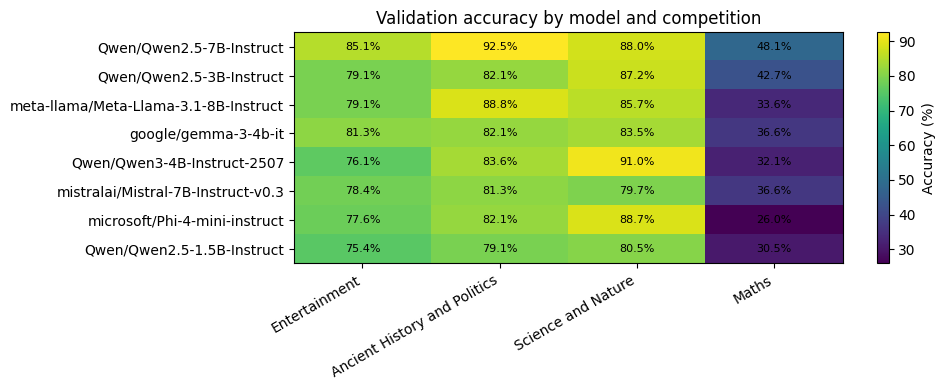

In [ ]:
def plot_accuracy_heatmap(pivot_df, title):
    figsize = (10, max(4, 0.45 * len(pivot_df)))
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(pivot_df.values * 100, aspect="auto")
    ax.set_xticks(np.arange(len(pivot_df.columns)))
    ax.set_yticks(np.arange(len(pivot_df.index)))
    ax.set_xticklabels(pivot_df.columns)
    ax.set_yticklabels(pivot_df.index)
    ax.set_title(title)
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
    for i in range(len(pivot_df.index)):
        for j in range(len(pivot_df.columns)):
            value = pivot_df.iloc[i, j]
            if pd.notna(value):
                ax.text(j, i, f"{value * 100:.1f}%", ha="center", va="center", fontsize=8)
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Accuracy (%)")
    plt.tight_layout()
    plt.show()

def plot_competition_accuracy_heatmap(df, exclude_competitions=None, display_order=None):
    plot_df = df.copy()
    if exclude_competitions is not None:
        plot_df = plot_df[~plot_df["competition"].isin(exclude_competitions)]
    competition_acc = (
        plot_df
        .groupby(["display_model_id", "competition"])["is_correct"]
        .mean()
        .unstack()
        .reindex(columns=COMPETITIONS_ORDER)
    )
    if display_order is not None:
        ordered_ids = [
            x for x in display_order
            if x in set(competition_acc.index)
        ]
        remaining_ids = [
            x for x in competition_acc.index
            if x not in set(ordered_ids)
        ]

        final_order = ordered_ids + remaining_ids
    else:
        final_order = (
            plot_df
            .groupby("display_model_id")["is_correct"]
            .mean()
            .sort_values(ascending=False)
            .index
        )
    competition_acc = competition_acc.loc[final_order]
    plot_accuracy_heatmap(competition_acc, title="Validation accuracy by model and competition")

plot_competition_accuracy_heatmap(base_logs_df)

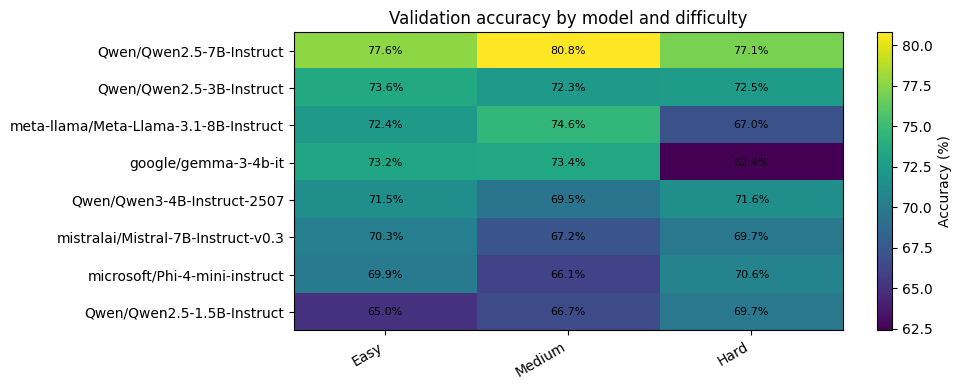

In [ ]:
def plot_difficulty_accuracy_heatmap(df, exclude_competitions=None):
    plot_df = df.copy()
    if exclude_competitions is not None:
        plot_df = plot_df[~plot_df["competition"].isin(exclude_competitions)]
    difficulty_acc = (
        plot_df
        .groupby(["display_model_id", "difficulty"])["is_correct"]
        .mean()
        .unstack()
        .reindex(columns=DIFFICULTY_ORDER)
    )
    model_order = (
        df
        .groupby("display_model_id")["is_correct"]
        .mean()
        .sort_values(ascending=False)
        .index
    )
    difficulty_acc = difficulty_acc.loc[model_order]
    plot_accuracy_heatmap(difficulty_acc, title="Validation accuracy by model and difficulty")

plot_difficulty_accuracy_heatmap(base_logs_df)

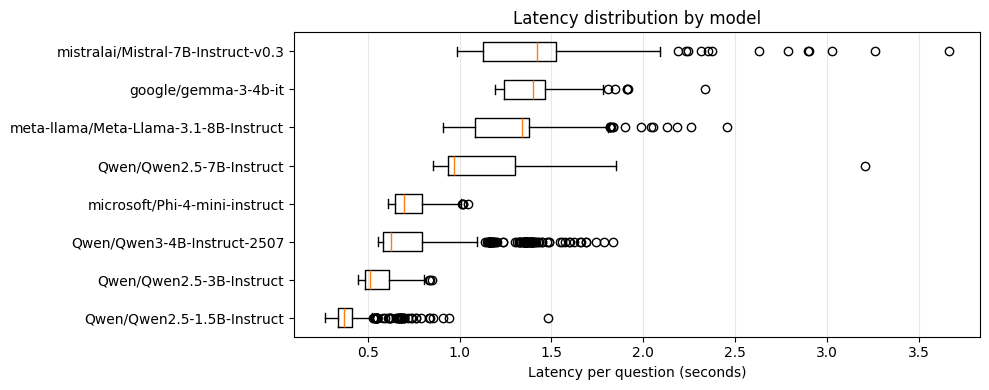

In [ ]:
def plot_latency_boxplot(
    df,
    show_timeout_line=False,
    column="latency_seconds",
    title="Latency distribution by model"
):
    model_order = (
        df
        .groupby("display_model_id")[column]
        .median()
        .sort_values(ascending=True)
        .index
    )
    data = [
        df.loc[df["display_model_id"] == model_id, column].values
        for model_id in model_order
    ]
    fig, ax = plt.subplots(figsize=(10, max(4, 0.45 * len(model_order))))
    ax.boxplot(data, vert=False, tick_labels=model_order, showfliers=True)
    if show_timeout_line:
        ax.axvline(30, color="red", linestyle="--", linewidth=2, label="30s timeout")
    ax.set_xlabel("Latency per question (seconds)")
    ax.set_title(title)
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_latency_boxplot(base_logs_df)

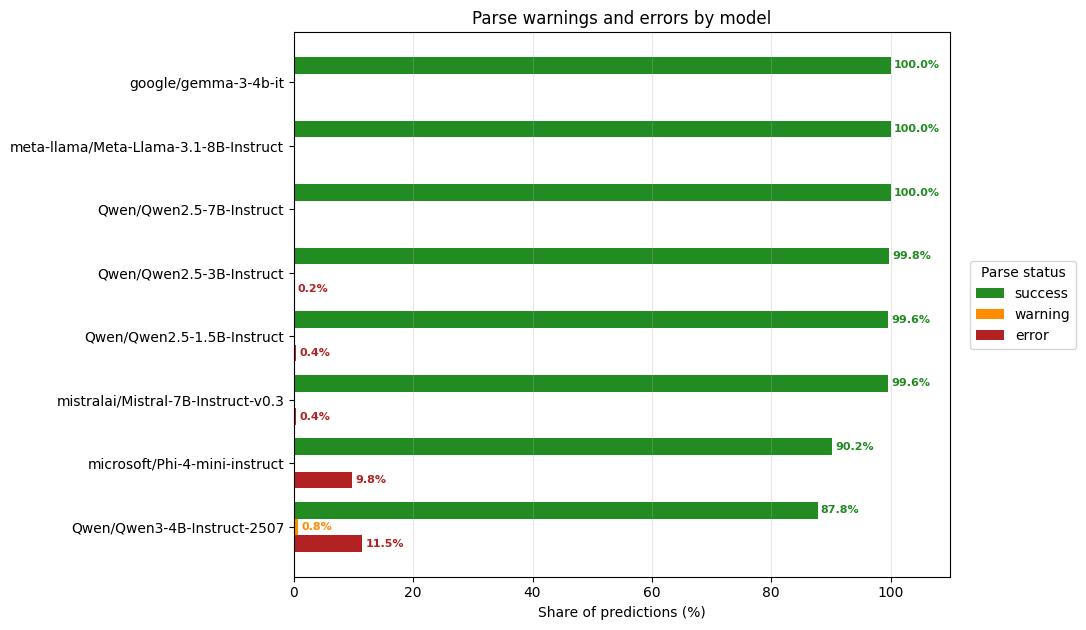

In [ ]:
PARSE_ORDER = ["success", "warning", "error"]
STATUS_COLOR = {"success": "forestgreen", "warning": "darkorange", "error": "firebrick"}

def plot_parse_outcome_bars(df):
    parse_counts = (
        df
        .groupby(["display_model_id", "parse_status"])
        .size()
        .unstack(fill_value=0)
        .reindex(columns=PARSE_ORDER, fill_value=0)
    )
    parse_rates = parse_counts.div(parse_counts.sum(axis=1), axis=0) * 100
    model_order = parse_rates["success"].sort_values(ascending=True).index
    parse_rates = parse_rates.loc[model_order]
    group_spacing = 1.6
    y = np.arange(len(parse_rates)) * group_spacing
    bar_height = 0.42
    offsets = {"success": bar_height, "warning": 0, "error": -bar_height}
    fig, ax = plt.subplots(figsize=(11, max(3, 0.8 * len(parse_rates))))
    for status in PARSE_ORDER:
        values = parse_rates[status].values
        ax.barh(
            y + offsets[status],
            values,
            height=bar_height,
            label=status,
            color=STATUS_COLOR[status],
        )
        for i, value in enumerate(values):
            if value > 0:
                ax.text(
                    value + 0.5,
                    y[i] + offsets[status],
                    f"{value:.1f}%",
                    va="center",
                    fontsize=8,
                    color=STATUS_COLOR[status],
                    fontweight="bold",
                )
    ax.set_yticks(y)
    ax.set_yticklabels(parse_rates.index)
    ax.set_xlabel("Share of predictions (%)")
    ax.set_title("Parse warnings and errors by model")
    ax.grid(axis="x", alpha=0.3)
    ax.set_xlim(0, 110)
    ax.legend(title="Parse status", bbox_to_anchor=(1.02, 0.5), loc="center left")
    plt.tight_layout()
    plt.show()

plot_parse_outcome_bars(base_logs_df)

# 4. Prompt Engineering

In [ ]:
BASELINE_LOG_FILE = os.path.join(BASE_MODELS_LOGS_DIR, "Qwen_Qwen2.5-7B-Instruct.json")

## Answer Encoding: Numbers vs Letters

Changing the answer encoding (numeric 1–4, letters A–D, or zero-indexed 0–3) had negligible impact on overall performance, suggesting that `Qwen2.5-7B-Instruct` is robust to different output conventions and follows formatting instructions reliably.

One interesting exception is the Maths category, where the letter-based prompt achieved a modest improvement (51.9% vs 48.1% baseline). A plausible explanation is that numerical answer labels may introduce additional ambiguity in arithmetic questions, where numbers already dominate the question content and reasoning process. In contrast, letter labels cleanly separate the model’s internal numerical reasoning from the output encoding.

However, the observed difference corresponds to only a small number of additional correct answers on the validation subset, so this should be interpreted as an interesting hypothesis rather than strong evidence of a systematic effect.

In [ ]:
def parse_letter_answer(raw_output):
    cleaned = raw_output.strip()

    success_patterns = [
        r"^\s*([A-D])(?:\b|[\).\]:,-])",
        r"\banswer\s*:?\s*([A-D])\b",
        r"\b(?:the\s+)?correct answer(?:\s+is)?\s*:?\s*([A-D])\b",
        r"\boption\s*([A-D])\b",
    ]

    for pattern in success_patterns:
        matches = re.search(pattern, cleaned, re.IGNORECASE)
        if matches:
            return ord(matches.group(1).upper()) - ord("A"), ParseStatus.SUCCESS

    matches = re.findall(r"\b([A-D])\b", cleaned, re.IGNORECASE)
    if len(matches) == 1:
        return ord(matches[0].upper()) - ord("A"), ParseStatus.WARNING

    return None, ParseStatus.ERROR


def build_letter_options_str(question, competition):
    return "\n".join(
        f"{chr(ord('A') + opt.id)}) {opt.text}"
        for opt in question.options
    )


def build_prompt_letters(question, competition):
    options_str = build_letter_options_str(question, competition)

    return [
        {
            "role": "system",
            "content": (
                "You are a quiz expert. Answer the following multiple choice question.\n"
                "Reply with ONLY the letter of the correct option, nothing else.\n"
            ),
        },
        {
            "role": "user",
            "content": (
                f"Topic: {competition}\n\n"
                f"Question: {question.text}\n\n"
                f"Options:\n{options_str}\n\n"
                "Answer (A, B, C, or D):"
            ),
        },
    ]


def parse_zero_indexed_answer(raw_output):
    cleaned = raw_output.strip()

    success_patterns = [
        r"^\s*([0-3])(?:\b|[\).\]:,-])",
        r"\bfinal answer\s*:?\s*([0-3])\b",
        r"\banswer\s*:?\s*([0-3])\b",
        r"\b(?:the\s+)?correct answer(?:\s+is)?\s*:?\s*([0-3])\b",
        r"\boption\s*([0-3])\b",
    ]

    for pattern in success_patterns:
        matches = re.search(pattern, cleaned, re.IGNORECASE)
        if matches:
            return int(matches.group(1)), ParseStatus.SUCCESS

    matches = re.findall(r"\b([0-3])\b", cleaned)
    if len(matches) == 1:
        return int(matches[0]), ParseStatus.WARNING

    return None, ParseStatus.ERROR


def build_prompt_zero_indexed(question, competition):
    options_str = build_numeric_options_str(question, competition, first_option_id=0)
    return [
        {
            "role": "system",
            "content": (
                "You are a quiz expert. Answer the following multiple choice question.\n"
                "Reply with ONLY the number of the correct option, nothing else.\n"
            )
        },
        {
            "role": "user",
            "content": (
                f"Topic: {competition}\n\n"
                f"Question: {question.text}\n\n"
                f"Options:\n{options_str}\n\n"
                "Answer (from 0 to 3):"
            )
        }
    ]

In [ ]:
ANSWER_ENCODING_LOGS_DIR = os.path.join(VALIDATION_LOGS_DIR, "answer_encoding")

EXPERIMENTS = {
    "letters_options": {
        "prompt_builder": build_prompt_letters,
        "parser": parse_letter_answer,
    },
    "zero_indexed_options": {
        "prompt_builder": build_prompt_zero_indexed,
        "parser": parse_zero_indexed_answer,
    },
}

# for experiment_name, config in EXPERIMENTS.items():
#     print("=" * 80)
#     print(f"Running experiment: {experiment_name}")
#     print("=" * 80)

#     evaluate_chatbot(
#         df=validation_df,
#         chatbot_fn=solve_with_llm,
#         model_id=MODEL_ID,
#         output_dir=ANSWER_ENCODING_LOGS_DIR,
#         experiment_name=experiment_name,
#         chatbot_kwargs={
#             "llm_model": llm_model,
#             "tokenizer": tokenizer,
#             "prompt_builder": config["prompt_builder"],
#             "parser": config["parser"],
#         },
#         verbose=True,
#     )

## Zero Shot, One Shot, Few Shot

**Few-shot prompts did not provide a significant improvement on our benchmark:**
- Baseline zero-shot prompt (**78.6%** accuracy)
- One-shot prompting slightly reduced performance (**77.4%**)
- Four-shot prompt yielded a negligible improvement (**78.8%**).

A potential concern with one-shot prompting is that the single example may bias the model toward its correct answer (option 2 in this case). While the frequency of predicted option 2 increased slightly (**+1.2%** compared to the baseline), the overall answer distribution remained broadly consistent, suggesting that no strong imitation effect was introduced.

Few-shot prompts also slightly increase inference latency due to the longer input context, with one-shot and especially four-shot prompts being slower than the baseline. Since the accuracy gains are negligible while computational cost increases a little bit, the baseline zero-shot prompt remains the best choice for subsequent experiments.

In [ ]:
def build_prompt_one_shot(question, competition):
    options_str = build_numeric_options_str(question, competition)

    return [
        {
            "role": "system",
            "content": (
                "You are a quiz expert. Answer multiple choice questions.\n"
                "Reply with ONLY the number of the correct option, nothing else.\n"
            ),
        },
        {
            "role": "user",
            "content": (
                "Example:\n"
                "Topic: Science and Nature\n"
                "Question: Which planet is known as the Red Planet?\n"
                "Options:\n"
                "1) Venus\n"
                "2) Mars\n"
                "3) Jupiter\n"
                "4) Saturn\n"
                "Answer: 2\n\n"

                f"Topic: {competition}\n\n"
                f"Question: {question.text}\n\n"
                f"Options:\n{options_str}\n\n"
                "Answer:"
            ),
        },
    ]


def build_prompt_four_shot(question, competition):
    options_str = build_numeric_options_str(question, competition)

    examples = (
        "Example 1:\n"
        "Topic: Science and Nature\n"
        "Question: Which planet is known as the Red Planet?\n"
        "Options:\n"
        "1) Venus\n"
        "2) Mars\n"
        "3) Jupiter\n"
        "4) Saturn\n"
        "Answer: 2\n\n"

        "Example 2:\n"
        "Topic: Maths\n"
        "Question: What is 9 × 8?\n"
        "Options:\n"
        "1) 56\n"
        "2) 63\n"
        "3) 64\n"
        "4) 72\n"
        "Answer: 4\n\n"

        "Example 3:\n"
        "Topic: Ancient History and Politics\n"
        "Question: Who was the first emperor of Rome?\n"
        "Options:\n"
        "1) Augustus\n"
        "2) Julius Caesar\n"
        "3) Nero\n"
        "4) Hadrian\n"
        "Answer: 1\n\n"

        "Example 4:\n"
        "Topic: Entertainment\n"
        "Question: In cinema, who directed Titanic?\n"
        "Options:\n"
        "1) Steven Spielberg\n"
        "2) Christopher Nolan\n"
        "3) James Cameron\n"
        "4) Martin Scorsese\n"
        "Answer: 3\n\n"
    )

    return [
        {
            "role": "system",
            "content": (
                "You are a quiz expert. Answer multiple choice questions.\n"
                "Reply with ONLY the number of the correct option, nothing else.\n"
            ),
        },
        {
            "role": "user",
            "content": (
                examples
                + "Now answer the following question.\n\n"
                + f"Topic: {competition}\n\n"
                + f"Question: {question.text}\n\n"
                + f"Options:\n{options_str}\n\n"
                + "Answer:"
            ),
        },
    ]

In [ ]:
SHOTS_LOGS_DIR = os.path.join(VALIDATION_LOGS_DIR, "shots")

EXPERIMENTS = {
    "one_shot": {
        "prompt_builder": build_prompt_one_shot,
    },
    "four_shot": {
        "prompt_builder": build_prompt_four_shot,
    },
}

# for experiment_name, config in EXPERIMENTS.items():
#     print("=" * 80)
#     print(f"Running experiment: {experiment_name}")
#     print("=" * 80)

#     evaluate_chatbot(
#         df=validation_df,
#         chatbot_fn=solve_with_llm,
#         model_id=MODEL_ID,
#         output_dir=SHOTS_LOGS_DIR,
#         experiment_name=experiment_name,
#         chatbot_kwargs={
#             "llm_model": llm_model,
#             "tokenizer": tokenizer,
#             "prompt_builder": config["prompt_builder"],
#         },
#         verbose=True,
#     )

In [ ]:
shots_logs_df = load_existing_logs([BASELINE_LOG_FILE, SHOTS_LOGS_DIR])
shots_logs_df["difficulty"] = shots_logs_df["level"].apply(level_to_difficulty)
shots_logs_df["display_model_id"] = shots_logs_df.apply(build_display_model_id, axis=1)

In [ ]:
def answer_distribution_delta_vs_baseline(df, baseline_df, title=""):
    baseline_predicted_dist = (
        baseline_df[baseline_df["predicted_answer"].notna()]["predicted_answer"]
        .astype(int)
        .value_counts(normalize=True)
        .reindex(range(4), fill_value=0)
        * 100
    )

    predicted_dist = (
        df[df["predicted_answer"].notna()]["predicted_answer"]
        .astype(int)
        .value_counts(normalize=True)
        .reindex(range(4), fill_value=0)
        * 100
    )

    summary = pd.DataFrame({
        "baseline predicted %": baseline_predicted_dist,
        "experiment predicted %": predicted_dist,
    })

    summary["delta vs baseline %"] = (
        summary["experiment predicted %"] - summary["baseline predicted %"]
    )

    summary.index = ["1", "2", "3", "4"]

    print("\n")
    print(title)
    display(summary.round(1))


baseline_df = shots_logs_df[shots_logs_df["experiment_name"].isna()]

answer_distribution_delta_vs_baseline(
    shots_logs_df[shots_logs_df["experiment_name"] == "one_shot"],
    baseline_df=baseline_df,
    title="One shot vs Baseline answer distribution",
)

answer_distribution_delta_vs_baseline(
    shots_logs_df[shots_logs_df["experiment_name"] == "four_shot"],
    baseline_df=baseline_df,
    title="Four shot vs Baseline answer distribution",
)



One shot vs Baseline answer distribution


,baseline predicted %,experiment predicted %,delta vs baseline %
1,25.9,25.6,-0.3
2,25.2,26.4,1.2
3,22.6,22.0,-0.5
4,26.3,26.0,-0.3




Four shot vs Baseline answer distribution


,baseline predicted %,experiment predicted %,delta vs baseline %
1,25.9,26.1,0.2
2,25.2,25.0,-0.2
3,22.6,23.3,0.8
4,26.3,25.6,-0.8


## Chain of Thought

Chain-of-Thought was considered, but generating long reasoning traces consistently exceeded the 30-second latency limit, making it impractical for the target live-game setting. We therefore evaluate lightweight reasoning-oriented prompts that encourage internal deliberation while preserving short outputs.

## Other

In [ ]:
def build_prompt_no_expert(question, competition):
    options_str = build_numeric_options_str(question, competition)

    return [
        {
            "role": "system",
            "content": (
                "Answer the following multiple choice question.\n"
                "Reply with ONLY the number of the correct option, nothing else.\n"
            ),
        },
        {
            "role": "user",
            "content": (
                f"Topic: {competition}\n\n"
                f"Question: {question.text}\n\n"
                f"Options:\n{options_str}\n\n"
                "Answer (from 1 to 4):"
            ),
        },
    ]


def build_prompt_no_topic(question, competition):
    options_str = build_numeric_options_str(question, competition)

    return [
        {
            "role": "system",
            "content": (
                "You are a quiz expert. Answer the following multiple choice question.\n"
                "Reply with ONLY the number of the correct option, nothing else.\n"
            ),
        },
        {
            "role": "user",
            "content": (
                f"Question: {question.text}\n\n"
                f"Options:\n{options_str}\n\n"
                "Answer (from 1 to 4):"
            ),
        },
    ]

In [ ]:
OTHER_PROMPT_EXPERIMENTS_LOGS_DIR = os.path.join(VALIDATION_LOGS_DIR, "other_prompt_experiments")

EXPERIMENTS = {
    "no_expert": {
        "prompt_builder": build_prompt_no_expert,
    },
    "no_topic": {
        "prompt_builder": build_prompt_no_topic,
    },
}

for experiment_name, config in EXPERIMENTS.items():
    print("=" * 80)
    print(f"Running experiment: {experiment_name}")
    print("=" * 80)

    # evaluate_chatbot(
    #     df=validation_df,
    #     chatbot_fn=solve_with_llm,
    #     model_id=MODEL_ID,
    #     output_dir=OTHER_PROMPT_EXPERIMENTS_LOGS_DIR,
    #     experiment_name=experiment_name,
    #     chatbot_kwargs={
    #         "llm_model": llm_model,
    #         "tokenizer": tokenizer,
    #         "prompt_builder": config["prompt_builder"],
    #     },
    #     verbose=True,
    # )

Running experiment: no_expert
Running experiment: no_topic


## Evaluation

In [ ]:
prompt_experiments_logs_df = load_existing_logs([
    BASELINE_LOG_FILE,
    ANSWER_ENCODING_LOGS_DIR,
    SHOTS_LOGS_DIR,
    OTHER_PROMPT_EXPERIMENTS_LOGS_DIR,
])

prompt_experiments_logs_df["difficulty"] = prompt_experiments_logs_df["level"].apply(level_to_difficulty)
prompt_experiments_logs_df["display_model_id"] = prompt_experiments_logs_df.apply(build_display_model_id, axis=1)

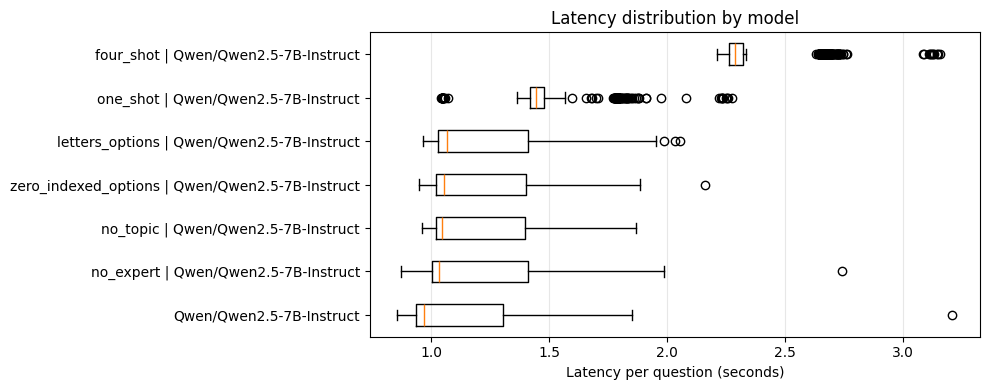

In [ ]:
plot_latency_boxplot(prompt_experiments_logs_df)

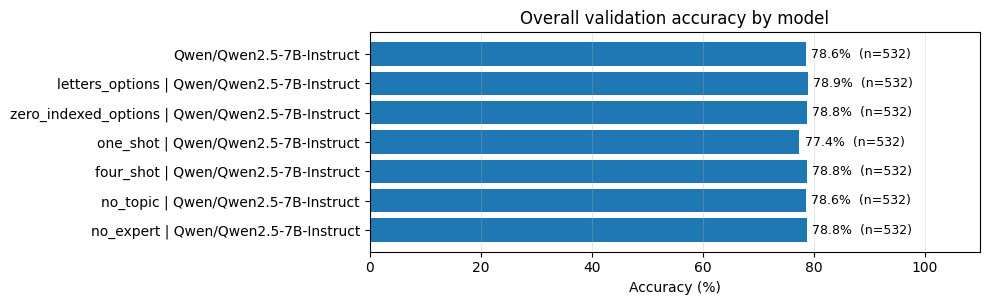

In [ ]:
plot_overall_accuracy(prompt_experiments_logs_df, display_order=[
    "no_expert | Qwen/Qwen2.5-7B-Instruct",
    "no_topic | Qwen/Qwen2.5-7B-Instruct",
    "four_shot | Qwen/Qwen2.5-7B-Instruct",
    "one_shot | Qwen/Qwen2.5-7B-Instruct",
    "zero_indexed_options | Qwen/Qwen2.5-7B-Instruct",
    "letters_options | Qwen/Qwen2.5-7B-Instruct",
    "Qwen/Qwen2.5-7B-Instruct",
])

# 5. RAG

## Wikipedia Search Strategies

Before integrating Wikipedia retrieval into the full RAG pipeline, we evaluated the quality of the Wikipedia search stage in isolation. Each search strategy produced a JSONL log containing the generated Wikipedia queries and the returned page titles for every question.

The evaluation then was performed only by looking at the question, the options, and the page titles, without inspecting page contents. Therefore, the results should be interpreted as a heuristic evaluation of the search stage, not as a definitive measurement of final RAG performance.

This stage was useful because later retrieval components can filter noisy pages, but they cannot recover a relevant Wikipedia page that was never retrieved in the first place.

Among the simple deterministic strategies, the best approach we found was to use `spaCy` to extract noun chunks from the question alone, and then use each extracted noun chunk and and each question option as Wikipedia search query. This produced more focused entity-oriented searches than using the full question alone.

Later, however, we moved from these hand-designed deterministic queries to queries generated by an LLM, in order to obtain more flexible and semantically targeted Wikipedia searches.

In [ ]:
DETERMINISTIC_SEARCH_STRATEGIES = [
    "question",
    "question_all_options",
    "competition_question_all_options",
    "question_each_option",
    "competition_question_each_option",
    "no_stopwords_question",
    "no_stopwords_question_each_option",
    "each_option",
    "spacy_noun_chunks_question",
    "spacy_noun_chunks_blocklist_question",
]

OTHER_SEARCH_STRATEGIES = [
    "baseline_llm_written_queries"
]

SEARCH_STRATEGIES = DETERMINISTIC_SEARCH_STRATEGIES + OTHER_SEARCH_STRATEGIES

In [ ]:
WIKIPEDIA_MAX_QUERY_LEN = 300


def with_retry(fn, *args, retries=3, base_backoff=1.0, verbose=False, context=None, **kwargs):
    context_msg = f" [{context}]" if context else ""
    retry_count = 0
    max_attempts = retries + 1

    for attempt in range(1, max_attempts + 1):
        try:
            return fn(*args, **kwargs), retry_count

        except requests.exceptions.HTTPError as e:
            response = e.response
            status = response.status_code if response else None

            if status in [429, 503]:
                retry_after = response.headers.get("Retry-After")
                if retry_after:
                    wait = float(retry_after)
                else:
                    wait = base_backoff * (2 ** (attempt - 1))
                wait += random.uniform(0, 1)
                if verbose:
                    print(
                        f"[{fn.__name__}] HTTP {status}{context_msg} "
                        f"(attempt {attempt}/{retries}) -> retrying in {wait:.2f}s"
                    )
                retry_count += 1
                time.sleep(wait)

            else:
                if verbose:
                    print(
                        f"[{fn.__name__}] HTTP {status}{context_msg} "
                        f"(attempt {attempt}/{retries}) -> giving up"
                    )
                return None, retry_count

        except (requests.exceptions.Timeout, requests.exceptions.ConnectionError) as e:
            wait = base_backoff * (2 ** (attempt - 1)) + random.uniform(0, 1)
            if verbose:
                print(
                    f"[{fn.__name__}] {type(e).__name__}{context_msg} "
                    f"(attempt {attempt}/{retries}) -> retrying in {wait:.2f}s"
                )
            retry_count += 1
            time.sleep(wait)

    if verbose:
        print(f"[{fn.__name__}] failed after {max_attempts} attempts {context_msg}")

    return None, retry_count


def truncate_wikipedia_query(query, max_len=WIKIPEDIA_MAX_QUERY_LEN):
    if len(query) <= max_len:
        return query

    truncated = query[:max_len]
    last_space = truncated.rfind(" ")

    if last_space > 0:
        truncated = truncated[:last_space]

    return truncated


@lru_cache(maxsize=4096)
def search_wikipedia(query, pages_per_query, verbose=False):
    normalized_query = re.sub(r"\s+", " ", query).strip()

    query = truncate_wikipedia_query(normalized_query)
    truncated = len(query) < len(normalized_query)

    if verbose and truncated:
        print(
            f"[search_wikipedia] truncated query "
            f"from {len(normalized_query)} to {len(query)} chars"
        )

    def helper():
        r = SESSION.get(
            WIKIPEDIA_URL,
            params={
                "action": "query",
                "format": "json",
                "list": "search",
                "srsearch": query,
                "srlimit": pages_per_query,
            },
            timeout=10,
        )
        r.raise_for_status()
        data = r.json()

        if "error" in data:
            if verbose:
                print(f"Wikipedia API error for query={query!r}: {data['error']}")
            return {
                "titles": [],
                "query_truncated": truncated,
                "wikipedia_error": True,
                "error_code": data["error"].get("code"),
            }

        if "query" not in data or "search" not in data["query"]:
            if verbose:
                print(f"Unexpected Wikipedia response for query={query!r}: {data}")
            return {
                "titles": [],
                "query_truncated": truncated,
                "wikipedia_error": True,
                "error_code": "unexpected_response",
            }

        return {
            "titles": [item["title"] for item in data["query"]["search"]],
            "query_truncated": truncated,
            "wikipedia_error": False,
            "error_code": None,
        }


    result, retry_count = with_retry(
        helper,
        verbose=verbose,
        context=f"query={query!r}"
    )

    if result is None:
        return {
            "titles": [],
            "query_truncated": truncated,
            "wikipedia_error": True,
            "error_code": "request_failed",
            "retry_count": retry_count,
        }

    result["retry_count"] = retry_count
    return result

In [ ]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize


nltk.download("stopwords", quiet=True)
nltk.download("punkt", quiet=True)

STOPWORDS = set(stopwords.words("english"))
PRESERVE_WORDS = {"who", "which", "when", "where", "what", "how"}
STOPWORDS -= PRESERVE_WORDS


nlp_model = spacy.load("en_core_web_sm")

SPACY_EXACT_BLOCKLIST = {
    "what",
    "which",
    "who",
    "where",
    "when",
    "why",
    "how",
    "that",
    "this",
    "these",
    "those",
    "they",
    "it",
    "he",
    "she",
}

SPACY_NOUN_BLOCKLIST = {
    "principle",
    "difference",
    "reason",
    "concept",
    "focus",
    "material",
    "purpose",
    "location",
    "use",
    "name",
    "method",
    "role",
    "relationship",
    "significance",
    "phenomenon",
    "characteristic",
    "setting",
    "flaw",
    "benefit",
    "term",
    "whole",
    "period",
}

SPACY_BAD_START_WORDS = {"what", "which"}

SPACY_MAYBE_BAD_START_WORDS = {
    "a", "an", "the",
    "a primary", "the primary",
    "a fundamental", "the fundamental",
    "a main", "the main",
}


def get_option_text(options, option_id):
    for opt in options:
        if opt.id == option_id:
            return opt.text

    raise ValueError(f"option id {option_id} not found")


def get_all_option_texts(options):
    return [opt.text for opt in sorted(options, key=lambda x: x.id)]


def serialize_options(options):
    return [
        {"id": opt.id, "text": opt.text}
        for opt in sorted(options, key=lambda opt: opt.id)
    ]


def remove_stopwords(text):
    tokens = word_tokenize(text.lower())
    kept = [tok for tok in tokens if tok not in STOPWORDS]
    return " ".join(kept)


def is_bad_spacy_chunk(chunk):
    text = chunk.text.strip()
    lower = text.lower()

    if not text or lower in SPACY_EXACT_BLOCKLIST:
        return True

    if lower.split()[0] in SPACY_BAD_START_WORDS:
        return True

    lemmas = [tok.lemma_.lower() for tok in chunk]

    if (
        len(lemmas) == 2
        and lemmas[0] in SPACY_MAYBE_BAD_START_WORDS
        and lemmas[1] in SPACY_NOUN_BLOCKLIST
    ):
        return True

    if (
        len(lemmas) == 3
        and " ".join(lemmas[:2]) in SPACY_MAYBE_BAD_START_WORDS
        and lemmas[2] in SPACY_NOUN_BLOCKLIST
    ):
        return True

    return False


def spacy_noun_chunks(text, use_blocklist=False):
    doc = nlp_model(text)
    queries = []

    for chunk in doc.noun_chunks:
        if use_blocklist and is_bad_spacy_chunk(chunk):
            continue

        queries.append(chunk.text.strip())

    return list(dict.fromkeys(queries))


def get_deterministic_wikipedia_search_queries(question, competition, strategy):
    options = get_all_option_texts(question.options)

    if strategy == "question":
        return [question.text]
    if strategy == "question_all_options":
        return [f"{question.text} {' '.join(options)}"]
    if strategy == "competition_question_all_options":
        return [f"{competition} {question.text} {' '.join(options)}"]
    if strategy == "question_each_option":
        return [f"{question.text} {opt}" for opt in options]
    if strategy == "competition_question_each_option":
        return [f"{competition} {question.text} {opt}" for opt in options]
    if strategy == "no_stopwords_question":
        return [remove_stopwords(question.text)]
    if strategy == "no_stopwords_question_each_option":
        return [
            f"{remove_stopwords(question.text)} {remove_stopwords(opt)}"
            for opt in options
        ]
    if strategy == "each_option":
        return options

    if strategy == "spacy_noun_chunks_question":
        return spacy_noun_chunks(question.text, use_blocklist=False)
    if strategy == "spacy_noun_chunks_blocklist_question":
        return spacy_noun_chunks(question.text, use_blocklist=True)

    raise ValueError(f"Unknown strategy: {strategy}")

In [ ]:
QUERY_REWRITE_SYSTEM_PROMPT = """
You rewrite multiple-choice quiz questions into Wikipedia search queries.
Do NOT answer the question.
Return ONLY JSON
No markdown, no explanations.
"""

QUERY_REWRITE_USER_TEMPLATE = """
Topic: {competition}

Question: {question}

Options:
{options}

Generate Wikipedia search queries with this JSON schema:

{{
  "broad": "...",
  "precise": "...",
  "entity_focused": "...",
  "option_queries": ["...", "...", "...", "..."]
}}

Guidelines:
- Remove exam wording such as "what term describes" or "which of the following".
- Preserve the meaning of the question.
- Use concise Wikipedia-friendly wording.
- The broad query should maximize recall.
- The precise query should disambiguate the question.
- The entity_focused query should contain key entities and terms.
- Each option query should combine the option with useful domain context.
"""


def build_baseline_query_rewrite_prompt(question, competition):
    options_str = build_numeric_options_str(question, competition, first_option_id=1)

    return [
        {
            "role": "system",
            "content": QUERY_REWRITE_SYSTEM_PROMPT.strip(),
        },
        {
            "role": "user",
            "content": QUERY_REWRITE_USER_TEMPLATE.format(
                competition=competition,
                question=question.text,
                options=options_str,
            ).strip(),
        },
    ]


def extract_json_object(raw_output):
    cleaned = raw_output.strip()

    cleaned = re.sub(r"^```(?:json)?", "", cleaned, flags=re.IGNORECASE).strip()
    cleaned = re.sub(r"```$", "", cleaned).strip()

    try:
        return json.loads(cleaned)
    except json.JSONDecodeError:
        pass

    start = cleaned.find("{")
    end = cleaned.rfind("}")

    if start == -1 or end == -1 or end <= start:
        raise ValueError("No JSON object found.")

    return json.loads(cleaned[start:end + 1])


def normalize_query(query):
    return re.sub(r"\s+", " ", query).strip()


def unique_preserve_order(items):
    seen = set()
    result = []

    for item in items:
        if not isinstance(item, str):
            continue

        item = normalize_query(item)
        key = item.lower()

        if item and key not in seen:
            seen.add(key)
            result.append(item)

    return result


def parse_query_rewrite_output(raw_output):
    try:
        parsed = extract_json_object(raw_output)

        queries = []

        for key in ["broad", "precise", "entity_focused"]:
            value = parsed.get(key)
            if isinstance(value, str):
                queries.append(value)

        option_queries = parsed.get("option_queries", [])
        if isinstance(option_queries, list):
            queries.extend(option_queries)

        queries = unique_preserve_order(queries)

        if not queries:
            return [], ParseStatus.WARNING

        return queries, ParseStatus.SUCCESS

    except Exception:
        return [], ParseStatus.ERROR


def generate_llm_written_queries(
    question,
    competition,
    llm_model,
    tokenizer,
    prompt_builder=build_baseline_query_rewrite_prompt,
    max_new_tokens=160,
    verbose=False,
):
    messages = prompt_builder(question, competition)

    raw_output = invoke_llm(
        llm_model=llm_model,
        tokenizer=tokenizer,
        messages=messages,
        max_new_tokens=max_new_tokens,
        do_sample=False,
    )

    queries, parse_status = parse_query_rewrite_output(raw_output)

    queries = unique_preserve_order(queries)

    if verbose:
        print(f"Raw output   : {raw_output.strip()}")
        print(f"Parse status : {parse_status.value}")

    return {
        "queries": queries,
        "raw_output": raw_output,
        "parse_status": parse_status.value,
    }

## Pages Download and Chunking

In [ ]:
@dataclass
class Chunk:
    page_title: str
    section_title: str
    text: str

    @property
    def num_words(self):
        return len(self.text.split())

    @property
    def source_label(self):
        if self.section_title:
            return f"{self.page_title} > {self.section_title}"
        return self.page_title


SKIP_SECTIONS = {
    "see also",
    "references",
    "sources",
    "further reading",
    "external links",
    "notes",
    "footnotes",
    "bibliography",
}


@lru_cache(maxsize=4096)
def fetch_wikipedia_page_text(title, verbose=False):
    def helper():
        response = SESSION.get(
            WIKIPEDIA_URL,
            params={
                "action": "query",
                "format": "json",
                "prop": "extracts",
                "explaintext": 1,
                "redirects": 1,
                "titles": title,
            },
            timeout=10,
        )
        response.raise_for_status()
        return response.json()

    data, retry_count = with_retry(
        helper,
        verbose=verbose,
        context=f"title={title}"
    )

    if data is None:
        return None, retry_count

    pages = data.get("query", {}).get("pages", {})

    if not pages:
        return None, retry_count

    page = next(iter(pages.values()))

    if "missing" in page:
        return None, retry_count

    text = page.get("extract", "")

    if not text.strip():
        return None, retry_count

    return text, retry_count


def clean_wikipedia_text(text):
    text = re.sub(r"\s+", " ", str(text))
    return text.strip()


def chunk_section(text, page_title, section_title, chunk_size, overlap, min_words):
    sentences = re.split(r"(?<=[.!?])\s+", clean_wikipedia_text(text))

    chunks = []
    current_sentences = []
    current_words = 0

    for sentence in sentences:
        sentence = sentence.strip()
        if not sentence:
            continue

        sentence_words = len(sentence.split())

        if current_words + sentence_words > chunk_size and current_sentences:
            chunk = " ".join(current_sentences)

            if current_words >= min_words:
                chunks.append(Chunk(page_title, section_title, chunk))

            overlap_sentences = []
            overlap_words = 0

            for s in reversed(current_sentences):
                s_words = len(s.split())
                if overlap_words + s_words <= overlap:
                    overlap_sentences.insert(0, s)
                    overlap_words += s_words
                else:
                    break

            current_sentences = overlap_sentences
            current_words = overlap_words

        current_sentences.append(sentence)
        current_words += sentence_words

    if current_sentences and current_words >= min_words:
        chunks.append(Chunk(page_title, section_title, " ".join(current_sentences)))

    return chunks


def split_wikipedia_sections(text):
    lines = text.splitlines()

    sections = []
    current_lines = []
    title_stack = ["Summary"]

    def flush():
        body = clean_wikipedia_text(" ".join(current_lines))

        if body and title_stack[-1].lower() not in SKIP_SECTIONS:
            section_title = " > ".join(title_stack)
            sections.append((section_title, body))


    for line in lines:
        line = line.strip()

        match = re.match(r"^(=+)\s*([^=]+?)\s*\1$", line) # match wikipedia heading

        if match:
            flush()
            current_lines = []

            level = len(match.group(1))
            title = match.group(2).strip()

            title_stack = title_stack[: max(0, level - 2)]
            title_stack.append(title)

        else:
            current_lines.append(line)

    flush()
    return sections


def chunk_wikipedia_page(text, title, chunk_size, overlap, min_words):
    if not text:
        return []

    chunks = []

    for section_title, section_text in split_wikipedia_sections(text):
        chunks.extend(
            chunk_section(
                text=section_text,
                page_title=title,
                section_title=section_title,
                chunk_size=chunk_size,
                overlap=overlap,
                min_words=min_words,
            )
        )

    return chunks


def fetch_wikipedia_chunks(titles, chunk_size, overlap, min_words, verbose=False):
    chunks = []
    missing_pages = []
    retry_count = 0

    for title in titles:
        text, page_retry_count = fetch_wikipedia_page_text(title, verbose=verbose)
        retry_count += page_retry_count

        page_chunks = chunk_wikipedia_page(
            text=text,
            title=title,
            chunk_size=chunk_size,
            overlap=overlap,
            min_words=min_words,
        )

        if page_chunks:
            chunks.extend(page_chunks)
        else:
            missing_pages.append(title)

    return chunks, missing_pages, retry_count

## Chunks Ranking

In [ ]:
# ============================================================
# BM25 ranking
# ============================================================

from rank_bm25 import BM25Okapi


def normalize_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9à-ÿ\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def tokenize_for_bm25(text):
    text = normalize_text(text)
    return [token for token in text.split() if len(token) > 1]


def build_bm25_query(question, competition):
    options_text = " ".join(opt.text for opt in question.options)
    return f"{question.text} {options_text}"


def rank_chunks_bm25(question, competition, chunks, top_k, k1=1.5, b=0.75):
    if not chunks:
        return []

    query = build_bm25_query(question, competition)

    tokenized_query = tokenize_for_bm25(query)
    tokenized_chunks = [tokenize_for_bm25(chunk.text) for chunk in chunks]

    if not tokenized_query:
        return []

    non_empty = [
        (chunk, tokens)
        for chunk, tokens in zip(chunks, tokenized_chunks)
        if tokens
    ]

    if not non_empty:
        return []

    filtered_chunks, filtered_tokens = zip(*non_empty)

    bm25 = BM25Okapi(
        corpus=filtered_tokens,
        k1=k1,
        b=b,
    )

    scores = bm25.get_scores(tokenized_query)

    ranked = sorted(
        zip(scores, filtered_chunks),
        key=lambda x: x[0],
        reverse=True,
    )

    results = []

    for rank, (score, chunk) in enumerate(ranked, start=1):
        if score <= 0 or len(results) >= top_k:
            break

        results.append({
            "bm25_score": float(score),
            "bm25_rank": rank,
            "score": float(score),
            "chunk": chunk,
        })

    return results

In [ ]:
# ============================================================
# Embedder ranking
# ============================================================

def build_embedder_query(question, competition):
    options_text = " ".join(opt.text for opt in question.options)

    return (
        "Represent this multiple-choice question for retrieving "
        "supporting Wikipedia passages:\n"
        f"Topic: {competition}\n"
        f"Question: {question.text}\n"
        f"Options: {options_text}"
    )


def build_embedder_document(chunk):
    return (
        f"Page: {chunk.page_title}\n"
        f"Section: {chunk.section_title}\n"
        f"Text: {chunk.text}"
    )


def rank_chunks_embedder(
    question,
    competition,
    embedder,
    chunks,
    top_k,
    batch_size=32,
):
    if not chunks:
        return []

    query = build_embedder_query(question, competition)

    documents = [
        build_embedder_document(chunk)
        for chunk in chunks
    ]

    query_embedding = embedder.encode(
        query,
        normalize_embeddings=True,
        convert_to_tensor=True,
    )

    document_embeddings = embedder.encode(
        documents,
        normalize_embeddings=True,
        convert_to_tensor=True,
        batch_size=batch_size,
    )

    scores = document_embeddings @ query_embedding

    ranked = sorted(
        zip(scores.tolist(), chunks),
        key=lambda x: x[0],
        reverse=True,
    )

    results = []

    for rank, (score, chunk) in enumerate(ranked[:top_k], start=1):
        results.append({
            "embedding_score": float(score),
            "embedding_rank": rank,
            "score": float(score),
            "chunk": chunk,
        })

    return results

In [ ]:
# ============================================================
# Reciprocal Rank Fusion
# ============================================================

def chunk_key(chunk):
    return (
        chunk.page_title,
        chunk.section_title,
        chunk.text,
    )


def rrf_fuse_ranked_lists(
    ranked_lists,
    final_top_k,
    rrf_k=60,
):
    fused = {}

    for source_name, ranked in ranked_lists:
        for rank, item in enumerate(
            ranked,
            start=1,
        ):
            chunk = item["chunk"]
            key = chunk_key(chunk)

            if key not in fused:
                fused[key] = {
                    "chunk": chunk,
                    "score": 0.0,
                    "rrf_score": 0.0,

                    "bm25_score": None,
                    "bm25_rank": None,

                    "embedding_score": None,
                    "embedding_rank": None,

                    "sources": [],
                }

            contribution = 1.0 / (rrf_k + rank)

            fused[key]["score"] += contribution
            fused[key]["rrf_score"] += contribution
            fused[key]["sources"].append(source_name)

            if source_name == "bm25":
                fused[key]["bm25_score"] = item.get("bm25_score")
                fused[key]["bm25_rank"] = item.get("bm25_rank", rank)

            if source_name == "embedding":
                fused[key]["embedding_score"] = item.get("embedding_score")
                fused[key]["embedding_rank"] = item.get("embedding_rank", rank)

    fused_ranked = sorted(
        fused.values(),
        key=lambda x: x["rrf_score"],
        reverse=True,
    )

    for rrf_rank, item in enumerate(fused_ranked, start=1):
        item["rrf_rank"] = rrf_rank

    return fused_ranked[:final_top_k]

In [ ]:
# ============================================================
# Reranker
# ============================================================


def build_reranker_query(question, competition):
    options_str = build_numeric_options_str(question, competition, first_option_id=1)

    return (
        f"Topic: {competition}\n"
        f"Question: {question.text}\n"
        f"Options:\n{options_str}\n\n"
    )


def build_reranker_document(chunk):
    return (
        f"Page: {chunk.page_title}\n"
        f"Section: {chunk.section_title}\n"
        f"Text: {chunk.text}"
    )


def rerank_chunks(
    question,
    competition,
    reranker,
    ranked_chunks,
    top_k,
    batch_size=16,
    max_length=512,
):
    if not ranked_chunks:
        return []

    query = build_reranker_query(question, competition)

    pairs = [
        (
            query,
            build_reranker_document(item["chunk"])
        )
        for item in ranked_chunks
    ]

    reranker_scores = reranker.predict(
        pairs,
        batch_size=batch_size,
    )

    reranked = []

    for item, reranker_score in zip(ranked_chunks, reranker_scores):
        reranked.append({
            **item,
            "bm25_score": item["score"],
            "reranker_score": float(reranker_score),
            "score": float(reranker_score),
        })

    reranked = sorted(
        reranked,
        key=lambda item: item["reranker_score"],
        reverse=True,
    )

    return reranked[:top_k]

## RAG Solver

In [ ]:

RAG_SEARCH_STRATEGIES = ["baseline_llm_written_queries"]
RAG_PAGES_PER_QUERY = 2

RAG_CHUNK_SIZE = 160
RAG_CHUNK_OVERLAP = 40
RAG_MIN_WORDS = 20

RAG_PRE_EMBEDDER_CANDIDATE_TOP_K = 100
RAG_PRE_RERANKER_CANDIDATE_TOP_K = 50
RAG_TOP_K_CHUNKS = 5


def build_rag_prompt(question, competition, context):
    options_str = build_numeric_options_str(question, competition, first_option_id=1)

    return [
        {
            "role": "system",
            "content": (
                "You are a quiz expert. Use the provided Wikipedia context when it is useful.\n"
                "The context may contain irrelevant or distracting information.\n"
                "If the context is not useful, answer using your own knowledge.\n"
                "Reply with ONLY the number of the correct option, nothing else."
            ),
        },
        {
            "role": "user",
            "content": (
                f"Topic: {competition}\n\n"
                f"Wikipedia context:\n{context}\n\n"
                f"Question: {question.text}\n\n"
                f"Options:\n{options_str}\n\n"
                "Answer (from 1 to 4):"
            ),
        },
    ]


def format_rag_context(ranked_chunks):
    blocks = []

    for i, item in enumerate(ranked_chunks, start=1):
        chunk = item["chunk"]

        blocks.append(
            f"[{i}] Page: {chunk.page_title}\n"
            f"Section: {chunk.section_title}\n"
            f"Text: {chunk.text}"
        )

    return "\n\n".join(blocks)


def retrieve_ranked_chunks(
    question,
    competition,
    chunks,
    embedder,
    reranker,
    pre_embedder_candidate_top_k,
    pre_reranker_candidate_top_k,
    top_k_chunks,
):
    bm25_candidates = rank_chunks_bm25(
        question=question,
        competition=competition,
        chunks=chunks,
        top_k=pre_embedder_candidate_top_k,
    )

    if embedder:
        embedding_pool = [
            item["chunk"]
            for item in bm25_candidates
        ]
        embedding_candidates = rank_chunks_embedder(
            question=question,
            competition=competition,
            chunks=embedding_pool,
            embedder=embedder,
            top_k=pre_embedder_candidate_top_k,
        )
        candidate_chunks = rrf_fuse_ranked_lists(
            ranked_lists=[
                ("bm25", bm25_candidates),
                ("embedding", embedding_candidates),
            ],
            final_top_k=pre_reranker_candidate_top_k,
        )
    else:
        embedding_candidates = []
        candidate_chunks = bm25_candidates[:pre_reranker_candidate_top_k]

    if reranker:
        ranked_chunks = rerank_chunks(
            question=question,
            competition=competition,
            reranker=reranker,
            ranked_chunks=candidate_chunks,
            top_k=top_k_chunks,
        )
    else:
        ranked_chunks = candidate_chunks[:top_k_chunks]

    return {
        "ranked_chunks": ranked_chunks,
        "bm25_candidates": bm25_candidates,
        "embedding_candidates": embedding_candidates,
        "candidate_chunks": candidate_chunks,
    }


def solve_with_rag(
    question,
    competition,
    llm_model,
    tokenizer,
    embedder=None,
    reranker=None,
    prompt_builder=build_rag_prompt,
    parser=parse_simple_answer,
    search_strategies=RAG_SEARCH_STRATEGIES,
    pages_per_query=RAG_PAGES_PER_QUERY,
    chunk_size=RAG_CHUNK_SIZE,
    overlap=RAG_CHUNK_OVERLAP,
    min_words=RAG_MIN_WORDS,
    pre_embedder_candidate_top_k=RAG_PRE_EMBEDDER_CANDIDATE_TOP_K,
    pre_reranker_candidate_top_k=RAG_PRE_RERANKER_CANDIDATE_TOP_K,
    top_k_chunks=RAG_TOP_K_CHUNKS,
    verbose=False,
):
    t_total_start = time.time()

    # Search ueries generation
    t0 = time.time()

    queries = []
    rewrite_logs = []

    for strategy in search_strategies:
        if strategy == "baseline_llm_written_queries":
            rewrite_result = generate_llm_written_queries(
                question=question,
                competition=competition,
                llm_model=llm_model,
                tokenizer=tokenizer,
                verbose=verbose,
            )
            queries.extend(rewrite_result["queries"])

            rewrite_logs.append({
                "strategy": strategy,
                "raw_output": rewrite_result["raw_output"],
                "parse_status": rewrite_result["parse_status"],
            })

        else:
            queries.extend(
                get_deterministic_wikipedia_search_queries(
                    question=question,
                    competition=competition,
                    strategy=strategy
                )
            )

    latency_queries = time.time() - t0


    # Wikipedia search + page fetch + chunking
    t0 = time.time()

    titles = []
    search_retry_count = 0

    for query in queries:
        search_result = search_wikipedia(query, pages_per_query, verbose=verbose)
        titles.extend(search_result["titles"])
        search_retry_count += search_result["retry_count"]

    titles = list(dict.fromkeys(titles))

    chunks, missing_pages, page_retry_count = fetch_wikipedia_chunks(
        titles=titles,
        chunk_size=chunk_size,
        overlap=overlap,
        min_words=min_words,
        verbose=verbose,
    )

    latency_wikipedia = time.time() - t0

    # Chunk ranking
    t0 = time.time()

    retrieval = retrieve_ranked_chunks(
        question=question,
        competition=competition,
        chunks=chunks,
        embedder=embedder,
        reranker=reranker,
        pre_embedder_candidate_top_k=pre_embedder_candidate_top_k,
        pre_reranker_candidate_top_k=pre_reranker_candidate_top_k,
        top_k_chunks=top_k_chunks,
    )

    bm25_candidates = retrieval["bm25_candidates"]
    embedding_candidates = retrieval["embedding_candidates"]
    candidate_chunks = retrieval["candidate_chunks"]
    ranked_chunks = retrieval["ranked_chunks"]

    latency_ranking = time.time() - t0

    # Final LLM answer
    t0 = time.time()

    context = format_rag_context(ranked_chunks)

    messages = prompt_builder(
        question=question,
        competition=competition,
        context=context,
    )

    raw_output = invoke_llm(
        llm_model=llm_model,
        tokenizer=tokenizer,
        messages=messages,
        max_new_tokens=8,
        do_sample=False,
    )

    chosen_id, parse_status = parser(raw_output)

    latency_llm = time.time() - t0
    latency = time.time() - t_total_start

    if verbose:
        print("Titles:")
        pprint(titles)

        print("\nPages not found:")
        pprint(missing_pages)

        print("\nTop chunks:")
        for item in ranked_chunks:
            chunk = item["chunk"]
            print(f"\nScore: {item['score']:.3f}")
            print(f"Page: {chunk.page_title}")
            print(f"Section: {chunk.section_title}")
            print(chunk.text[:500])

        print()
        print(f"Raw output        : {raw_output}")
        print(f"Chosen option     : {chosen_id}")
        print(f"Parse status      : {parse_status.value}")
        print(f"Queries latency   : {latency_queries:.2f}s")
        print(f"Wikipedia latency : {latency_wikipedia:.2f}s")
        print(f"Ranking latency   : {latency_ranking:.2f}s")
        print(f"LLM latency       : {latency_llm:.2f}s")
        print(f"Total latency     : {latency:.2f}s")

    return {
        "chosen_id": chosen_id,
        "raw_output": raw_output,
        "parse_status": parse_status.value,

        "latency_queries": latency_queries,
        "latency_wikipedia": latency_wikipedia,
        "latency_ranking": latency_ranking,
        "latency_llm": latency_llm,
        "latency_seconds": latency,

        "search_queries": queries,
        "retrieved_titles": titles,
        "missing_pages": missing_pages,
        "search_retry_count": search_retry_count,
        "page_retry_count": page_retry_count,

        "n_chunks": len(chunks),
        "n_bm25_candidate_chunks": len(bm25_candidates),
        "n_embedding_candidate_chunks": len(embedding_candidates),
        "n_candidate_chunks": len(candidate_chunks),
        "n_ranked_chunks": len(ranked_chunks),

        "rewrite_logs": rewrite_logs,

        "top_chunks": [
            {
                "score": item["score"],

                "rrf_score": item.get("rrf_score"),
                "rrf_rank": item.get("rrf_rank"),

                "bm25_score": item.get("bm25_score"),
                "bm25_rank": item.get("bm25_rank"),

                "embedding_score": item.get("embedding_score"),
                "embedding_rank": item.get("embedding_rank"),

                "sources": item.get("sources"),

                "page_title": item["chunk"].page_title,
                "section_title": item["chunk"].section_title,
                "text": item["chunk"].text,
            }
            for item in ranked_chunks
        ],

        "search_strategies": search_strategies,
        "pages_per_query": pages_per_query,
        "chunk_size": chunk_size,
        "overlap": overlap,
        "min_words": min_words,
    }

## Evaluation

In [ ]:
RAG_LOGS_DIR = os.path.join(VALIDATION_LOGS_DIR, "rag")

# evaluate_chatbot(
#     df=validation_df,
#     chatbot_fn=solve_with_rag,
#     model_id=MODEL_ID,
#     output_dir=RAG_LOGS_DIR,
#     experiment_name="llm_queries+bm25k100+embedderk100+rrf",
#     exclude_competitions=["Maths"],
#     chatbot_kwargs={
#         "llm_model": llm_model,
#         "tokenizer": tokenizer,
#         "embedder": embedder,
#     },
#     verbose=True,
# )

In [ ]:
BASELINE_LOG_FILE = os.path.join(BASE_MODELS_LOGS_DIR, "Qwen_Qwen2.5-7B-Instruct.json")

rag_logs_df = load_existing_logs([BASELINE_LOG_FILE, RAG_LOGS_DIR])
rag_logs_df["difficulty"] = rag_logs_df["level"].apply(level_to_difficulty)
rag_logs_df["display_model_id"] = rag_logs_df.apply(build_display_model_id, axis=1)

latency_cols = [
    "latency_queries",
    "latency_wikipedia",
    "latency_ranking",
    "latency_llm",
]

rag_logs_df[latency_cols] = rag_logs_df[latency_cols].fillna(0)

mask = (
    rag_logs_df.groupby("display_model_id")["latency_llm"]
    .transform("sum")
    == 0
)

rag_logs_df.loc[mask, "latency_llm"] = rag_logs_df.loc[mask, "latency_seconds"]

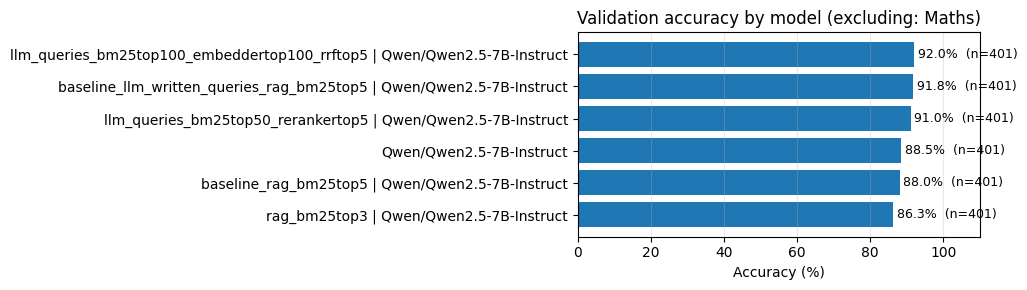

In [ ]:
plot_overall_accuracy(rag_logs_df, exclude_competitions=["Maths"])

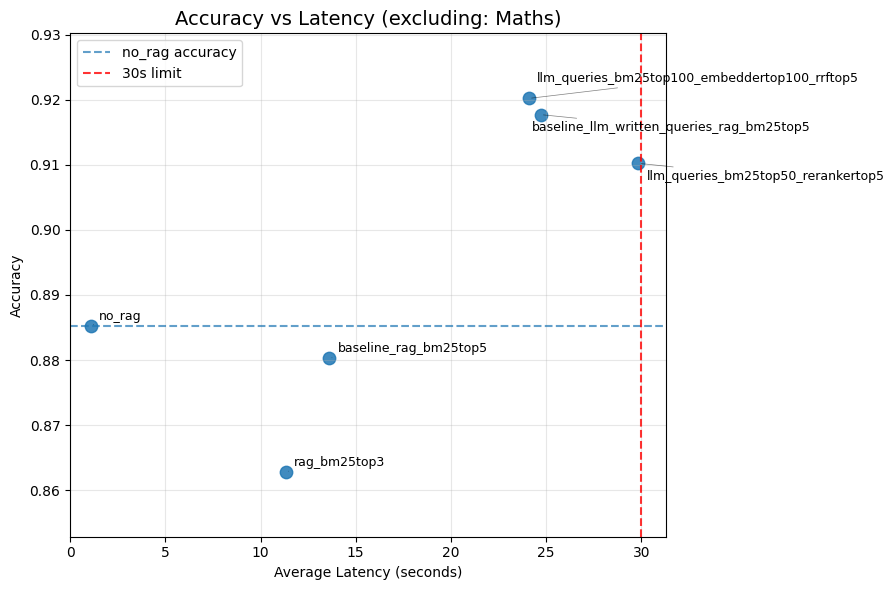

In [ ]:
NO_RAG_NAME = "no_rag"

def plot_accuracy_vs_latency(df, exclude_competitions=None):
    plot_df = df.copy()
    if exclude_competitions is not None:
        plot_df = plot_df[~plot_df["competition"].isin(exclude_competitions)]
    plot_df["experiment_name"] = (
        plot_df["experiment_name"]
        .fillna("")
        .replace("", NO_RAG_NAME)
    )
    grouped = (
        plot_df.groupby("experiment_name")
        .agg(
            accuracy=("is_correct", "mean"),
            total_latency=("latency_seconds", "mean"),
        )
        .sort_values("total_latency")
    )
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.scatter(grouped["total_latency"], grouped["accuracy"], s=80, alpha=0.85)
    for i, (experiment, row) in enumerate(grouped.iterrows()):
        dx, dy = 6, 4
        if row["total_latency"] > 23 and row["accuracy"] > 0.905:
            crowded = grouped[
                (grouped["total_latency"] > 23)
                & (grouped["accuracy"] > 0.905)
            ].sort_values("accuracy")
            rank = crowded.index.get_loc(experiment)
            offsets = [(6, -12), (-6, -12), (6, 12), (6, -24), (6, 36)]
            dx, dy = offsets[min(rank, len(offsets) - 1)]
        ax.annotate(
            experiment,
            xy=(row["total_latency"], row["accuracy"]),
            xytext=(dx, dy),
            textcoords="offset points",
            fontsize=9,
            arrowprops=dict(
                arrowstyle="-",
                lw=0.5,
                alpha=0.5,
            ),
        )
    if NO_RAG_NAME in grouped.index:
        baseline_accuracy = grouped.loc[NO_RAG_NAME, "accuracy"]
        ax.axhline(baseline_accuracy, linestyle="--", alpha=0.7, label=f"{NO_RAG_NAME} accuracy")
    ax.axvline(30, color="red", linestyle="--", alpha=0.8, label="30s limit")
    ax.set_xlabel("Average Latency (seconds)")
    ax.set_ylabel("Accuracy")
    ax.set_title(
        f"Accuracy vs Latency (excluding: {" ".join(exclude_competitions)})",
        fontsize=14,
    )
    ax.grid(True, alpha=0.3)
    ax.set_xlim(left=0)
    ax.set_ylim(grouped["accuracy"].min() - 0.01, grouped["accuracy"].max() + 0.01)
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_accuracy_vs_latency(rag_logs_df, exclude_competitions=["Maths"])

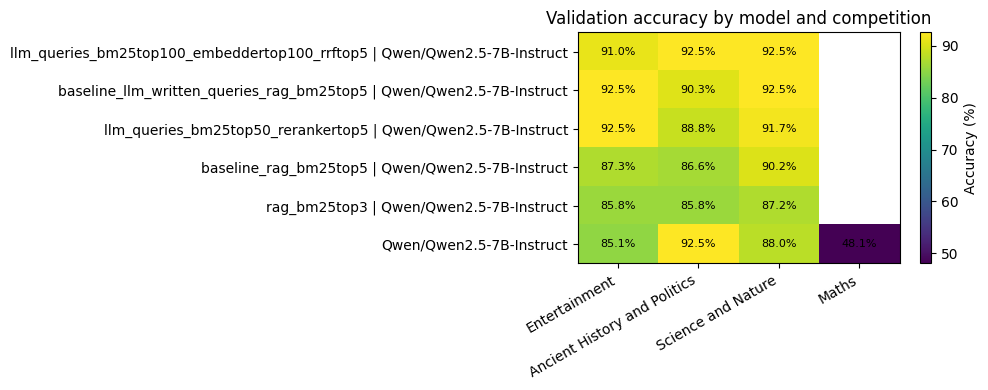

In [ ]:
plot_competition_accuracy_heatmap(rag_logs_df)

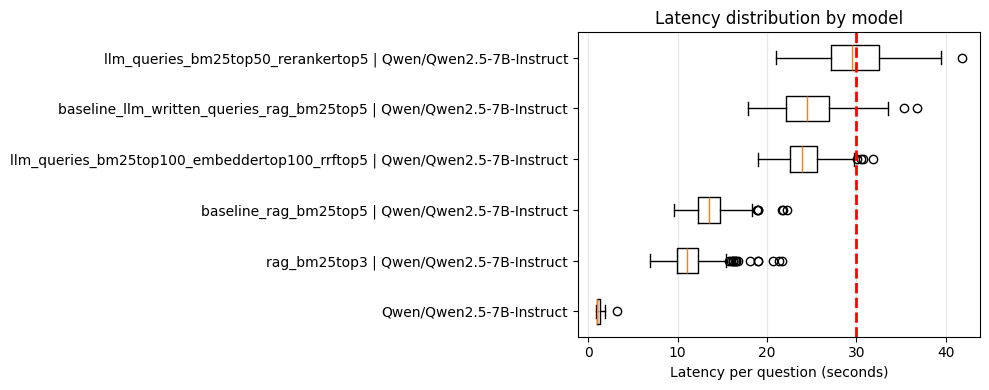

In [ ]:
plot_latency_boxplot(rag_logs_df, show_timeout_line=True)

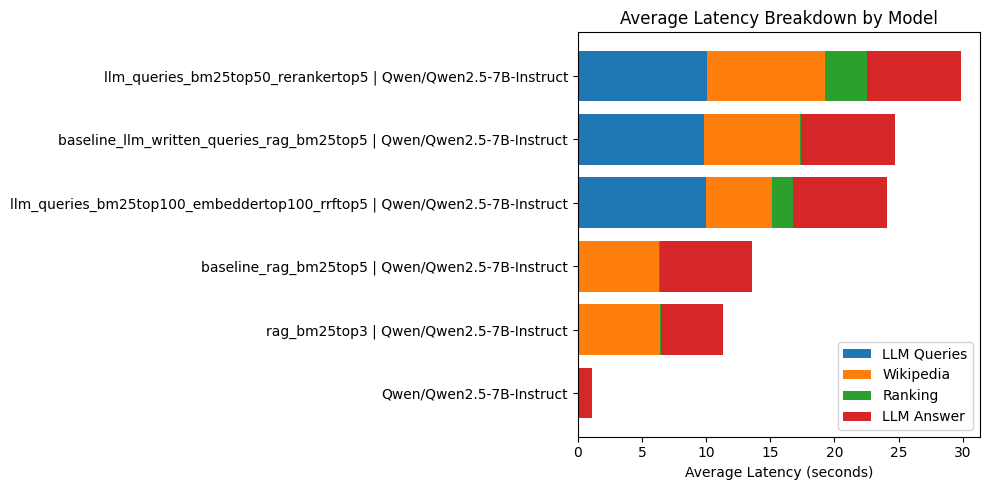

In [ ]:
def plot_latency_breakdown(df):
    grouped = df.groupby("display_model_id")[latency_cols].mean()
    grouped["total_latency"] = grouped[latency_cols].sum(axis=1)
    grouped = grouped.sort_values("total_latency")
    models = grouped.index
    queries = grouped["latency_queries"]
    wikipedia = grouped["latency_wikipedia"]
    ranking = grouped["latency_ranking"]
    llm = grouped["latency_llm"]
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(models, queries, label="LLM Queries")
    ax.barh(models, wikipedia, left=queries, label="Wikipedia")
    ax.barh(models, ranking, left=queries + wikipedia, label="Ranking")
    ax.barh(models, llm, left=queries + wikipedia + ranking, label="LLM Answer")
    ax.set_xlabel("Average Latency (seconds)")
    ax.set_title("Average Latency Breakdown by Model")
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_latency_breakdown(rag_logs_df)

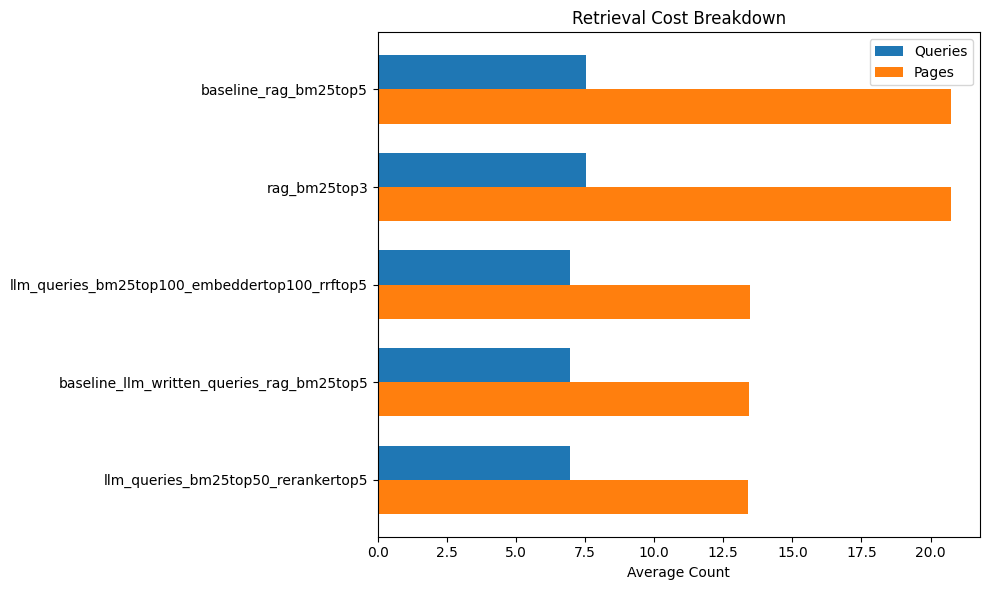

In [ ]:
def plot_retrieval_costs(df):
    df = df.copy()
    if "search_queries" in df.columns:
        df["query_count"] = df["search_queries"].apply(
            lambda x: len(x)
            if isinstance(x, list)
            else 0
        )
    else:
        df["query_count"] = 0
    if "retrieved_titles" in df.columns:
        df["page_count"] = df["retrieved_titles"].apply(
            lambda x: len(set(x))
            if isinstance(x, list)
            else 0
        )
    else:
        df["page_count"] = 0
    grouped = (
        df.groupby("experiment_name")
        .agg(
            avg_query_count=("query_count", "mean"),
            avg_page_count=("page_count", "mean"),
        )
    )
    grouped["total_cost"] = grouped["avg_query_count"] + grouped["avg_page_count"]
    grouped = grouped.sort_values("total_cost", ascending=False)
    fig, ax = plt.subplots(figsize=(10, 6))
    y = range(len(grouped))
    bar_height = 0.35
    ax.barh(
        [i - bar_height / 2 for i in y],
        grouped["avg_query_count"],
        height=bar_height,
        label="Queries",
    )
    ax.barh(
        [i + bar_height / 2 for i in y],
        grouped["avg_page_count"],
        height=bar_height,
        label="Pages",
    )
    ax.set_yticks(list(y))
    ax.set_yticklabels(grouped.index)
    ax.set_xlabel("Average Count")
    ax.set_title("Retrieval Cost Breakdown")
    ax.legend()
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

plot_retrieval_costs(rag_logs_df)

# 6. Maths

## Math model

In [ ]:
# @title
# ============================================================
# Clean RAM and GPU memory - Colab
# ============================================================

import gc
import torch

# ------------------------------------------------------------
# Delete large variables if they exist
# ------------------------------------------------------------

vars_to_delete = [
    "llm_model",
    "model",
    "tokenizer",
    "pipeline",
    "rag_model",
    "embedder",
    "reranker",
    "math_model",
    "math_tokenizer",
]

for var_name in vars_to_delete:
    if var_name in globals():
        del globals()[var_name]
        print(f"Deleted: {var_name}")

# ------------------------------------------------------------
# Python garbage collection
# ------------------------------------------------------------

gc.collect()
print("Python garbage collection completed.")

# ------------------------------------------------------------
# CUDA memory cleanup
# ------------------------------------------------------------

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()
    torch.cuda.reset_peak_memory_stats()
    print("GPU memory cleaned.")
    print(f"Allocated GPU memory: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")
    print(f"Reserved GPU memory : {torch.cuda.memory_reserved() / 1024**3:.2f} GB")
else:
    print("CUDA not available. Running on CPU.")

print("Cleanup completed.")

Deleted: tokenizer
Python garbage collection completed.
GPU memory cleaned.
Allocated GPU memory: 0.01 GB
Reserved GPU memory : 0.13 GB
Cleanup completed.


In [ ]:
# ============================================================
# Clean Qwen Math model on Maths validation set
# ============================================================

import gc
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

# Clean memory
for name in ["llm_model", "model", "tokenizer", "pipeline", "rag_model"]:
    globals().pop(name, None)

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()
    print("GPU memory cleaned.")

# Load clean Math model
MATH_MODEL_ID = "Qwen/Qwen2.5-Math-7B-Instruct"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
)

tokenizer = AutoTokenizer.from_pretrained(MATH_MODEL_ID, trust_remote_code=True)

llm_model = AutoModelForCausalLM.from_pretrained(
    MATH_MODEL_ID,
    quantization_config=bnb_config,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    trust_remote_code=True,
)

llm_model.eval()
print(f"Loaded model: {MATH_MODEL_ID}")

In [ ]:
# @title
# ============================================================
# Clean Qwen Math model on validation questions
# ============================================================

import os
import time


def solve_with_llm(
    question,
    competition,
    llm_model,
    tokenizer,
    prompt_builder,
    parser=parse_simple_answer,
    verbose=False,
    max_new_tokens=128,
):
    messages = prompt_builder(question, competition)

    t0 = time.time()
    raw_output = invoke_llm(
        llm_model=llm_model,
        tokenizer=tokenizer,
        messages=messages,
        max_new_tokens=max_new_tokens,
        do_sample=False,
    )
    elapsed = time.time() - t0

    chosen_id, parse_status = parser(raw_output)

    if verbose:
        print(f"  Prompt        : {messages}")
        print(f"  Raw output    : {raw_output.strip()}")
        print(f"  Chosen option : {chosen_id}")
        print(f"  Parse status  : {parse_status.value}")
        print(f"  Latency       : {elapsed:.2f}s")

    return {
        "chosen_id": chosen_id,
        "raw_output": raw_output,
        "parse_status": parse_status.value,
        "latency_seconds": elapsed,
    }


# ------------------------------------------------------------
# Prompt builder for Qwen Math: answer-only mode
# ------------------------------------------------------------

def build_math_clean_prompt(question, competition):
    options_str = build_numeric_options_str(
        question,
        competition,
        first_option_id=1,
    )

    return [
        {
            "role": "system",
            "content": (
                "You are a mathematical multiple choice solver. "
                "Return ONLY the number of the correct option. "
                "Do not explain. Do not use LaTeX. Do not write words. "
                "Your answer must be exactly one of: 1, 2, 3, 4."
            ),
        },
        {
            "role": "user",
            "content": (
                f"Topic: {competition}\n\n"
                f"Question: {question.text}\n\n"
                f"Options:\n{options_str}\n\n"
                "Correct option number:"
            ),
        },
    ]

# ------------------------------------------------------------
# Maths-only validation set: first 30 questions
# ------------------------------------------------------------

math_validation_df = validation_df[
    validation_df["competition"] == "Maths"
].copy()

math_validation_df = math_validation_df.head(30).copy()

print(f"Maths validation questions selected: {len(math_validation_df)}")


Maths validation questions selected: 30


In [ ]:
# @title
# ------------------------------------------------------------
# Evaluate clean model
# ------------------------------------------------------------

MATH_CLEAN_LOGS_DIR = os.path.join(
    VALIDATION_LOGS_DIR,
    "clean_qwen_math_models",
)

evaluate_chatbot(
    df=math_validation_df,
    chatbot_fn=solve_with_llm,
    model_id=MATH_MODEL_ID,
    output_dir=MATH_CLEAN_LOGS_DIR,
    experiment_name="clean_qwen_math_model",
    chatbot_kwargs={
        "llm_model": llm_model,
        "tokenizer": tokenizer,
        "prompt_builder": build_math_clean_prompt,
        "parser": parse_simple_answer,
        "max_new_tokens": 512,
    },
    verbose=True,
)

Loading log from:
/content/gdrive/MyDrive/NLP_assignment/final_logs/validation/clean_qwen_math_model/clean_qwen_math_model.json
File exists: True
Clean Qwen Math model
---------------------
Questions : 30
Accuracy  : 6.67%
Avg delay : 36.20s


,question_id,correct_option_id,predicted_answer,is_correct,parse_status,latency_seconds,raw_output
0,6695,1,NaN,False,error,23.678617,"To compute the product \((2,3)(3,5)\) in the r..."
1,6696,0,NaN,False,error,23.329084,To determine the degree of the polynomial \( h...
2,6698,0,NaN,False,error,22.558238,To determine the correlation between the numbe...
3,6728,3,NaN,False,error,23.597931,To find the value of \( c \) on the interval \...
4,6738,2,NaN,False,error,46.383026,To determine the shortest time interval associ...
5,6743,2,0.0,False,success,46.449650,"To determine which of the given numbers is a ""..."
6,6745,3,NaN,False,error,46.389944,To determine the probability of getting a 6 in...
7,6752,0,NaN,False,error,30.824587,To determine the number of ways to assign the ...
8,6754,0,NaN,False,error,45.801881,To find the interquartile range (IQR) for a no...
9,6755,0,NaN,False,error,45.151687,To determine the values of \( x \) that are no...


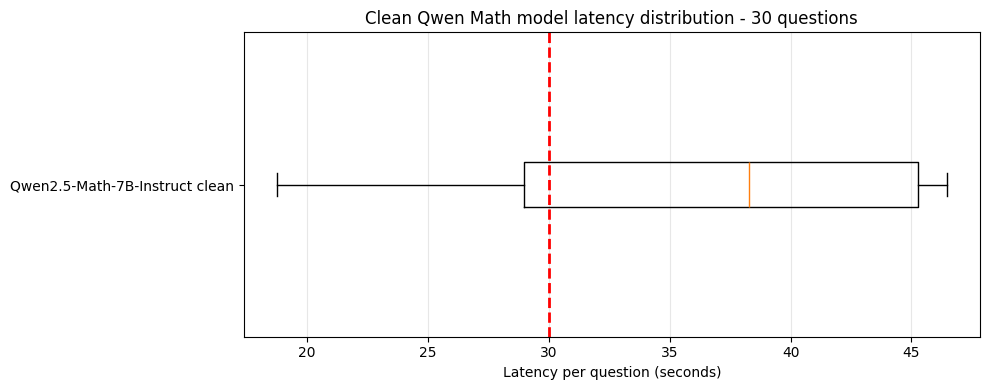

In [ ]:
# @title
# ------------------------------------------------------------
# Load logs
# ------------------------------------------------------------

import os

VALIDATION_LOGS_DIR = "/content/gdrive/MyDrive/NLP_assignment/final_logs/validation"

MATH_CLEAN_LOGS_DIR = os.path.join(
    VALIDATION_LOGS_DIR,
    "clean_qwen_math_model"
)

math_clean_log_path = os.path.join(
    MATH_CLEAN_LOGS_DIR,
    "clean_qwen_math_model.json"
)

print("Loading log from:")
print(math_clean_log_path)
print("File exists:", os.path.exists(math_clean_log_path))

math_clean_logs_df = load_existing_logs(math_clean_log_path)

# IMPORTANT: required by plot_latency_boxplot
math_clean_logs_df["display_model_id"] = "Qwen2.5-Math-7B-Instruct clean"


# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

print("Clean Qwen Math model")
print("---------------------")
print(f"Questions : {len(math_clean_logs_df)}")
print(f"Accuracy  : {math_clean_logs_df['is_correct'].mean():.2%}")
print(f"Avg delay : {math_clean_logs_df['latency_seconds'].mean():.2f}s")

display(
    math_clean_logs_df[
        [
            "question_id",
            "correct_option_id",
            "predicted_answer",
            "is_correct",
            "parse_status",
            "latency_seconds",
            "raw_output",
        ]
    ].tail(30)
)


# ------------------------------------------------------------
# Latency plot
# ------------------------------------------------------------

plot_latency_boxplot(
    math_clean_logs_df,
    show_timeout_line=True,
    column="latency_seconds",
    title="Clean Qwen Math model latency distribution - 30 questions",
)

## Classifier

We developed a binary classifier to distinguish between Theory and Practice mathematics questions. The classifier is used as a routing component: theoretical questions are sent to a RAG-based pipeline, while practical questions are handled by a computation-oriented solver. The dataset contains 368 labelled questions, with 309 Practice and 59 Theory examples. The classifier uses only the question text and the answer options. Several classical machine learning models were evaluated, based on TF-IDF representations combined with linear or probabilistic classifiers. Model selection was performed on the training split using stratified cross-validation and macro F1-score, which is appropriate for imbalanced binary classification. The decision threshold was also tuned using cross-validated predictions on the training data, while the test set was kept untouched for final evaluation. In the final run, the best model was a TF-IDF word-level n-gram representation with unigrams and bigrams, followed by a Complement Naive Bayes classifier. The optimal configuration used alpha = 0.1 and a decision threshold of approximately 0.5. On the held-out test set, the classifier achieved 93.2% accuracy, 89.2% balanced accuracy, and 0.880 macro F1-score. It obtained strong performance on Practice questions, with an F1-score of 0.959, and good results on Theory questions, with an F1-score of 0.800. After the final evaluation, the selected model was refitted on the full dataset.

In [ ]:
# ============================================================
# 6. Maths - Theory / Practice binary classifier
# ============================================================

import importlib.util
from pathlib import Path

if IS_COLAB:
    MATH_CLASSIFIER_DIR = Path("/content/gdrive/MyDrive/NLP_assignment/classifier/v2")
else:
    MATH_CLASSIFIER_DIR = Path("/kaggle/input/datasets/davidepaltrinieri/final-math/math_all_retichettato/classifier")


if not MATH_CLASSIFIER_DIR.exists():
    raise FileNotFoundError(
        f"Classifier folder not found: {MATH_CLASSIFIER_DIR}"
    )

inference_py = MATH_CLASSIFIER_DIR / "inference.py"

if not inference_py.exists():
    raise FileNotFoundError(
        f"inference.py not found inside classifier folder: {inference_py}"
    )

spec = importlib.util.spec_from_file_location(
    "theory_practice_classifier_inference",
    inference_py,
)

classifier_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(classifier_module)

math_type_classifier = classifier_module.TheoryPracticeClassifier(
    artifact_dir=str(MATH_CLASSIFIER_DIR)
)

print("Math Theory/Practice classifier loaded.")
print("Classifier folder:", MATH_CLASSIFIER_DIR)
print("Threshold:", math_type_classifier.threshold)
print("Best model:", math_type_classifier.metadata.get("best_model"))
print("Label mapping:", math_type_classifier.metadata.get("label_mapping"))

Math Theory/Practice classifier loaded.
Classifier folder: /content/gdrive/MyDrive/NLP_assignment/classifier/v2
Threshold: 0.48499999999999993
Best model: tfidf_wordchar_logreg
Label mapping: {'0': 'Practice', '1': 'Theory'}


### Clustering

The unsupervised KMeans clustering was applied only to the TF-IDF representation of the Maths validation questions, without using Theory/Practice labels. The resulting clusters are not perfectly equivalent to the two classes, but they show a meaningful separation. Cluster 1 is entirely composed of questions predicted as Theory, while Cluster 0 is mainly composed of Practice questions but also contains some Theory cases. This suggests that the Practice/Theory distinction is partially reflected in the textual structure, although it is not fully separable through unsupervised lexical clustering alone.




Number of Maths validation questions: 131


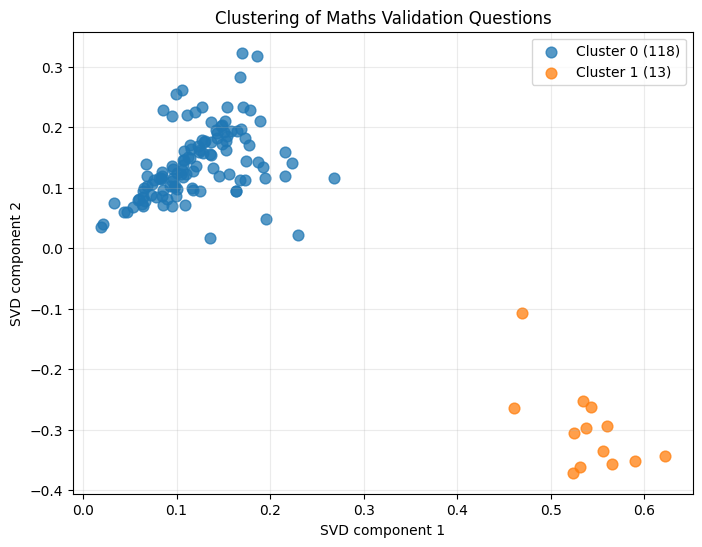

,question,cluster
0,"Compute the product in the given ring. (2,3)(3...",0
1,Suppose that $f(x)$ is a polynomial that has d...,0
2,"For their first exam, students in an AP Statis...",0
3,For what value of c on 0 < x < 1 is the tangen...,0
4,The waiting times for a new roller coaster rid...,0
...,...,...
42,Statement 1 | If f is a homomorphism from G to...,1
45,Statement 1 | S_n is non-Abelian for all n >= ...,1
77,Statement 1 | A permutation that is a product ...,1
73,Statement 1 | If a and b are elements of finit...,1


In [ ]:
# ============================================================
# Clustering of Maths validation questions
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD

# ------------------------------------------------------------
# 1. Extract Maths validation questions
# ------------------------------------------------------------

math_rows = validation_df[validation_df["competition"] == "Maths"].copy()

cluster_data = []

for _, row in math_rows.iterrows():
    q = row["question"]

    question_text = q.text
    options_text = "\n".join([f"{opt.id}. {opt.text}" for opt in q.options])

    full_text = f"{question_text}\n{options_text}"

    cluster_data.append({
        "question": question_text,
        "options": options_text,
        "text_for_model": full_text,
    })

math_cluster_df = pd.DataFrame(cluster_data)

print(f"Number of Maths validation questions: {len(math_cluster_df)}")

# ------------------------------------------------------------
# 2. Vectorize questions with TF-IDF
# ------------------------------------------------------------

math_cluster_vectorizer = TfidfVectorizer(
    lowercase=True,
    strip_accents="unicode",
    ngram_range=(1, 2),
    min_df=1,
    max_df=0.95,
)

X_math_cluster = math_cluster_vectorizer.fit_transform(
    math_cluster_df["text_for_model"]
)

# ------------------------------------------------------------
# 3. Cluster questions into 2 groups
# ------------------------------------------------------------

math_kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=20,
)

math_cluster_df["cluster"] = math_kmeans.fit_predict(X_math_cluster)

# ------------------------------------------------------------
# 4. Project TF-IDF vectors to 2D
# ------------------------------------------------------------

math_svd = TruncatedSVD(
    n_components=2,
    random_state=42,
)

X_math_2d = math_svd.fit_transform(X_math_cluster)

math_cluster_df["x"] = X_math_2d[:, 0]
math_cluster_df["y"] = X_math_2d[:, 1]

# ------------------------------------------------------------
# 5. Plot clusters
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

for cluster_id in sorted(math_cluster_df["cluster"].unique()):
    subset = math_cluster_df[math_cluster_df["cluster"] == cluster_id]

    plt.scatter(
        subset["x"],
        subset["y"],
        label=f"Cluster {cluster_id} ({len(subset)})",
        alpha=0.75,
        s=60,
    )

plt.title("Clustering of Maths Validation Questions")
plt.xlabel("SVD component 1")
plt.ylabel("SVD component 2")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

display(math_cluster_df[["question", "cluster"]].sort_values("cluster"))

Predictions generated: 131
Questions in dataframe: 131

Distribution of classifier predictions inside each KMeans cluster:


Classifier prediction,Practice,Theory
KMeans cluster,,
0,94,24
1,0,13


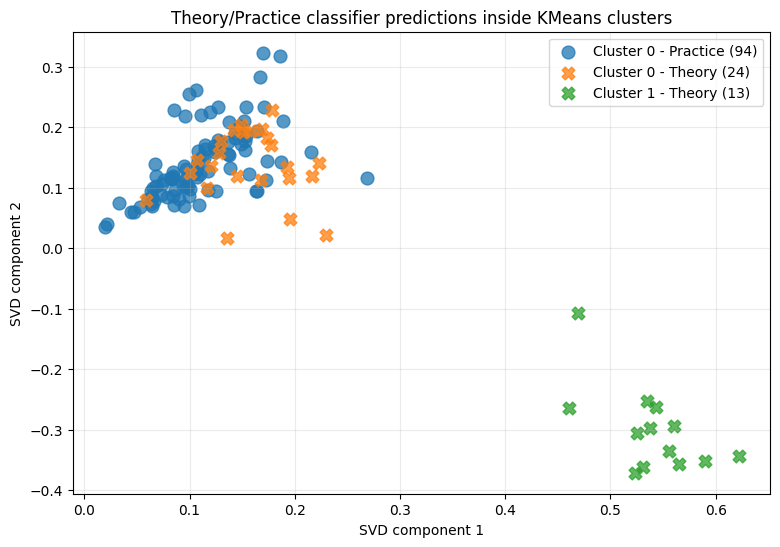


Examples sorted by cluster and predicted type:


,question,cluster,predicted_type,prob_theory
0,"Compute the product in the given ring. (2,3)(3...",0,Practice,0.241455
1,Suppose that $f(x)$ is a polynomial that has d...,0,Practice,0.255319
2,"For their first exam, students in an AP Statis...",0,Practice,0.380559
3,For what value of c on 0 < x < 1 is the tangen...,0,Practice,0.240877
4,The waiting times for a new roller coaster rid...,0,Practice,0.311344
...,...,...,...,...
126,An investment of $4000 grows at the rate of 32...,0,Practice,0.248811
127,Patricia’s annual starting salary at her new j...,0,Practice,0.280239
128,What is the probability that a randomly select...,0,Practice,0.195372
129,Find $b$ if $\log_{b}343=-\frac{3}{2}$.,0,Practice,0.159555


In [ ]:
# ============================================================
# Classifier inference inside the saved Maths clusters
# Compatible with custom math_type_classifier
# ============================================================

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Helper to parse options from math_cluster_df
# ------------------------------------------------------------

def parse_options_text(options_text):
    """
    Convert options_text like:
    0. option text
    1. option text
    ...
    into:
    [{"id": 0, "text": "option text"}, ...]
    """
    options = []

    for line in str(options_text).split("\n"):
        line = line.strip()
        if not line:
            continue

        match = re.match(r"^([A-Da-d]|\d+)\.\s*(.*)$", line)

        if match:
            opt_id_raw = match.group(1)
            opt_text = match.group(2).strip()

            try:
                opt_id = int(opt_id_raw)
            except Exception:
                opt_id = opt_id_raw.upper()

            options.append({
                "id": opt_id,
                "text": opt_text,
            })
        else:
            options.append({
                "id": len(options),
                "text": line,
            })

    return options


# ------------------------------------------------------------
# 2. Run classifier inference question by question
# ------------------------------------------------------------

predicted_types = []
prob_theory_values = []
threshold_values = []

for _, row in math_cluster_df.iterrows():

    question_text = row["question"]

    # If options_list exists, use it. Otherwise parse from options text.
    if "options_list" in math_cluster_df.columns:
        options = row["options_list"]
    else:
        options = parse_options_text(row["options"])

    result = math_type_classifier.predict(
        question=question_text,
        options=options,
    )

    predicted_types.append(result["type"])
    prob_theory_values.append(result.get("prob_theory", np.nan))
    threshold_values.append(result.get("threshold", np.nan))

math_cluster_df["predicted_type"] = predicted_types
math_cluster_df["prob_theory"] = prob_theory_values
math_cluster_df["classifier_threshold"] = threshold_values

print(f"Predictions generated: {len(predicted_types)}")
print(f"Questions in dataframe: {len(math_cluster_df)}")

# ------------------------------------------------------------
# 3. Show distribution of predictions inside each cluster
# ------------------------------------------------------------

print("\nDistribution of classifier predictions inside each KMeans cluster:")

cluster_prediction_table = pd.crosstab(
    math_cluster_df["cluster"],
    math_cluster_df["predicted_type"],
    rownames=["KMeans cluster"],
    colnames=["Classifier prediction"]
)

display(cluster_prediction_table)

# ------------------------------------------------------------
# 4. Plot clusters with classifier predictions
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

markers = {
    "Practice": "o",
    "Theory": "X",
}

for cluster_id in sorted(math_cluster_df["cluster"].unique()):
    for pred_type in ["Practice", "Theory"]:
        subset = math_cluster_df[
            (math_cluster_df["cluster"] == cluster_id) &
            (math_cluster_df["predicted_type"] == pred_type)
        ]

        if len(subset) == 0:
            continue

        plt.scatter(
            subset["x"],
            subset["y"],
            marker=markers[pred_type],
            s=85,
            alpha=0.75,
            label=f"Cluster {cluster_id} - {pred_type} ({len(subset)})"
        )

plt.title("Theory/Practice classifier predictions inside KMeans clusters")
plt.xlabel("SVD component 1")
plt.ylabel("SVD component 2")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

# ------------------------------------------------------------
# 5. Show examples
# ------------------------------------------------------------

print("\nExamples sorted by cluster and predicted type:")

display(
    math_cluster_df[
        ["question", "cluster", "predicted_type", "prob_theory"]
    ]
)

## Practice

1. **Branch selection** - The main router sends the question to this branch when the classifier predicts it as Practice.
2. **Option preprocessing** - The answer options are normalized and parsed to extract comparable elements such as numbers, fractions, percentages, tuples, and ranges.
3. **Code-generation prompt** - The LLM receives the question, the options, and a strict system prompt asking it to generate only executable Python code.
4. **Code execution** - Execute the generated code. When possible, the code also builds candidate_values = {0: value_A, 1: value_B, 2: value_C, 3: value_D} and a validation dictionary marking which option matches final_value. The code is executed in Python using controlled tools (such as math, numpy, sympy).
5. **Safe execution** - The validated code runs in a limited namespace with predefined safe functions and a fixed execution timeout, preventing unsafe or excessively long computations.
6. **Answer extraction** - The parser first tries to match final_value against the options (using numeric tolerance, sequence comparison, symbolic/numeric conversion, or normalized text matching). If final_value is not enough, the parser checks candidate_values, then the boolean validation dictionary, accepting the result only if exactly one option is identified.
7. **LLM fallback** - a LLM call receives the question, generated code, execution result, and parser output, and must return only A, B, C, or D.

In [ ]:
# ============================================================
# 6.0 Maths Practice - Imports and basic definitions
# ============================================================

import ast
import enum
import itertools
import json
import math
import re
import signal
import statistics
import time
import traceback
from decimal import Decimal
from fractions import Fraction

import numpy as np
import sympy as sp

try:
    from scipy import stats
    from scipy.stats import norm, binom, t, poisson, chi2
    from scipy.optimize import brentq, minimize_scalar
except Exception as exc:
    stats = norm = binom = t = poisson = chi2 = brentq = minimize_scalar = None
    print("Warning: scipy is not fully available:", repr(exc))


if "ParseStatus" not in globals():
    class ParseStatus(enum.Enum):
        SUCCESS = "success"
        WARNING = "warning"
        ERROR = "error"

In [ ]:


# ============================================================
# Option parsing
# ============================================================

def clean_text(text):
    text = "" if text is None else str(text).strip()

    replacements = {
        "−": "-",
        "–": "-",
        "—": "-",
        "×": "*",
        "·": "*",
        "÷": "/",
        "^": "**",
        "π": "pi",
        "$": "",
    }

    for old, new in replacements.items():
        text = text.replace(old, new)

    text = re.sub(r"\\left|\\right", "", text)
    text = re.sub(r"\\cdot|\\times", "*", text)
    text = re.sub(r"\\pi", "pi", text)
    text = re.sub(r"\\infty", "oo", text)

    frac_pattern = re.compile(r"\\frac\s*\{([^{}]+)\}\s*\{([^{}]+)\}")
    while frac_pattern.search(text):
        text = frac_pattern.sub(r"((\1)/(\2))", text)

    sqrt_pattern = re.compile(r"\\sqrt\s*\{([^{}]+)\}")
    while sqrt_pattern.search(text):
        text = sqrt_pattern.sub(r"sqrt(\1)", text)

    text = text.replace("\\", "")
    text = text.replace("{", "(").replace("}", ")")
    text = re.sub(r"\s+", " ", text).strip()

    return text


def text_key(text):
    return re.sub(r"\s+", " ", clean_text(text).lower()).strip()


def to_number(value):
    if value is None:
        return None

    if isinstance(value, (int, float, np.integer, np.floating)):
        return float(value)

    if isinstance(value, Fraction):
        return float(value)

    if isinstance(value, Decimal):
        return float(value)

    text = clean_text(value).replace(",", "").strip()

    if text.endswith("%"):
        base = to_number(text[:-1])
        return None if base is None else base / 100.0

    try:
        return float(Fraction(text))
    except Exception:
        pass

    try:
        return float(sp.N(sp.sympify(
            text,
            locals={
                "sqrt": sp.sqrt,
                "pi": sp.pi,
                "oo": sp.oo,
                "e": sp.E,
                "E": sp.E,
            },
        )))
    except Exception:
        return None


def numbers_close(a, b, rel_tol=1e-4, abs_tol=1e-4):
    a = to_number(a)
    b = to_number(b)

    if a is None or b is None:
        return False

    return abs(a - b) <= max(abs_tol, rel_tol * max(abs(a), abs(b), 1.0))


def parse_sequence(value):
    if isinstance(value, np.ndarray):
        value = value.tolist()

    if isinstance(value, (list, tuple)):
        parsed = [to_number(v) for v in value]
        if all(v is not None for v in parsed):
            return tuple(parsed)

    if isinstance(value, str):
        candidate = clean_text(value)

        if candidate.startswith("(") and candidate.endswith(")") and "," in candidate:
            parts = [part.strip() for part in candidate[1:-1].split(",")]
            parsed = [to_number(part) for part in parts]
            if all(v is not None for v in parsed):
                return tuple(parsed)

    return None


def values_equivalent(a, b):
    seq_a = parse_sequence(a)
    seq_b = parse_sequence(b)

    if seq_a is not None and seq_b is not None:
        return len(seq_a) == len(seq_b) and all(numbers_close(x, y) for x, y in zip(seq_a, seq_b))

    if to_number(a) is not None and to_number(b) is not None:
        return numbers_close(a, b)

    return text_key(a) == text_key(b)


def extract_numbers_from_text(text):
    text = clean_text(text)
    values = []

    for match in re.finditer(r"[-+]?\d[\d,]*(?:\.\d+)?\s*%", text):
        value = to_number(match.group(0))
        if value is not None:
            values.append(value)

    for match in re.finditer(r"[-+]?\d[\d,]*(?:\.\d+)?(?:[eE][-+]?\d+)?", text):
        value = to_number(match.group(0))
        if value is not None:
            values.append(value)

    unique = []
    for value in values:
        if not any(numbers_close(value, old, rel_tol=1e-12, abs_tol=1e-12) for old in unique):
            unique.append(value)

    return unique


def extract_sequences_from_text(text):
    text = clean_text(text)
    sequences = []

    for match in re.finditer(r"\(([^()]*)\)", text):
        content = match.group(1)

        if "," not in content:
            continue

        parts = [part.strip() for part in content.split(",")]
        parsed = [to_number(part) for part in parts]

        if all(v is not None for v in parsed):
            sequences.append(tuple(parsed))

    range_patterns = [
        r"([-+]?\d[\d,]*(?:\.\d+)?)\s+to\s+([-+]?\d[\d,]*(?:\.\d+)?)",
        r"([-+]?\d[\d,]*(?:\.\d+)?)\s+-\s+([-+]?\d[\d,]*(?:\.\d+)?)",
    ]

    for pattern in range_patterns:
        for match in re.finditer(pattern, text, flags=re.IGNORECASE):
            left = to_number(match.group(1))
            right = to_number(match.group(2))
            if left is not None and right is not None:
                sequences.append((left, right))

    return sequences


def build_options_payload(question):
    payload = []

    for option in sorted(question.options, key=lambda opt: int(opt.id)):
        option_text = str(option.text)

        payload.append({
            "id": int(option.id),
            "letter": chr(ord("A") + int(option.id)),
            "text": option_text,
            "key": text_key(option_text),
            "numbers": extract_numbers_from_text(option_text),
            "sequences": extract_sequences_from_text(option_text),
        })

    return payload


def format_options_for_prompt(question):
    return "\n".join(
        f"{chr(ord('A') + int(option.id))}) {option.text}"
        for option in sorted(question.options, key=lambda opt: int(opt.id))
    )


def coerce_option_id(value):
    if value is None:
        return None

    if isinstance(value, str):
        value = value.strip().upper()

        if value in {"A", "B", "C", "D"}:
            return ord(value) - ord("A")

        if re.fullmatch(r"[0-3]", value):
            return int(value)

        if re.fullmatch(r"[1-4]", value):
            return int(value) - 1

    if isinstance(value, (int, np.integer)):
        value = int(value)
        if 0 <= value <= 3:
            return value

    return None


In [ ]:
# ============================================================
# JSON-safe serialization
# ============================================================

def json_safe(obj):
    if obj is None:
        return None

    if isinstance(obj, (str, int, float, bool)):
        return obj

    if isinstance(obj, (np.bool_,)):
        return bool(obj)

    if isinstance(obj, (np.integer,)):
        return int(obj)

    if isinstance(obj, (np.floating,)):
        return float(obj)

    if isinstance(obj, (Fraction, Decimal)):
        return float(obj)

    if isinstance(obj, ParseStatus):
        return obj.value

    if isinstance(obj, tuple):
        return [json_safe(v) for v in obj]

    if isinstance(obj, list):
        return [json_safe(v) for v in obj]

    if isinstance(obj, dict):
        return {str(json_safe(k)): json_safe(v) for k, v in obj.items()}

    if isinstance(obj, sp.Basic):
        return str(obj)

    return str(obj)

In [ ]:
# ============================================================
# General-purpose maths tools exposed to generated code
# ============================================================

def lcm_list(values):
    values = [int(v) for v in values]
    return math.lcm(*values) if values else 1


def prime_factorization(n):
    return sp.factorint(int(n))


def is_prime(n):
    return bool(sp.isprime(int(n)))


def normal_cdf(x, mean=0.0, sd=1.0):
    return statistics.NormalDist(float(mean), float(sd)).cdf(float(x))


def normal_ppf(p, mean=0.0, sd=1.0):
    return statistics.NormalDist(float(mean), float(sd)).inv_cdf(float(p))


def normal_between(lower, upper, mean=0.0, sd=1.0):
    dist = statistics.NormalDist(float(mean), float(sd))
    return dist.cdf(float(upper)) - dist.cdf(float(lower))


def binomial_pmf(k, n, p):
    k, n, p = int(k), int(n), float(p)
    return math.comb(n, k) * (p ** k) * ((1.0 - p) ** (n - k))


def binomial_cdf(k, n, p):
    return sum(binomial_pmf(i, n, p) for i in range(int(k) + 1))


def binomial_tail(k, n, p):
    return sum(binomial_pmf(i, n, p) for i in range(int(k), int(n) + 1))


def componentwise_mod_product(a, b, mods):
    return tuple((int(x) * int(y)) % int(m) for x, y, m in zip(a, b, mods))


def finite_field_roots(coefficients, p):
    p = int(p)
    coefficients = [int(c) for c in coefficients]
    roots = []

    for x in range(p):
        value = 0
        for c in coefficients:
            value = (value * x + c) % p
        if value == 0:
            roots.append(x)

    return roots


def max_order_symmetric_group(n):
    n = int(n)
    best_order = 1
    best_partition = ()

    def search(remaining, max_part, parts):
        nonlocal best_order, best_partition

        if remaining == 0:
            order = lcm_list(parts)
            if order > best_order:
                best_order = order
                best_partition = tuple(parts)
            return

        for part in range(min(remaining, max_part), 0, -1):
            search(remaining - part, part, parts + [part])

    search(n, n, [])
    return best_order


In [ ]:
# ============================================================
# Restricted execution environment
# ============================================================

SAFE_BUILTINS = {
    "abs": abs,
    "round": round,
    "min": min,
    "max": max,
    "sum": sum,
    "len": len,
    "range": range,
    "enumerate": enumerate,
    "zip": zip,
    "sorted": sorted,
    "all": all,
    "any": any,
    "pow": pow,
    "next": next,
    "iter": iter,
    "float": float,
    "int": int,
    "str": str,
    "bool": bool,
    "list": list,
    "dict": dict,
    "tuple": tuple,
    "set": set,
    "asin": math.asin,
    "acos": math.acos,
    "atan": math.atan,
}

FORBIDDEN_NAMES = {
    "open",
    "exec",
    "eval",
    "compile",
    "__import__",
    "input",
    "globals",
    "locals",
    "vars",
    "dir",
    "getattr",
    "setattr",
    "delattr",
    "os",
    "sys",
    "subprocess",
    "socket",
    "pathlib",
    "shutil",
    "pickle",
}

FORBIDDEN_NODES = (
    ast.Import,
    ast.ImportFrom,
    ast.With,
    ast.AsyncWith,
    ast.ClassDef,
    ast.AsyncFunctionDef,
    ast.Global,
    ast.Nonlocal,
)


def extract_python_code(raw_output):
    raw_output = str(raw_output).strip()

    blocks = re.findall(
        r"```(?:python)?\s*(.*?)```",
        raw_output,
        flags=re.DOTALL | re.IGNORECASE,
    )

    return blocks[-1].strip() if blocks else raw_output


def validate_generated_code(code):
    tree = ast.parse(code)

    for node in ast.walk(tree):
        if isinstance(node, FORBIDDEN_NODES):
            raise ValueError(f"Forbidden syntax: {type(node).__name__}")

        if isinstance(node, ast.Name) and node.id in FORBIDDEN_NAMES:
            raise ValueError(f"Forbidden name: {node.id}")

        if isinstance(node, ast.Attribute) and node.attr.startswith("__"):
            raise ValueError(f"Forbidden dunder attribute: {node.attr}")

    return True


class CodeTimeoutError(Exception):
    pass


def timeout_handler(signum, frame):
    raise CodeTimeoutError("Generated code timed out.")


def build_execution_namespace(question, options_payload):
    x, y, z, a, b, c, n, t_sym = sp.symbols("x y z a b c n t")

    namespace = {
        "__builtins__": SAFE_BUILTINS,

        "question": question.text,
        "options": [
            {
                "id": option["id"],
                "letter": option["letter"],
                "text": option["text"],
            }
            for option in options_payload
        ],

        "final_value": None,
        "candidate_values": {},
        "validation": {},
        "chosen_id": None,
        "confidence": 0.0,

        "x": x,
        "y": y,
        "z": z,
        "a": a,
        "b": b,
        "c": c,
        "n": n,
        "t_sym": t_sym,

        "math": math,
        "np": np,
        "sp": sp,
        "stats": stats,
        "norm": norm,
        "binom": binom,
        "t": t,
        "poisson": poisson,
        "chi2": chi2,
        "brentq": brentq,
        "minimize_scalar": minimize_scalar,
        "statistics": statistics,
        "itertools": itertools,
        "Fraction": Fraction,
        "Decimal": Decimal,

        "sqrt": math.sqrt,
        "log": math.log,
        "log10": math.log10,
        "exp": math.exp,
        "sin": math.sin,
        "cos": math.cos,
        "tan": math.tan,
        "pi": math.pi,
        "e": math.e,
        "floor": math.floor,
        "ceil": math.ceil,
        "factorial": math.factorial,
        "gcd": math.gcd,
        "lcm": math.lcm,
        "comb": math.comb,
        "perm": math.perm,

        "lcm_list": lcm_list,
        "prime_factorization": prime_factorization,
        "is_prime": is_prime,
        "normal_cdf": normal_cdf,
        "normal_ppf": normal_ppf,
        "normal_between": normal_between,
        "binomial_pmf": binomial_pmf,
        "binomial_cdf": binomial_cdf,
        "binomial_tail": binomial_tail,
        "componentwise_mod_product": componentwise_mod_product,
        "max_order_symmetric_group": max_order_symmetric_group,
        "finite_field_roots": finite_field_roots,
    }

    return namespace


def run_generated_code(code, question, options_payload, timeout_seconds=6):
    validate_generated_code(code)

    namespace = build_execution_namespace(question, options_payload)

    old_handler = signal.signal(signal.SIGALRM, timeout_handler)
    signal.alarm(timeout_seconds)

    try:
        exec(code, namespace, namespace)
    finally:
        signal.alarm(0)
        signal.signal(signal.SIGALRM, old_handler)

    return json_safe({
        "final_value": namespace.get("final_value"),
        "candidate_values": namespace.get("candidate_values"),
        "validation": namespace.get("validation"),
        "chosen_id": namespace.get("chosen_id"),
        "confidence": namespace.get("confidence"),
    })


def decode_execution_result(exec_result, options_payload):
    final_id, final_conf, final_scores, final_reason = choose_from_final_value(
        exec_result.get("final_value"),
        options_payload,
    )

    if final_id is not None:
        return json_safe({
            "chosen_id": final_id,
            "confidence": final_conf,
            "parse_status": ParseStatus.SUCCESS,
            "decision_source": final_reason,
            "option_match_scores": final_scores,
        })

    candidate_id, candidate_conf, candidate_reason = choose_from_candidate_values(
        exec_result.get("final_value"),
        exec_result.get("candidate_values"),
    )

    if candidate_id is not None:
        return json_safe({
            "chosen_id": candidate_id,
            "confidence": candidate_conf,
            "parse_status": ParseStatus.SUCCESS,
            "decision_source": candidate_reason,
            "option_match_scores": final_scores,
        })

    validation_id, validation_conf, validation_reason = choose_from_validation(
        exec_result.get("validation"),
    )

    if validation_id is not None:
        return json_safe({
            "chosen_id": validation_id,
            "confidence": validation_conf,
            "parse_status": ParseStatus.SUCCESS,
            "decision_source": validation_reason,
            "option_match_scores": final_scores,
        })

    direct_id = coerce_option_id(exec_result.get("chosen_id"))
    direct_conf = to_number(exec_result.get("confidence")) or 0.0

    if direct_id is not None and direct_conf >= 0.90:
        return json_safe({
            "chosen_id": direct_id,
            "confidence": min(1.0, direct_conf),
            "parse_status": ParseStatus.WARNING,
            "decision_source": "direct_chosen_id",
            "option_match_scores": final_scores,
        })

    return json_safe({
        "chosen_id": None,
        "confidence": 0.0,
        "parse_status": ParseStatus.ERROR,
        "decision_source": "unresolved",
        "option_match_scores": final_scores,
    })


In [ ]:
# ============================================================
# Practice code-generation prompt
# ============================================================

PRACTICE_CODEGEN_SYSTEM_PROMPT = """
Write minimal Python code to solve a multiple-choice Maths question.

Return ONLY Python code in one code block.

Available tools:
math, np, sp, stats,
norm, binom, t, poisson, chi2,
brentq, minimize_scalar,
statistics, itertools,
Fraction, Decimal,

sqrt, log, log10, exp,
sin, cos, tan, asin, acos, atan,
pi, e, floor, ceil,
factorial, gcd, lcm, comb, perm,

lcm_list, prime_factorization, is_prime,
normal_cdf, normal_ppf, normal_between,
binomial_pmf, binomial_cdf, binomial_tail,
componentwise_mod_product,
max_order_symmetric_group,
finite_field_roots.

Required strategy:
1. Solve the problem directly and assign the result to final_value.
2. Independently construct candidate_values for the options whenever possible,
   using option ids as keys: {0: value_A, 1: value_B, 2: value_C, 3: value_D}.
3. Validate the options against final_value with validation = {0: bool, 1: bool, 2: bool, 3: bool}.
4. Use chosen_id only for conceptual questions where final_value cannot represent the answer.

Rules:
- No imports.
- No print.
- No randomness.
- No file access or system calls.
- Do not use open, input, eval, exec, compile, or __import__.
- Do not create artificial scores.
- Do not use distances as confidence.
- confidence must be in [0, 1].
- If multiple options seem valid, set confidence below 0.90.
- If uncertain, compute the best result but set confidence below 0.90.
- For derivatives use sp.diff.
- For integrals use sp.integrate.
- For limits use sp.limit.
- For equations use sp.solve or sp.solveset.
- For modular arithmetic use %.
- For combinatorics use comb, perm, factorial, itertools, or direct counting.
- For probability compute the requested event directly.
- For binomial distributions use binomial_pmf, binomial_cdf, binomial_tail, or binom.
- For normal distributions use normal_cdf, normal_ppf, normal_between, or norm.
- For finite fields use finite_field_roots when useful.
- For S_n element order problems use max_order_symmetric_group(n).

Required variables:
final_value = ...
candidate_values = {...}
validation = {...}
chosen_id = None
confidence = ...
""".strip()


def build_practice_codegen_prompt(question, competition):
    return [
        {
            "role": "system",
            "content": PRACTICE_CODEGEN_SYSTEM_PROMPT,
        },
        {
            "role": "user",
            "content": (
                f"Topic: {competition}\n\n"
                f"Question:\n{question.text}\n\n"
                f"Options:\n{format_options_for_prompt(question)}\n\n"
                "Write the Python code now."
            ),
        },
    ]

In [ ]:
# ============================================================
# Answer extraction
# ============================================================

def choose_from_final_value(final_value, options_payload):
    scores = {option["id"]: 0.0 for option in options_payload}

    if final_value is None:
        return None, 0.0, scores, "missing_final_value"

    final_sequence = parse_sequence(final_value)

    if final_sequence is not None:
        for option in options_payload:
            candidates = list(option["sequences"])

            if not candidates and len(option["numbers"]) == len(final_sequence):
                candidates.append(tuple(option["numbers"]))

            for candidate in candidates:
                if values_equivalent(final_sequence, candidate):
                    scores[option["id"]] = 1.0

    elif to_number(final_value) is not None:
        for option in options_payload:
            for number in option["numbers"]:
                if numbers_close(final_value, number):
                    scores[option["id"]] = 1.0

    else:
        final_key = text_key(final_value)
        for option in options_payload:
            if final_key and final_key == option["key"]:
                scores[option["id"]] = 1.0

    best_id = max(scores, key=scores.get)
    best_score = scores[best_id]
    second_score = sorted(scores.values(), reverse=True)[1]

    if best_score > 0.0 and best_score > second_score:
        return best_id, best_score, scores, "final_value_match"

    return None, best_score, scores, "no_unique_final_value_match"


def choose_from_candidate_values(final_value, candidate_values):
    if final_value is None or not isinstance(candidate_values, dict):
        return None, 0.0, "missing_candidate_values"

    matches = []

    for key, candidate in candidate_values.items():
        option_id = coerce_option_id(key)
        if option_id is not None and values_equivalent(final_value, candidate):
            matches.append(option_id)

    if len(matches) == 1:
        return matches[0], 0.95, "candidate_value_match"

    return None, 0.0, "no_unique_candidate_value_match"


def choose_from_validation(validation):
    if not isinstance(validation, dict):
        return None, 0.0, "missing_validation"

    true_options = []

    for key, value in validation.items():
        option_id = coerce_option_id(key)

        if option_id is None:
            continue

        if bool(value) is True:
            true_options.append(option_id)

    if len(true_options) == 1:
        return true_options[0], 0.95, "unique_true_validation"

    return None, 0.0, "no_unique_validation"

In [ ]:
# ============================================================
# Fallback LLM
# ============================================================

PRACTICE_FALLBACK_SYSTEM_PROMPT = """
You are solving a multiple-choice maths question.
Use the computed result, candidate values, and validation if reliable.
Reply with ONLY A, B, C, or D.
""".strip()


def parse_fallback_answer(raw_output):
    raw_output = str(raw_output).strip().upper()

    match = re.search(r"\b([ABCD])\b", raw_output)
    if match:
        return ord(match.group(1)) - ord("A"), ParseStatus.SUCCESS.value

    match = re.search(r"\b([0-3])\b", raw_output)
    if match:
        return int(match.group(1)), ParseStatus.SUCCESS.value

    match = re.search(r"\b([1-4])\b", raw_output)
    if match:
        return int(match.group(1)) - 1, ParseStatus.SUCCESS.value

    return None, ParseStatus.ERROR.value


def practice_fallback_answer(question, llm_model, tokenizer, exec_result, decode_result, generated_code):
    messages = [
        {
            "role": "system",
            "content": PRACTICE_FALLBACK_SYSTEM_PROMPT,
        },
        {
            "role": "user",
            "content": (
                f"Question:\n{question.text}\n\n"
                f"Options:\n{format_options_for_prompt(question)}\n\n"
                f"Execution result:\n{json.dumps(json_safe(exec_result), ensure_ascii=False)}\n\n"
                f"Parser result:\n{json.dumps(json_safe(decode_result), ensure_ascii=False)}\n\n"
                f"Generated code:\n{generated_code[:2500]}\n\n"
                "Answer only A/B/C/D."
            ),
        },
    ]

    raw_output = invoke_llm(
        llm_model=llm_model,
        tokenizer=tokenizer,
        messages=messages,
        max_new_tokens=6,
        do_sample=False,
    )

    chosen_id, parse_status = parse_fallback_answer(raw_output)

    return json_safe({
        "chosen_id": chosen_id,
        "raw_output": raw_output,
        "parse_status": parse_status,
        "practice_method": "codegen_validation_fallback_llm",
        "practice_confidence": 0.55 if chosen_id is not None else 0.0,
    })

In [ ]:
# ============================================================
# Main Practice solver
# ============================================================

def solve_math_practice_with_codegen_validation(
    question,
    competition,
    llm_model,
    tokenizer,
    verbose=False,
    min_confidence=0.90,
):
    total_start = time.time()
    options_payload = build_options_payload(question)

    codegen_start = time.time()

    raw_codegen_output = invoke_llm(
        llm_model=llm_model,
        tokenizer=tokenizer,
        messages=build_practice_codegen_prompt(question, competition),
        max_new_tokens=220,
        do_sample=False,
    )

    codegen_latency = time.time() - codegen_start
    generated_code = extract_python_code(raw_codegen_output)

    exec_result = None
    exec_error = None

    execution_start = time.time()

    try:
        exec_result = run_generated_code(
            code=generated_code,
            question=question,
            options_payload=options_payload,
            timeout_seconds=6,
        )

        decode_result = decode_execution_result(
            exec_result=exec_result,
            options_payload=options_payload,
        )

    except Exception:
        exec_error = traceback.format_exc()
        exec_result = None
        decode_result = json_safe({
            "chosen_id": None,
            "confidence": 0.0,
            "parse_status": ParseStatus.ERROR,
            "decision_source": "execution_error",
            "option_match_scores": {},
        })

    execution_latency = time.time() - execution_start

    chosen_id = decode_result["chosen_id"]
    confidence = decode_result["confidence"]

    if chosen_id is not None and confidence >= min_confidence:
        total_latency = time.time() - total_start

        result = {
            "chosen_id": chosen_id,
            "raw_output": raw_codegen_output,
            "parse_status": decode_result["parse_status"],
            "latency_seconds": total_latency,
            "practice_method": "codegen_validation_parser",
            "practice_confidence": confidence,
            "practice_decision_source": decode_result["decision_source"],
            "practice_option_match_scores": decode_result.get("option_match_scores", {}),
            "practice_generated_code": generated_code,
            "practice_code_exec_result": exec_result,
            "practice_code_exec_error": exec_error,
            "practice_codegen_latency_seconds": codegen_latency,
            "practice_code_exec_latency_seconds": execution_latency,
        }

        if verbose:
            print("[Practice codegen validation accepted]")
            print(json.dumps(json_safe(result), indent=2, ensure_ascii=False))

        return json_safe(result)

    fallback_result = practice_fallback_answer(
        question=question,
        llm_model=llm_model,
        tokenizer=tokenizer,
        exec_result=exec_result,
        decode_result=decode_result,
        generated_code=generated_code,
    )

    total_latency = time.time() - total_start

    result = {
        **fallback_result,
        "latency_seconds": total_latency,
        "practice_codegen_confidence": confidence,
        "practice_decision_source": decode_result.get("decision_source"),
        "practice_option_match_scores": decode_result.get("option_match_scores", {}),
        "practice_generated_code": generated_code,
        "practice_code_exec_result": exec_result,
        "practice_code_exec_error": exec_error,
        "practice_codegen_latency_seconds": codegen_latency,
        "practice_code_exec_latency_seconds": execution_latency,
    }

    if verbose:
        print("[Practice codegen validation fallback]")
        print(json.dumps(json_safe(result), indent=2, ensure_ascii=False))

    return json_safe(result)

## Theory

In [ ]:
# ============================================================
# Uses the best RAG already defined in section 5:
# LLM-written queries + Wikipedia + BM25 + reranker
# ============================================================


def solve_math_theory_with_rag(
    question,
    competition,
    llm_model,
    tokenizer,
    embedder=None,
    reranker=None,
    pages_per_query=2,
    verbose=False,
):
    return solve_with_rag(
        question=question,
        competition=competition,
        llm_model=llm_model,
        tokenizer=tokenizer,
        embedder=embedder,
        reranker=reranker,
        pages_per_query=pages_per_query,
        verbose=verbose,
    )

## Math solver

In [ ]:
# ============================================================
# Router pipeline
# Classifier -> Theory RAG / Practice placeholder
# ============================================================

def solve_math_with_router(
    question,
    competition,
    llm_model,
    tokenizer,
    reranker=None,
    classifier=math_type_classifier,
    verbose=False,
):
    t0 = time.time()

    classification = classify_math_question_type(
        question=question,
        classifier=classifier,
    )

    branch = (
        "theory_rag"
        if classification["math_is_theory"]
        else "practice_placeholder"
    )

    if verbose:
        print("Math classifier")
        print("---------------")
        print("Predicted type :", classification["math_question_type"])
        print("Prob Theory    :", f"{classification['math_prob_theory']:.4f}")
        print("Threshold      :", classification["math_classifier_threshold"])
        print("Selected branch:", branch)
        print()

    if classification["math_is_theory"]:
        result = solve_math_theory_with_rag(
            question=question,
            competition=competition,
            llm_model=llm_model,
            tokenizer=tokenizer,
            reranker=reranker,
            verbose=verbose,
        )
    else:
        result = solve_math_practice_with_codegen_validation(
            question=question,
            competition=competition,
            llm_model=llm_model,
            tokenizer=tokenizer,
            verbose=verbose,
        )

    total_latency = time.time() - t0

    result = {
        **result,
        **classification,
        "math_branch": branch,
        "math_total_latency_seconds": total_latency,
    }

    return result

## Evaluation

In [ ]:
# ============================================================
# 6. Maths - Helper functions for Theory / Practice classifier
# ============================================================

def math_question_options_for_classifier(question):
    return [
        {
            "id": int(opt.id),
            "text": str(opt.text),
        }
        for opt in sorted(question.options, key=lambda opt: int(opt.id))
    ]


def classify_math_question_type(question, classifier=math_type_classifier):
    result = classifier.predict(
        question=question.text,
        options=math_question_options_for_classifier(question),
    )

    return {
        "math_question_type": result["type"],
        "math_is_theory": result["is_theory"],
        "math_prob_theory": result["prob_theory"],
        "math_classifier_threshold": result["threshold"],
    }

In [ ]:
math_validation_df = validation_df[
    validation_df["competition"] == "Maths"
].copy()

MODEL_ID = "math_final_evaluation"

MATH_ROUTER_LOGS_DIR = os.path.join(
    VALIDATION_LOGS_DIR,
    "math_final_evaluation"
)

evaluate_chatbot(
    df=math_validation_df,
    chatbot_fn=solve_math_with_router,
    model_id=MODEL_ID,
    output_dir=MATH_ROUTER_LOGS_DIR,
    experiment_name="math_final_evaluation",
    chatbot_kwargs={
        "llm_model": llm_model,
        "tokenizer": tokenizer,
        "reranker": reranker,
        "classifier": math_type_classifier,
    },
    verbose=True,
)


math_router_logs_df = load_existing_logs(MATH_ROUTER_LOGS_DIR)

if len(math_router_logs_df) == 0:
    print("No Math router logs found.")
else:
    math_router_logs_df["display_model_id"] = math_router_logs_df.apply(
        build_display_model_id,
        axis=1,
    )

    display_cols = [
        "question_id",
        "math_question_type",
        "math_prob_theory",
        "math_branch",
        "correct_option_id",
        "predicted_answer",
        "is_correct",
        "parse_status",
        "math_total_latency_seconds",
    ]

    display(
        math_router_logs_df[
            [c for c in display_cols if c in math_router_logs_df.columns]
        ].tail(20)
    )

    print("Overall")
    print("-------")
    print(f"Evaluated questions : {len(math_router_logs_df)}")
    print(f"Accuracy            : {math_router_logs_df['is_correct'].mean():.2%}")
    print()

    print("By classifier branch")
    print("--------------------")
    display(
        math_router_logs_df
        .groupby(["math_question_type", "math_branch"], dropna=False)
        .agg(
            n_questions=("question_id", "count"),
            accuracy=("is_correct", "mean"),
            avg_prob_theory=("math_prob_theory", "mean"),
            avg_latency=("math_total_latency_seconds", "mean"),
        )
        .reset_index()
        .sort_values(["math_question_type", "math_branch"])
    )

Log path          : /content/gdrive/MyDrive/NLP_assignment/final_logs/validation/math_final_evaluation/math_final_evaluation_math_final_evaluation.json
Already completed : 131
Remaining         : 0


0it [00:00, ?it/s]

,question_id,math_question_type,math_prob_theory,math_branch,correct_option_id,predicted_answer,is_correct,parse_status,math_total_latency_seconds
111,6924,Practice,0.274140,practice_placeholder,2,2,True,success,12.044207
112,6938,Theory,0.711159,theory_rag,3,3,True,success,24.886456
113,6949,Theory,0.650717,theory_rag,3,3,True,success,24.951593
114,6950,Practice,0.282724,practice_placeholder,1,0,False,success,30.993446
115,6952,Practice,0.183077,practice_placeholder,1,1,True,success,20.249229
116,6954,Practice,0.215815,practice_placeholder,2,0,False,success,32.172801
117,6962,Theory,0.730355,theory_rag,2,2,True,success,22.771597
118,6968,Practice,0.286924,practice_placeholder,3,0,False,success,26.010747
119,6976,Practice,0.285158,practice_placeholder,0,2,False,success,11.819857
120,6979,Theory,0.691903,theory_rag,1,1,True,success,22.543933


Overall
-------
Evaluated questions : 131
Accuracy            : 57.25%

By classifier branch
--------------------


,math_question_type,math_branch,n_questions,accuracy,avg_prob_theory,avg_latency
0,Practice,practice_placeholder,94,0.563830,0.272979,24.348157
1,Theory,theory_rag,37,0.594595,0.730399,25.751763


# 7. News

In [ ]:
# ============================================================
# News RAG support: DuckDuckGo discovery + article scraping
# ============================================================

import os
import re
import json
import time
import html
import random
import requests
from bs4 import BeautifulSoup
from datetime import datetime, timedelta
from urllib.parse import urlparse, parse_qs, unquote
from pprint import pprint


NEWS_DATE_WINDOW_DAYS = 3
NEWS_DEFAULT_FROM_DATE = "2026-05-01"
NEWS_DEFAULT_TO_DATE = "2026-05-31"
NEWS_SEARCH_TOP_K_URLS = 5

TIMEOUT_DUCK = 5
TIMEOUT_NEWS = 2

NEWS_CHUNK_SIZE = 160
NEWS_CHUNK_OVERLAP = 40
NEWS_MIN_WORDS = 10

NEWS_RAG_TOP_K_CHUNKS = 5

NEWS_HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (X11; Linux x86_64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/124.0 Safari/537.36"
    )
}


PREFERRED_DOMAINS = {
    "bbc.com",
    "bbc.co.uk",
    "cnn.com",
    "theguardian.com",
    "dw.com",
    "apnews.com",
    "abcnews.com",
    "time.com",
    "paho.org",
}

BLOCKED_DOMAINS = {
    "facebook.com",
    "twitter.com",
    "x.com",
    "instagram.com",
    "tiktok.com",
    "youtube.com",
    "youtu.be",
    "reddit.com",
    "linkedin.com",
    "pinterest.com",
    "wikipedia.org",
    "medium.com",

    # search engines
    "google.com",
    "bing.com",
    "duckduckgo.com",
    "yahoo.com",

}

NEWS_SEARCH_CACHE = {}
NEWS_ARTICLE_CACHE = {}


def extract_date_from_question_text(text):
    match = re.search(r"\b(20\d{2}-\d{2}-\d{2})\b", str(text))
    return match.group(1) if match else None


def news_date_window_from_question(
    question,
    default_from_date=NEWS_DEFAULT_FROM_DATE,
    default_to_date=NEWS_DEFAULT_TO_DATE,
    window_days=NEWS_DATE_WINDOW_DAYS,
):
    date_str = extract_date_from_question_text(question.text)

    if date_str is None:
        return default_from_date, default_to_date

    center = datetime.strptime(date_str, "%Y-%m-%d").date()
    from_date = center - timedelta(days=window_days)
    to_date = center + timedelta(days=window_days)

    return from_date.isoformat(), to_date.isoformat()


def build_news_fallback_query(question, competition):
    text = str(question.text)
    text = re.sub(r"\b20\d{2}-\d{2}-\d{2}\b", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def build_news_query_rewrite_prompt(question, competition):
    options_str = build_numeric_options_str(
        question,
        competition,
        first_option_id=1,
    )

    return [
        {
            "role": "system",
            "content": (
                "You rewrite news quiz questions into concise web search queries.\n"
                "Do NOT answer the question.\n"
                "Return ONLY one concise search query.\n"
                "No JSON. No markdown. No explanation."
            ),
        },
        {
            "role": "user",
            "content": (
                f"Question: {question.text}\n\n"
                "Write one web search query for finding the source news article.\n"
                "Rules:\n"
                "- Remove the date; it will be used separately.\n"
                "- Keep important named entities, people, places, show names, and quoted phrases.\n"
                "- Prefer short noun/entity phrases over full question wording.\n"
                "- Remove generic quiz/report wording such as according to, report, article, required, officials, what did, which, who, where, when.\n"
                "- Output only the query text."
            ),
        },
    ]


def clean_news_llm_query(raw_output):
    query = str(raw_output).strip()
    query = query.strip("`").strip()
    query = re.sub(r"^query\s*:\s*", "", query, flags=re.I).strip()
    query = re.sub(r"^search query\s*:\s*", "", query, flags=re.I).strip()

    if (
        (query.startswith('"') and query.endswith('"'))
        or (query.startswith("'") and query.endswith("'"))
    ):
        query = query[1:-1].strip()

    query = re.sub(r"\b20\d{2}-\d{2}-\d{2}\b", "", query)
    query = re.sub(r"\s+", " ", query).strip()

    return query


def is_valid_news_query(query):
    if not query:
        return False

    if len(query.split()) < 2:
        return False

    bad_prefixes = (
        "i cannot",
        "i can't",
        "the answer",
        "answer:",
        "option",
        "{",
        "[",
    )

    return not query.lower().startswith(bad_prefixes)


def generate_llm_news_query(
    question,
    competition,
    llm_model,
    tokenizer,
    max_new_tokens=48,
    verbose=False,
):
    messages = build_news_query_rewrite_prompt(
        question=question,
        competition=competition,
    )

    raw_output = invoke_llm(
        llm_model=llm_model,
        tokenizer=tokenizer,
        messages=messages,
        max_new_tokens=max_new_tokens,
        do_sample=False,
    )

    query = clean_news_llm_query(raw_output)

    if is_valid_news_query(query):
        parse_status = "success"
    else:
        query = build_news_fallback_query(question, competition)
        parse_status = "fallback_invalid_llm_query"

    if verbose:
        print("Raw news query rewrite:")
        print(raw_output)
        print("Final news query:")
        print(query)
        print("News query parse status:", parse_status)

    return {
        "query": query,
        "raw_output": raw_output,
        "parse_status": parse_status,
    }


def normalize_search_url(url):
    url = html.unescape(str(url)).strip()

    parsed = urlparse(url)
    qs = parse_qs(parsed.query)

    # DuckDuckGo redirect format sometimes contains uddg=<real_url>
    if "uddg" in qs:
        url = unquote(qs["uddg"][0])

    parsed = urlparse(url)
    return parsed._replace(fragment="").geturl()


def get_domain(url):
    return urlparse(str(url)).netloc.lower().replace("www.", "")


def search_urls_duckduckgo(
    query,
    from_date=None,
    to_date=None,
    top_k=NEWS_SEARCH_TOP_K_URLS,
    verbose=False,
):
    cache_key = (query, from_date, to_date, top_k)

    if cache_key in NEWS_SEARCH_CACHE:
        return NEWS_SEARCH_CACHE[cache_key]

    search_query = query

    # DuckDuckGo does not reliably enforce these, but they can still help.
    if from_date and to_date:
        search_query += f" after:{from_date} before:{to_date}"

    response = requests.get(
        "https://html.duckduckgo.com/html/",
        params={"q": search_query},
        headers=NEWS_HEADERS,
        timeout=TIMEOUT_DUCK,
    )
    response.raise_for_status()

    soup = BeautifulSoup(response.text, "html.parser")

    candidate_urls = []

    for a in soup.select("a.result__a"):
        href = a.get("href")

        if not href:
            continue

        url = normalize_search_url(href)
        domain = get_domain(url)

        if any(
            domain == blocked
            or domain.endswith("." + blocked)
            for blocked in BLOCKED_DOMAINS
        ):
            continue

        if url not in candidate_urls:
            candidate_urls.append(url)

    preferred_urls = []

    for url in candidate_urls:
        domain = get_domain(url)

        if any(
            domain == preferred
            or domain.endswith("." + preferred)
            for preferred in PREFERRED_DOMAINS
        ):
            preferred_urls.append(url)

    if preferred_urls:
        urls = preferred_urls[:top_k]
    else:
        urls = candidate_urls[:top_k]

    NEWS_SEARCH_CACHE[cache_key] = urls

    if verbose:
        print("DuckDuckGo query:")
        print(search_query)
        print("DuckDuckGo filtered URLs:")
        pprint(urls)
        if preferred_urls:
            print(
                f"Using {len(urls)} preferred-domain results"
            )
        else:
            print(
                f"No preferred domains found, using "
                f"{len(urls)} fallback results"
            )

    return urls


def extract_jsonld_objects(soup):
    objects = []

    for script in soup.find_all("script", type="application/ld+json"):
        text = script.string or script.get_text(" ", strip=True)

        if not text:
            continue

        try:
            data = json.loads(text)
        except Exception:
            continue

        if isinstance(data, list):
            objects.extend(data)
        elif isinstance(data, dict):
            if "@graph" in data and isinstance(data["@graph"], list):
                objects.extend(data["@graph"])
            objects.append(data)

    return objects


def first_nonempty(*values):
    for value in values:
        if isinstance(value, str) and value.strip():
            return value.strip()
    return ""


def extract_news_article_text_from_html(html_text, url):
    soup = BeautifulSoup(html_text, "html.parser")

    for tag in soup(["script", "style", "noscript", "svg"]):
        tag.decompose()

    jsonld_objects = extract_jsonld_objects(soup)

    jsonld_title = ""
    jsonld_date = ""
    jsonld_body = ""

    for obj in jsonld_objects:
        obj_type = obj.get("@type", "")

        if isinstance(obj_type, list):
            obj_type_text = " ".join(obj_type)
        else:
            obj_type_text = str(obj_type)

        if "Article" in obj_type_text or "NewsArticle" in obj_type_text:
            jsonld_title = first_nonempty(
                jsonld_title,
                obj.get("headline", ""),
                obj.get("name", ""),
            )
            jsonld_date = first_nonempty(
                jsonld_date,
                obj.get("datePublished", ""),
                obj.get("dateModified", ""),
            )
            jsonld_body = first_nonempty(
                jsonld_body,
                obj.get("articleBody", ""),
            )

    meta_title = ""
    for selector in [
        {"property": "og:title"},
        {"name": "twitter:title"},
    ]:
        tag = soup.find("meta", attrs=selector)
        if tag and tag.get("content"):
            meta_title = tag["content"]
            break

    h1_title = ""
    h1 = soup.find("h1")
    if h1:
        h1_title = h1.get_text(" ", strip=True)

    title = first_nonempty(
        jsonld_title,
        meta_title,
        h1_title,
        soup.title.get_text(" ", strip=True) if soup.title else "",
    )

    meta_date = ""
    for selector in [
        {"property": "article:published_time"},
        {"name": "date"},
        {"name": "pubdate"},
        {"name": "last-modified"},
    ]:
        tag = soup.find("meta", attrs=selector)
        if tag and tag.get("content"):
            meta_date = tag["content"]
            break

    date = first_nonempty(jsonld_date, meta_date)

    paragraphs = []

    if jsonld_body:
        paragraphs.append(jsonld_body)

    paragraph_selectors = [
        'main [data-component="text-block"] p',
        'main [data-testid="text-block"] p',
        "main article p",
        "article p",
        "main p",
        '[data-component="text-block"] p',
        "p",
    ]

    for selector in paragraph_selectors:
        for p in soup.select(selector):
            text = p.get_text(" ", strip=True)
            text = re.sub(r"\s+", " ", text).strip()

            if len(text.split()) < 5:
                continue

            if text not in paragraphs:
                paragraphs.append(text)

        if len(paragraphs) >= 5:
            break

    body = "\n".join(paragraphs)

    full_text_parts = [
        f"Title: {title}" if title else "",
        f"Date: {date}" if date else "",
        f"URL: {url}",
        body,
    ]

    full_text = "\n".join(part for part in full_text_parts if part).strip()

    return {
        "title": title or url,
        "date": date,
        "url": url,
        "text": full_text,
        "n_words": len(full_text.split()),
    }


def scrape_news_article(url, verbose=False):
    if url in NEWS_ARTICLE_CACHE:
        return NEWS_ARTICLE_CACHE[url]

    time.sleep(random.uniform(0.5, 2.0))

    try:
        response = requests.get(
            url,
            headers=NEWS_HEADERS,
            timeout=TIMEOUT_NEWS,
        )
        response.raise_for_status()
    except Exception as exc:
        if verbose:
            print(f"News scrape failed: {url} -> {type(exc).__name__}: {exc}")

        NEWS_ARTICLE_CACHE[url] = None
        return None

    article = extract_news_article_text_from_html(response.text, url)

    if article["n_words"] < 40:
        if verbose:
            print(
                f"News article too short after extraction: "
                f"{url} ({article['n_words']} words)"
            )

        NEWS_ARTICLE_CACHE[url] = None
        return None

    NEWS_ARTICLE_CACHE[url] = article
    return article


def news_article_title(article):
    parsed = urlparse(article.get("url", ""))
    host = parsed.netloc.lower().replace("www.", "")

    date = str(article.get("date", ""))[:10]
    title = article.get("title") or article.get("url") or "News article"

    prefix = host or "news"

    if date:
        return f"{prefix}: {date} - {title}"

    return f"{prefix}: {title}"


def chunk_news_article(article, chunk_size, overlap, min_words):
    text = article["text"]
    title = news_article_title(article)

    return chunk_section(
        text=text,
        page_title=title,
        section_title="News article",
        chunk_size=chunk_size,
        overlap=overlap,
        min_words=min_words,
    )


def fetch_news_chunks_for_question(
    question,
    competition,
    query,
    chunk_size=NEWS_CHUNK_SIZE,
    overlap=NEWS_CHUNK_OVERLAP,
    min_words=NEWS_MIN_WORDS,
    from_date=None,
    to_date=None,
    top_k_urls=NEWS_SEARCH_TOP_K_URLS,
    verbose=False,
):
    if from_date is None or to_date is None:
        auto_from_date, auto_to_date = news_date_window_from_question(question)
        from_date = from_date or auto_from_date
        to_date = to_date or auto_to_date

    urls = search_urls_duckduckgo(
        query=query,
        from_date=from_date,
        to_date=to_date,
        top_k=top_k_urls,
        verbose=verbose,
    )

    articles = []
    chunks = []
    titles = []

    for url in urls:
        article = scrape_news_article(url, verbose=verbose)

        if article is None:
            continue

        articles.append(article)
        titles.append(news_article_title(article))
        chunks.extend(
            chunk_news_article(
                article=article,
                chunk_size=chunk_size,
                overlap=overlap,
                min_words=min_words,
            )
        )

    return {
        "chunks": chunks,
        "articles": articles,
        "titles": titles,
        "urls": urls,
        "query": query,
        "from_date": from_date,
        "to_date": to_date,
    }


def build_news_rag_prompt(question, competition, context):
    options_str = build_numeric_options_str(
        question,
        competition,
        first_option_id=1,
    )

    return [
        {
            "role": "system",
            "content": (
                "You are a quiz expert answering a News multiple-choice question.\n"
                "Use the provided news context when it is useful.\n"
                "The context may contain irrelevant or distracting information.\n"
                "Prefer recent news context over old background knowledge.\n"
                "If the context is insufficient, still choose the most likely option from 1 to 4.\n"
                "Never answer 'none of the above' or say that the options are insufficient.\n"
                "Reply with ONLY the number of the correct option, nothing else."
            ),
        },
        {
            "role": "user",
            "content": (
                f"Topic: {competition}\n\n"
                f"News context:\n{context}\n\n"
                f"Question: {question.text}\n\n"
                f"Options:\n{options_str}\n\n"
                "Answer (from 1 to 4):"
            ),
        },
    ]


def solve_rag_with_news(
    question,
    competition,
    llm_model,
    tokenizer,
    prompt_builder=build_news_rag_prompt,
    parser=parse_simple_answer,
    chunk_size=NEWS_CHUNK_SIZE,
    overlap=NEWS_CHUNK_OVERLAP,
    min_words=NEWS_MIN_WORDS,
    top_k_chunks=NEWS_RAG_TOP_K_CHUNKS,
    news_top_k_urls=NEWS_SEARCH_TOP_K_URLS,
    verbose=False,
):
    t_total_start = time.time()

    t0 = time.time()

    query_result = generate_llm_news_query(
        question=question,
        competition=competition,
        llm_model=llm_model,
        tokenizer=tokenizer,
        verbose=verbose,
    )

    news_query = query_result["query"]

    rewrite_logs = [
        {
            "strategy": "llm_news_query",
            "raw_output": query_result["raw_output"],
            "parse_status": query_result["parse_status"],
            "query": news_query,
        }
    ]

    latency_queries = time.time() - t0

    t0 = time.time()

    news_result = fetch_news_chunks_for_question(
        question=question,
        competition=competition,
        query=news_query,
        chunk_size=chunk_size,
        overlap=overlap,
        min_words=min_words,
        top_k_urls=news_top_k_urls,
        verbose=verbose,
    )

    chunks = news_result["chunks"]
    titles = list(dict.fromkeys(news_result["titles"]))
    urls = list(dict.fromkeys(news_result["urls"]))

    latency_news = time.time() - t0

    t0 = time.time()

    ranked_chunks = rank_chunks_bm25(
        question=question,
        competition=competition,
        chunks=chunks,
        top_k=top_k_chunks,
    )

    latency_ranking = time.time() - t0

    t0 = time.time()

    context = format_rag_context(ranked_chunks)

    messages = prompt_builder(
        question=question,
        competition=competition,
        context=context,
    )

    raw_output = invoke_llm(
        llm_model=llm_model,
        tokenizer=tokenizer,
        messages=messages,
        max_new_tokens=8,
        do_sample=False,
    )

    chosen_id, parse_status = parser(raw_output)

    latency_llm = time.time() - t0
    latency = time.time() - t_total_start

    sleep_seconds = random.uniform(max(0, 23 - latency), max(0, 28 - latency))
    time.sleep(sleep_seconds)

    if verbose:
        print("News query:")
        print(news_query)

        print()
        print(f"News date window: {news_result['from_date']} → {news_result['to_date']}")

        print("\nRetrieved URLs:")
        pprint(urls)

        print("\nRetrieved articles:")
        pprint(titles)

        print("\nTop chunks:")
        for item in ranked_chunks:
            chunk = item["chunk"]
            print(f"\nScore: {item['score']:.3f}")
            print(f"Page: {chunk.page_title}")
            print(f"Section: {chunk.section_title}")
            print(chunk.text[:500])

        print()
        print(f"Raw output    : {raw_output}")
        print(f"Chosen option : {chosen_id}")
        print(f"Parse status  : {parse_status.value}")
        print(f"Query latency : {latency_queries:.2f}s")
        print(f"News latency  : {latency_news:.2f}s")
        print(f"Rank latency  : {latency_ranking:.2f}s")
        print(f"LLM latency   : {latency_llm:.2f}s")
        print(f"Total latency : {latency:.2f}s")

    return {
        "chosen_id": chosen_id,
        "raw_output": raw_output,
        "parse_status": parse_status.value,

        "latency_queries": latency_queries,
        "latency_news": latency_news,
        "latency_retrieval": latency_news,
        "latency_ranking": latency_ranking,
        "latency_llm": latency_llm,
        "latency_seconds": latency,

        "retrieval_source": "duckduckgo_news",
        "search_queries": [news_query],
        "retrieved_titles": titles,
        "retrieved_urls": urls,
        "missing_pages": [],

        "news_from_date": news_result["from_date"],
        "news_to_date": news_result["to_date"],
        "news_top_k_urls": news_top_k_urls,

        "n_articles": len(news_result["articles"]),
        "n_chunks": len(chunks),
        "n_ranked_chunks": len(ranked_chunks),

        "rewrite_logs": rewrite_logs,

        "top_chunks": [
            {
                "score": item["score"],
                "bm25_score": item.get("bm25_score"),
                "page_title": item["chunk"].page_title,
                "section_title": item["chunk"].section_title,
                "text": item["chunk"].text,
            }
            for item in ranked_chunks
        ],

        "chunk_size": chunk_size,
        "overlap": overlap,
        "min_words": min_words,
    }

# 8. Speech to Text



The speech part is evaluated in three steps. First, we choose the ASR model using synthetic validation logs: the same Supabase validation questions are converted to audio with TTS, transcribed, and answered by Qwen. Second, after fixing the most promising ASR model, we compare prompt variants on the same validation split. Finally, we validate the selected configuration with live PoliMillionaire games and compare it against the text-mode Qwen baseline.

This order separates the main sources of variation: ASR quality, prompt robustness to noisy transcripts, and live-game behavior. All speech experiments use Qwen without RAG, embeddings, reranking, or external retrieval, so the measured differences come from the speech pipeline itself.


In [ ]:
# ============================================================
# Speech paths
# ============================================================

FINAL_LOGS_DIR = os.path.join(WORKING_DIR, "final_logs")

SPEECH_MODEL_LOGS_DIR = os.path.join(
    FINAL_LOGS_DIR,
    "validation",
    "speech_models",
)
SPEECH_PROMPT_LOGS_DIR = os.path.join(
    FINAL_LOGS_DIR,
    "validation",
    "speech_prompt",
)
SPEECH_VALIDATION_LOG_DIRS = [
    SPEECH_MODEL_LOGS_DIR,
    SPEECH_PROMPT_LOGS_DIR,
]

LIVE_SPEECH_LOGS_ROOT = os.path.join(
    FINAL_LOGS_DIR,
    "live_speech",
)
LIVE_TEXT_BASELINE_DIR = os.path.join(
    LIVE_SPEECH_LOGS_ROOT,
    "Qwen",
    "Qwen2.5-7B-Instruct-text-baseline",
)
LIVE_BEST_SPEECH_DIR = os.path.join(
    LIVE_SPEECH_LOGS_ROOT,
    "Qwen",
    "Qwen2.5-7B-Instruct-speech-faster-whisper-large-v3-quiz-expert",
)

BEST_PROMPT_NAME = "speech_quiz_expert"
BEST_ASR_EXPERIMENT_TAG = "faster_whisper_large_v3"
EXCLUDED_SPEECH_COMPETITIONS = []

COMPETITION_ID_TO_NAME = {
    0: "Entertainment",
    1: "Ancient History and Politics",
    2: "Science and Nature",
    3: "Maths",
    4: "Philosophy and Psychology",
    5: "News",
}
COMPETITION_NAME_TO_ID = {v: k for k, v in COMPETITION_ID_TO_NAME.items()}

print("Final logs root              :", FINAL_LOGS_DIR)
print("Speech ASR-model logs        :", SPEECH_MODEL_LOGS_DIR)
print("Speech prompt logs           :", SPEECH_PROMPT_LOGS_DIR)
print("Live speech logs root        :", LIVE_SPEECH_LOGS_ROOT)
print("Live text baseline logs      :", LIVE_TEXT_BASELINE_DIR)
print("Live best speech logs        :", LIVE_BEST_SPEECH_DIR)



Final logs root              : /content/gdrive/MyDrive/NLP_assignment/final_logs
Speech ASR-model logs        : /content/gdrive/MyDrive/NLP_assignment/final_logs/validation/speech_models
Speech prompt logs           : /content/gdrive/MyDrive/NLP_assignment/final_logs/validation/speech_prompt
Live speech logs root        : /content/gdrive/MyDrive/NLP_assignment/final_logs/live_speech
Live text baseline logs      : /content/gdrive/MyDrive/NLP_assignment/final_logs/live_speech/Qwen/Qwen2.5-7B-Instruct-text-baseline
Live best speech logs        : /content/gdrive/MyDrive/NLP_assignment/final_logs/live_speech/Qwen/Qwen2.5-7B-Instruct-speech-faster-whisper-large-v3-quiz-expert


In [ ]:
def load_flat_speech_logs(log_dirs):
    """Load flat JSONL validation logs while ignoring ASR cache files."""
    if isinstance(log_dirs, (str, os.PathLike)):
        log_dirs = [log_dirs]

    rows = []
    for log_dir in log_dirs:
        if not os.path.exists(log_dir):
            print(f"Speech validation log directory not found: {log_dir}")
            continue

        for name in sorted(os.listdir(log_dir)):
            path = os.path.join(log_dir, name)
            if not os.path.isfile(path):
                continue
            if name.startswith("asr_cache_"):
                continue
            if not name.endswith((".json", ".jsonl")):
                continue

            with open(path, "r", encoding="utf-8") as f:
                for line in f:
                    if line.strip():
                        row = json.loads(line)
                        row["source_log_dir"] = log_dir
                        row["source_log_file"] = name
                        rows.append(row)

    df = pd.DataFrame(rows)
    if len(df) == 0:
        return df

    if "competition_id" not in df.columns:
        df["competition_id"] = df["competition"].map(COMPETITION_NAME_TO_ID)
    if "difficulty" not in df.columns:
        df["difficulty"] = df["level"].apply(level_to_difficulty)
    if "prompt_experiment_name" not in df.columns:
        df["prompt_experiment_name"] = df["experiment_name"].str.extract(r"(speech_[A-Za-z0-9_]+)$", expand=False)
    df["prompt_experiment_name"] = df["prompt_experiment_name"].fillna(df["experiment_name"])

    if "asr_backend" not in df.columns:
        df["asr_backend"] = ""
    if "asr_model_id" not in df.columns:
        df["asr_model_id"] = ""

    asr_text = (
        df["experiment_name"].fillna("").astype(str)
        + " "
        + df["source_log_file"].fillna("").astype(str)
    )
    inferred_backend = pd.Series("", index=df.index)
    inferred_model = pd.Series("", index=df.index)

    mask_distil = asr_text.str.contains("faster[-_]whisper[-_]distil[-_]large[-_]v3", case=False, regex=True)
    mask_large = asr_text.str.contains("faster[-_]whisper[-_]large[-_]v3", case=False, regex=True) & ~mask_distil
    mask_openai = asr_text.str.contains("whisper", case=False, regex=False) & ~mask_large & ~mask_distil

    inferred_backend.loc[mask_distil | mask_large] = "faster_whisper"
    inferred_model.loc[mask_distil] = "distil-large-v3"
    inferred_model.loc[mask_large] = "large-v3"
    inferred_backend.loc[mask_openai] = "openai_whisper"
    inferred_model.loc[mask_openai] = "base"

    df["asr_backend"] = df["asr_backend"].fillna("").astype(str)
    df["asr_model_id"] = df["asr_model_id"].fillna("").astype(str)
    df.loc[df["asr_backend"].eq(""), "asr_backend"] = inferred_backend[df["asr_backend"].eq("")]
    df.loc[df["asr_model_id"].eq(""), "asr_model_id"] = inferred_model[df["asr_model_id"].eq("")]

    if "display_model_id" not in df.columns:
        df["display_model_id"] = df.apply(build_display_model_id, axis=1)

    if EXCLUDED_SPEECH_COMPETITIONS:
        df = df[~df["competition"].isin(EXCLUDED_SPEECH_COMPETITIONS)].copy()

    return df


def summarize_validation_logs(df):
    if len(df) == 0:
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

    group_cols = ["experiment_name", "prompt_experiment_name", "asr_backend", "asr_model_id"]
    overall = (
        df.groupby(group_cols, as_index=False)
        .agg(
            accuracy=("is_correct", "mean"),
            n_questions=("is_correct", "size"),
            parse_success_rate=("parse_status", lambda s: (s == "success").mean() if "parse_status" in df.columns else np.nan),
            avg_latency_seconds=("latency_seconds", "mean"),
            avg_latency_asr_question=("latency_asr_question", "mean"),
            avg_latency_asr_options=("latency_asr_options", "mean"),
            avg_latency_llm=("latency_llm", "mean"),
        )
        .sort_values("accuracy", ascending=False)
    )

    by_competition = (
        df.groupby(["experiment_name", "prompt_experiment_name", "competition_id", "competition"], as_index=False)
        .agg(
            accuracy=("is_correct", "mean"),
            n_questions=("is_correct", "size"),
        )
        .sort_values(["experiment_name", "competition_id"])
    )

    by_difficulty = (
        df.groupby(["experiment_name", "prompt_experiment_name", "difficulty"], as_index=False)
        .agg(
            accuracy=("is_correct", "mean"),
            n_questions=("is_correct", "size"),
        )
    )

    return overall, by_competition, by_difficulty


def plot_accuracy_bar(summary_df, title, label_col="experiment_name"):
    if len(summary_df) == 0:
        print(f"No data available for: {title}")
        return

    plot_df = summary_df.copy().sort_values("accuracy", ascending=True)
    fig, ax = plt.subplots(figsize=(10, max(4, 0.45 * len(plot_df))))
    bars = ax.barh(plot_df[label_col], plot_df["accuracy"] * 100)
    ax.set_title(title)
    ax.set_xlabel("Accuracy (%)")
    ax.set_xlim(0, 110)
    for bar, acc, n in zip(bars, plot_df["accuracy"], plot_df["n_questions"]):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2, f"{acc * 100:.1f}% (n={n})", va="center")
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_competition_heatmap(by_competition_df, title, experiment_filter=None, prompt_filter=None):
    if len(by_competition_df) == 0:
        print(f"No competition data available for: {title}")
        return

    plot_df = by_competition_df.copy()
    if experiment_filter is not None:
        plot_df = plot_df[plot_df["experiment_name"].str.contains(experiment_filter, na=False)]
    if prompt_filter is not None:
        plot_df = plot_df[plot_df["prompt_experiment_name"].eq(prompt_filter)]
    if len(plot_df) == 0:
        print("No rows match the selected filters.")
        return

    pivot = (
        plot_df.sort_values("competition_id")
        .pivot(index="experiment_name", columns="competition", values="accuracy")
    )

    fig, ax = plt.subplots(figsize=(10, max(4, 0.45 * len(pivot))))
    im = ax.imshow(pivot.values * 100, aspect="auto")
    ax.set_xticks(np.arange(len(pivot.columns)))
    ax.set_yticks(np.arange(len(pivot.index)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticklabels(pivot.index)
    ax.set_title(title)
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            value = pivot.iloc[i, j]
            if pd.notna(value):
                ax.text(j, i, f"{value * 100:.1f}%", ha="center", va="center", fontsize=8)
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Accuracy (%)")
    plt.tight_layout()
    plt.show()

def plot_validation_latency_breakdown(summary_df, title):
    if len(summary_df) == 0:
        print(f"No data available for: {title}")
        return

    latency_cols = [
        "avg_latency_asr_question",
        "avg_latency_asr_options",
        "avg_latency_llm",
    ]

    missing_cols = [col for col in latency_cols if col not in summary_df.columns]
    if missing_cols:
        print(f"Missing latency columns: {missing_cols}")
        return

    plot_df = summary_df.copy()
    plot_df = plot_df.sort_values("avg_latency_seconds", ascending=True)

    labels = plot_df["experiment_name"]
    left = np.zeros(len(plot_df))

    fig, ax = plt.subplots(figsize=(10, max(4, 0.45 * len(plot_df))))

    for col, label in [
        ("avg_latency_asr_question", "ASR question"),
        ("avg_latency_asr_options", "ASR options"),
        ("avg_latency_llm", "Qwen"),
    ]:
        ax.barh(labels, plot_df[col], left=left, label=label)
        left += plot_df[col].fillna(0).values

    ax.set_title(title)
    ax.set_xlabel("Average latency (seconds)")
    ax.grid(axis="x", alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.show()


## ASR model selection

The first controlled experiment compares ASR models while keeping Qwen and the downstream prompt fixed. This answers the question of how much of the speech degradation is caused by transcription quality. We compare OpenAI Whisper base against stronger faster-whisper variants, including distil-large-v3 and large-v3.


Loaded ASR-model validation rows: 1596


,experiment_name,prompt_experiment_name,asr_backend,asr_model_id,accuracy,n_questions,parse_success_rate,avg_latency_seconds,avg_latency_asr_question,avg_latency_asr_options,avg_latency_llm
1,synthetic_tts+faster-whisper-large-v3+speech_p...,speech_prompt,faster_whisper,large-v3,0.761278,532,1.0,6.468057,1.299424,3.905029,1.263604
0,synthetic_tts+faster-whisper-distil-large-v3+s...,speech_prompt,faster_whisper,distil-large-v3,0.748120,532,1.0,5.347579,0.876322,3.167591,1.303666
2,synthetic_tts+whisper+speech_prompt,speech_prompt,openai_whisper,base,0.721805,532,1.0,2.838229,0.479801,1.102391,1.256038


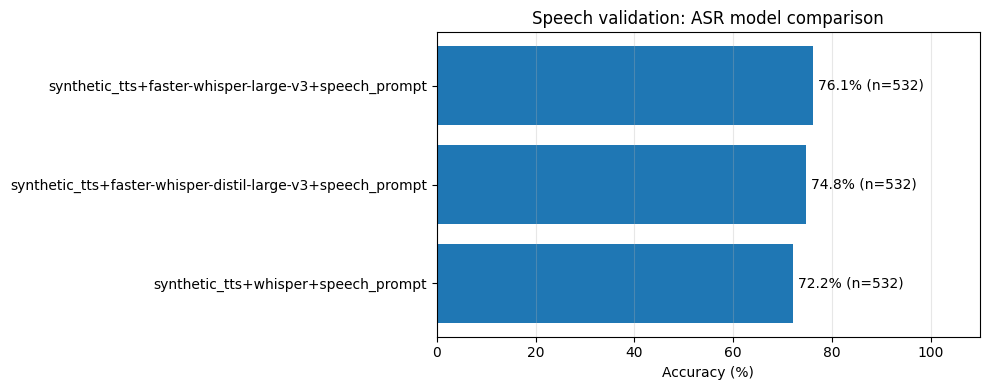

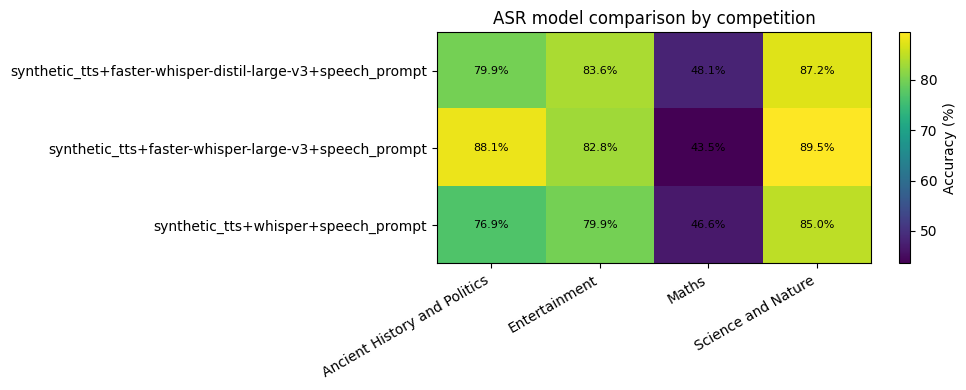

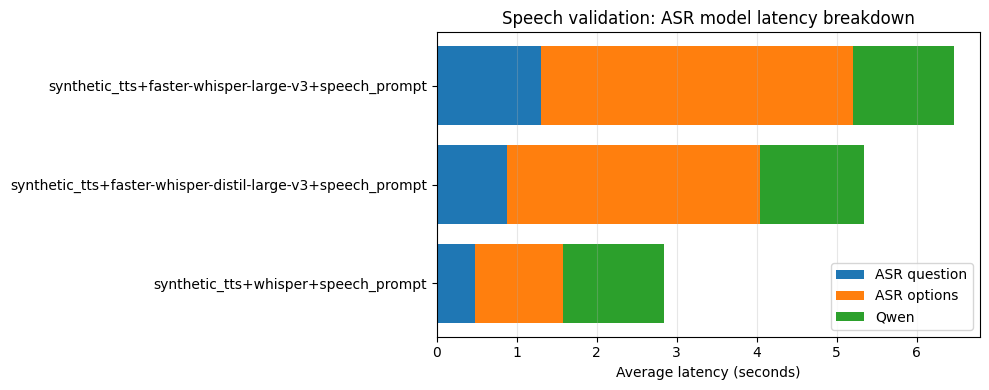

In [ ]:
speech_model_logs_df = load_flat_speech_logs(SPEECH_MODEL_LOGS_DIR)
speech_model_overall_df, speech_model_by_competition_df, speech_model_by_difficulty_df = summarize_validation_logs(speech_model_logs_df)

print(f"Loaded ASR-model validation rows: {len(speech_model_logs_df)}")
if len(speech_model_overall_df) > 0:
    display(speech_model_overall_df)
    plot_accuracy_bar(speech_model_overall_df, "Speech validation: ASR model comparison")
    plot_competition_heatmap(speech_model_by_competition_df, "ASR model comparison by competition")
    plot_validation_latency_breakdown(
        speech_model_overall_df,
        "Speech validation: ASR model latency breakdown",
    )
else:
    print("No ASR-model validation logs found. Check SPEECH_MODEL_LOGS_DIR above.")

## Prompt selection

After selecting the strongest ASR configuration, we compare prompt formats. The objective is to understand whether Qwen should be explicitly told that the input is a noisy ASR transcript. In our prompt-validation runs, the quiz-expert prompt is the best candidate: it gives Qwen a concise multiple-choice role and answer format without overcomplicating the instruction.




In [ ]:
LETTER_TO_ID = {"A": 0, "B": 1, "C": 2, "D": 3}
ID_TO_LETTER = {v: k for k, v in LETTER_TO_ID.items()}


def format_options(option_texts):
    return "\n".join(f"{ID_TO_LETTER[i]}: {text}" for i, text in enumerate(option_texts))


def build_prompt_minimal(question_text, option_texts):
    options = format_options(option_texts)
    return [{
        "role": "user",
        "content": f"Question: {question_text}\n\nOptions:\n{options}\n\nAnswer with only A, B, C, or D.",
    }]


def build_prompt_quiz_expert(question_text, option_texts):
    options = format_options(option_texts)
    return [
        {
            "role": "system",
            "content": "You are a quiz expert. Choose the correct multiple-choice answer. Reply with only A, B, C, or D.",
        },
        {
            "role": "user",
            "content": f"Question: {question_text}\n\nOptions:\n{options}\n\nAnswer:",
        },
    ]


def build_prompt_asr_aware(question_text, option_texts):
    options = format_options(option_texts)
    return [
        {
            "role": "system",
            "content": (
                "You are answering a multiple-choice quiz from automatic speech recognition transcripts. "
                "The question and options may contain ASR mistakes, especially names, dates, titles, and foreign terms. "
                "Choose the option that best matches the intended correct answer. Reply with only A, B, C, or D."
            ),
        },
        {
            "role": "user",
            "content": f"Question transcript: {question_text}\n\nOption transcripts:\n{options}\n\nAnswer:",
        },
    ]


def build_prompt_phonetic_recovery(question_text, option_texts):
    options = format_options(option_texts)
    return [
        {
            "role": "system",
            "content": (
                "You are solving a quiz from noisy speech transcripts. Some words may be phonetically wrong. "
                "Mentally recover likely names, places, song/movie/book titles, historical terms, and technical terms before choosing. "
                "Do not explain. Reply with exactly one letter: A, B, C, or D."
            ),
        },
        {
            "role": "user",
            "content": f"Noisy question: {question_text}\n\nNoisy options:\n{options}\n\nCorrect letter:",
        },
    ]


def build_prompt_conservative(question_text, option_texts):
    options = format_options(option_texts)
    return [
        {
            "role": "system",
            "content": (
                "Answer the multiple-choice question. The text comes from ASR and may contain errors. "
                "Use the option meanings and the question intent. If uncertain, choose the most plausible option. "
                "Output only A, B, C, or D."
            ),
        },
        {
            "role": "user",
            "content": f"{question_text}\n\n{options}",
        },
    ]


Loaded prompt-validation rows: 2005


,experiment_name,prompt_experiment_name,asr_backend,asr_model_id,accuracy,n_questions,parse_success_rate,avg_latency_seconds,avg_latency_asr_question,avg_latency_asr_options,avg_latency_llm
4,faster_whisper_large_v3+speech_quiz_expert,speech_quiz_expert,faster_whisper,large-v3,0.875312,401,1.0,5.676364,1.093307,3.607566,0.975491
2,faster_whisper_large_v3+speech_minimal,speech_minimal,faster_whisper,large-v3,0.862843,401,1.0,5.765585,1.093307,3.607566,1.064712
1,faster_whisper_large_v3+speech_conservative,speech_conservative,faster_whisper,large-v3,0.855362,401,1.0,5.695898,1.084939,3.486190,1.124769
0,faster_whisper_large_v3+speech_asr_aware,speech_asr_aware,faster_whisper,large-v3,0.845387,401,1.0,5.913086,1.093307,3.607566,1.212213
3,faster_whisper_large_v3+speech_phonetic_recovery,speech_phonetic_recovery,faster_whisper,large-v3,0.830424,401,1.0,5.829029,1.084939,3.486190,1.257900


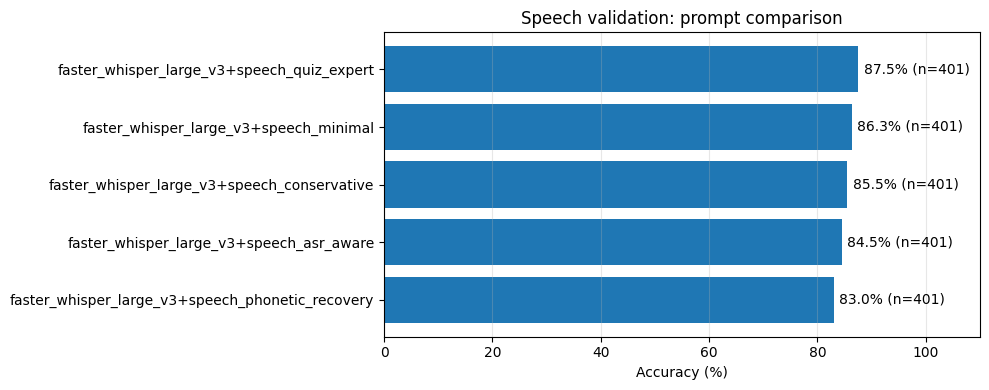

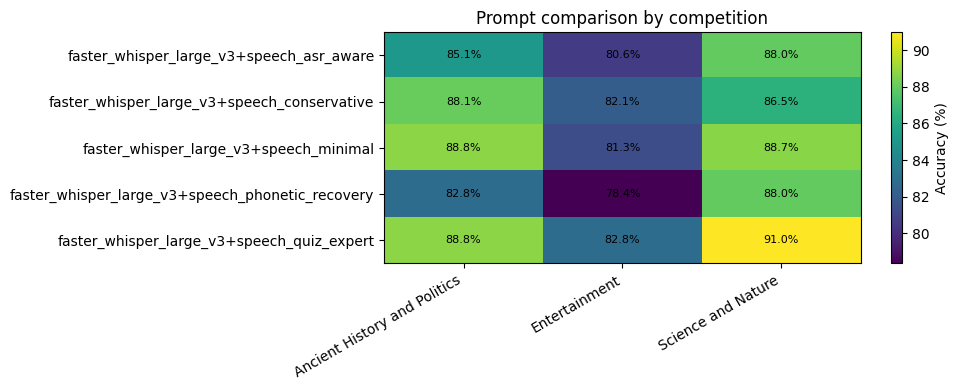

In [ ]:
speech_prompt_logs_df = load_flat_speech_logs(SPEECH_PROMPT_LOGS_DIR)
speech_prompt_overall_df, speech_prompt_by_competition_df, speech_prompt_by_difficulty_df = summarize_validation_logs(speech_prompt_logs_df)

print(f"Loaded prompt-validation rows: {len(speech_prompt_logs_df)}")
if len(speech_prompt_overall_df) > 0:
    display(speech_prompt_overall_df)
    plot_accuracy_bar(speech_prompt_overall_df, "Speech validation: prompt comparison")
    plot_competition_heatmap(speech_prompt_by_competition_df, "Prompt comparison by competition")
else:
    print("No prompt validation logs found. Check SPEECH_PROMPT_LOGS_DIR above.")


## Live games



The selected configuration combines the best ASR family with the best prompt family. The cells below provide a focused view of the selected ASR/prompt combination across competitions and latency components.

Selected validation rows: 401


,experiment_name,prompt_experiment_name,asr_backend,asr_model_id,accuracy,n_questions,parse_success_rate,avg_latency_seconds,avg_latency_asr_question,avg_latency_asr_options,avg_latency_llm
0,faster_whisper_large_v3+speech_quiz_expert,speech_quiz_expert,faster_whisper,large-v3,0.875312,401,1.0,5.676364,1.093307,3.607566,0.975491


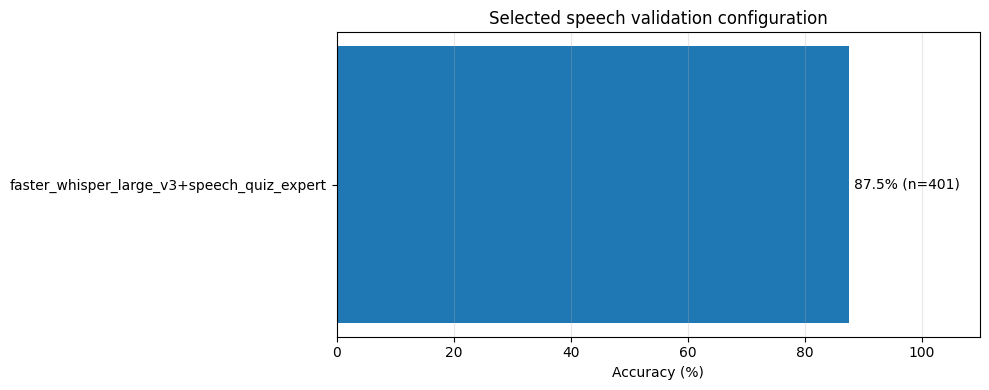

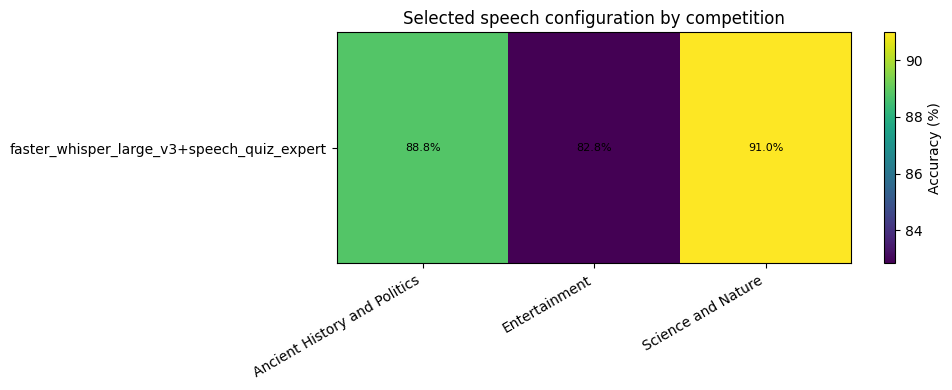

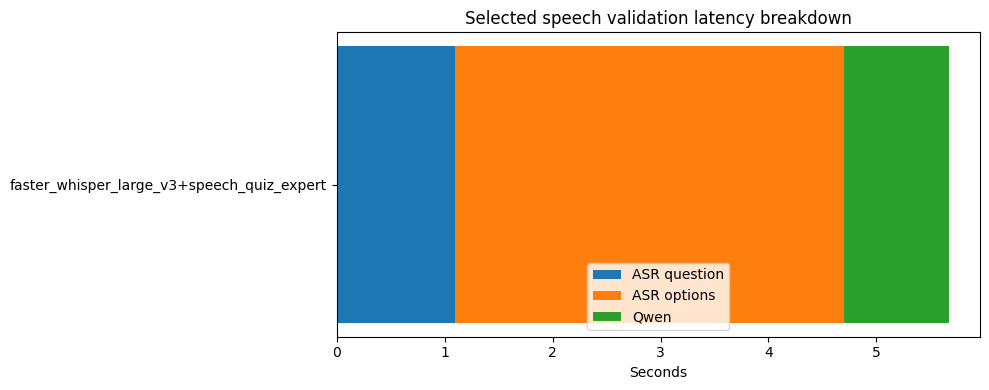

In [ ]:
def select_best_validation_rows(model_df, prompt_df):
    frames = []
    for df in [model_df, prompt_df]:
        if len(df) == 0:
            continue
        mask = df["experiment_name"].str.contains(BEST_ASR_EXPERIMENT_TAG, na=False)
        if "prompt_experiment_name" in df.columns:
            mask = mask & df["prompt_experiment_name"].eq(BEST_PROMPT_NAME)
        selected = df[mask].copy()
        if len(selected) > 0:
            frames.append(selected)
    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True).drop_duplicates(subset=["experiment_name", "question_id"])


best_validation_df = select_best_validation_rows(speech_model_logs_df, speech_prompt_logs_df)
best_validation_overall_df, best_validation_by_competition_df, best_validation_by_difficulty_df = summarize_validation_logs(best_validation_df)

print(f"Selected validation rows: {len(best_validation_df)}")
if len(best_validation_overall_df) > 0:
    display(best_validation_overall_df)
    plot_accuracy_bar(best_validation_overall_df, "Selected speech validation configuration")
    plot_competition_heatmap(best_validation_by_competition_df, "Selected speech configuration by competition")

    latency = best_validation_overall_df.set_index("experiment_name")[[
        "avg_latency_asr_question",
        "avg_latency_asr_options",
        "avg_latency_llm",
    ]]
    fig, ax = plt.subplots(figsize=(10, max(4, 0.45 * len(latency))))
    left = np.zeros(len(latency))
    for column, label in [
        ("avg_latency_asr_question", "ASR question"),
        ("avg_latency_asr_options", "ASR options"),
        ("avg_latency_llm", "Qwen"),
    ]:
        ax.barh(latency.index, latency[column], left=left, label=label)
        left += latency[column].values
    ax.set_title("Selected speech validation latency breakdown")
    ax.set_xlabel("Seconds")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No rows found for the selected ASR/prompt filters.")



The controlled validation benchmark is reproducible, but it uses synthetic TTS audio. The final check uses live PoliMillionaire games, where the audio is produced by the server and the whole system must answer inside the game loop. We compare the selected speech system against Qwen in text mode.

In [ ]:
def load_live_game_logs(log_dirs):
    if isinstance(log_dirs, (str, os.PathLike)):
        log_dirs = [log_dirs]

    rows = []
    question_rows = []

    for log_dir in log_dirs:
        if not os.path.exists(log_dir):
            print(f"Live log directory not found: {log_dir}")
            continue

        model_variant = os.path.relpath(log_dir, LIVE_SPEECH_LOGS_ROOT)
        for root, _, files in os.walk(log_dir):
            competition_folder = os.path.basename(root)
            if not competition_folder.startswith("competition"):
                continue
            try:
                competition_id = int(competition_folder.replace("competition", ""))
            except ValueError:
                competition_id = None
            competition = COMPETITION_ID_TO_NAME.get(competition_id, competition_folder)
            if competition in EXCLUDED_SPEECH_COMPETITIONS:
                continue

            for filename in sorted(files):
                if not filename.startswith("data_") or not filename.endswith(".json"):
                    continue
                path = os.path.join(root, filename)
                try:
                    with open(path, "r", encoding="utf-8") as f:
                        items = json.load(f)
                except Exception as e:
                    print(f"Skipping {path}: {e}")
                    continue

                answered = len(items)
                correct = sum(bool(item.get("inference", {}).get("is_correct")) for item in items)
                reached_level = max([item.get("question", {}).get("level", 0) or 0 for item in items], default=0)
                latency_llm = sum(float(item.get("inference", {}).get("inference_time", 0) or 0) for item in items)
                latency_asr_question = sum(float(item.get("inference", {}).get("asr_question_time", 0) or 0) for item in items)
                latency_asr_options = sum(sum(float(x or 0) for x in item.get("inference", {}).get("asr_options_times", [])) for item in items)

                rows.append({
                    "log_path": path,
                    "model_variant": model_variant,
                    "competition_id": competition_id,
                    "competition": competition,
                    "answered_questions": answered,
                    "correct_answers": correct,
                    "accuracy_answered": correct / answered if answered else 0,
                    "reached_level": reached_level,
                    "completed_game": answered >= 15 and correct >= 15,
                    "latency_llm_total": latency_llm,
                    "latency_asr_question_total": latency_asr_question,
                    "latency_asr_options_total": latency_asr_options,
                    "latency_total": latency_llm + latency_asr_question + latency_asr_options,
                })

                for item in items:
                    q = item.get("question", {})
                    inf = item.get("inference", {})
                    question_rows.append({
                        "log_path": path,
                        "model_variant": model_variant,
                        "competition_id": competition_id,
                        "competition": competition,
                        "level": q.get("level"),
                        "is_correct": bool(inf.get("is_correct")),
                        "is_warning": bool(inf.get("is_warning")),
                        "latency_llm": float(inf.get("inference_time", 0) or 0),
                        "latency_asr_question": float(inf.get("asr_question_time", 0) or 0),
                        "latency_asr_options": sum(float(x or 0) for x in inf.get("asr_options_times", [])),
                    })

    return pd.DataFrame(rows), pd.DataFrame(question_rows)


live_runs_df, live_questions_df = load_live_game_logs([LIVE_TEXT_BASELINE_DIR, LIVE_BEST_SPEECH_DIR])
print(f"Loaded live games: {len(live_runs_df)}")
print(f"Loaded live answered questions: {len(live_questions_df)}")


Loaded live games: 360
Loaded live answered questions: 1980


,model_variant,games,avg_reached_level,median_reached_level,avg_answered,avg_accuracy_answered,completed_games,avg_latency_total
1,Qwen/Qwen2.5-7B-Instruct-text-baseline,180,6.083333,4.0,6.083333,0.591761,24,8.163180
0,Qwen/Qwen2.5-7B-Instruct-speech-faster-whisper...,180,4.916667,3.0,4.916667,0.555362,11,28.676194


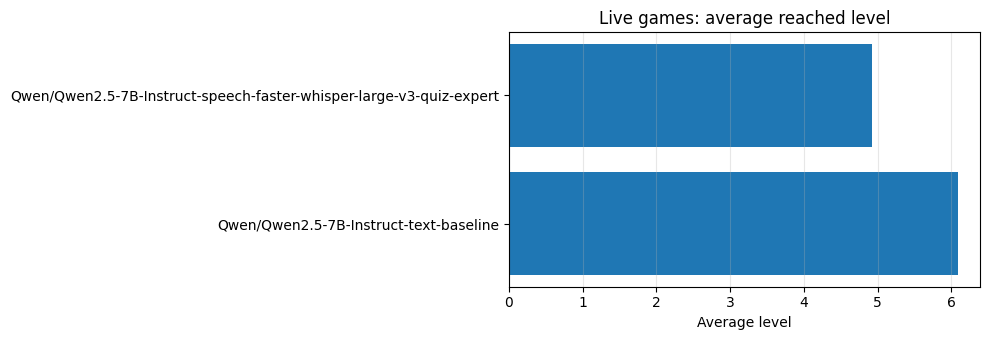

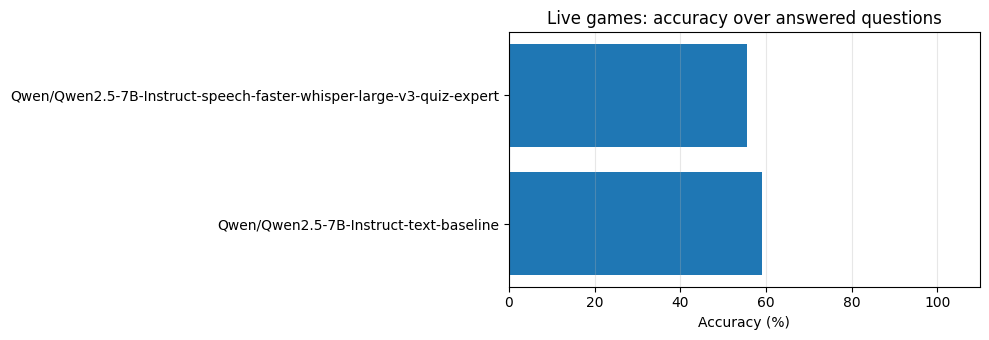

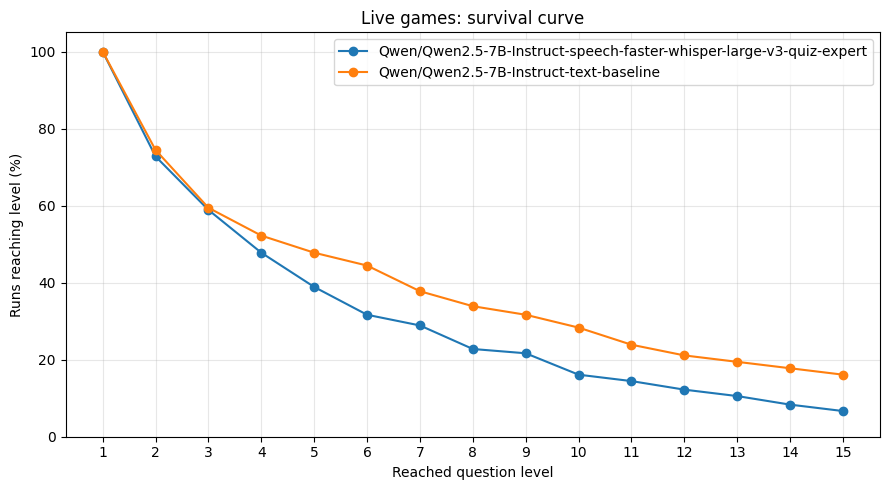

In [ ]:
def plot_live_game_summary(live_runs_df):
    if len(live_runs_df) == 0:
        print("No live game logs loaded yet. Check LIVE_TEXT_BASELINE_DIR and LIVE_BEST_SPEECH_DIR above.")
        return pd.DataFrame()

    summary = (
        live_runs_df.groupby("model_variant", as_index=False)
        .agg(
            games=("log_path", "count"),
            avg_reached_level=("reached_level", "mean"),
            median_reached_level=("reached_level", "median"),
            avg_answered=("answered_questions", "mean"),
            avg_accuracy_answered=("accuracy_answered", "mean"),
            completed_games=("completed_game", "sum"),
            avg_latency_total=("latency_total", "mean"),
        )
        .sort_values("avg_reached_level", ascending=False)
    )
    display(summary)

    order = summary["model_variant"]

    fig, ax = plt.subplots(figsize=(10, max(3.5, 0.6 * len(summary))))
    ax.barh(order, summary["avg_reached_level"])
    ax.set_title("Live games: average reached level")
    ax.set_xlabel("Average level")
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(10, max(3.5, 0.6 * len(summary))))
    ax.barh(order, summary["avg_accuracy_answered"] * 100)
    ax.set_title("Live games: accuracy over answered questions")
    ax.set_xlabel("Accuracy (%)")
    ax.set_xlim(0, 110)
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()

    survival_rows = []
    for model_variant, group in live_runs_df.groupby("model_variant"):
        for level in range(1, 16):
            survival_rows.append({
                "model_variant": model_variant,
                "level": level,
                "survival_rate": (group["answered_questions"] >= level).mean(),
            })
    survival_df = pd.DataFrame(survival_rows)

    fig, ax = plt.subplots(figsize=(9, 5))
    for model_variant, group in survival_df.groupby("model_variant"):
        ax.plot(group["level"], group["survival_rate"] * 100, marker="o", label=model_variant)
    ax.set_title("Live games: survival curve")
    ax.set_xlabel("Reached question level")
    ax.set_ylabel("Runs reaching level (%)")
    ax.set_xticks(range(1, 16))
    ax.set_ylim(0, 105)
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

    return summary


live_summary_df = plot_live_game_summary(live_runs_df)


# 9. Chatbot

In [ ]:
def router_solve_final(question, competition, llm_model, tokenizer, verbose=False, embedder=None):
    if competition == "News":
        return solve_rag_with_news(
            question=question,
            competition=competition,
            llm_model=llm_model,
            tokenizer=tokenizer,
            verbose=verbose,
        )
    elif competition == "Maths":
        return solve_math_with_router(
            question=question,
            competition=competition,
            llm_model=llm_model,
            tokenizer=tokenizer,
            verbose=verbose,
        )
    else:
        return solve_with_rag(
            question=question,
            competition=competition,
            llm_model=llm_model,
            tokenizer=tokenizer,
            verbose=verbose,
            embedder=embedder
        )

# 10. Final Analysis


The final evaluation is based on live PoliMillionaire games.

This section visualizes how the model performs: how far the final model gets in each competition, how often it completes a game, and where the remaining failures happen.


In [ ]:
# ============================================================
# Final live-game log paths
# ============================================================

# Drive/Colab uses final_logs/live_games. Some local exports may still use
# final_logs/final_live_games, so keep both as candidates.
FINAL_GAME_LOGS_CANDIDATES = [
    os.path.join(WORKING_DIR, "final_logs", "live_games"),
    os.path.join(WORKING_DIR, "final_logs", "final_live_games"),
]
FINAL_GAME_LOGS_DIR = next(
    (path for path in FINAL_GAME_LOGS_CANDIDATES if os.path.exists(path)),
    FINAL_GAME_LOGS_CANDIDATES[0],
)

FINAL_RAG_LIVE_DIR = os.path.join(
    FINAL_GAME_LOGS_DIR,
    "llm_queries_bm25top100_embeddertop100_rrftop5_Qwen_Qwen2.5-7B-Instruct",
)
FINAL_MATH_LIVE_DIR = os.path.join(
    FINAL_GAME_LOGS_DIR,
    "math_final_model_Qwen_Qwen2.5-7B-Instruct",
)
FINAL_NEWS_LIVE_DIR = os.path.join(
    FINAL_GAME_LOGS_DIR,
    "news_final_model_Qwen_Qwen2.5B-7B-Instruct",
)
FINAL_LIVE_LOG_DIRS = [
    FINAL_RAG_LIVE_DIR,
    FINAL_MATH_LIVE_DIR,
    FINAL_NEWS_LIVE_DIR,
]

print("Final live-game logs root:", FINAL_GAME_LOGS_DIR)
print("Final RAG live logs      :", FINAL_RAG_LIVE_DIR)
print("Final Maths live logs    :", FINAL_MATH_LIVE_DIR)
print("Final News live logs     :", FINAL_NEWS_LIVE_DIR)

Final live-game logs root: /content/gdrive/MyDrive/NLP_assignment/final_logs/live_games
Final RAG live logs      : /content/gdrive/MyDrive/NLP_assignment/final_logs/live_games/llm_queries_bm25top100_embeddertop100_rrftop5_Qwen_Qwen2.5-7B-Instruct
Final Maths live logs    : /content/gdrive/MyDrive/NLP_assignment/final_logs/live_games/math_final_model_Qwen_Qwen2.5-7B-Instruct
Final News live logs     : /content/gdrive/MyDrive/NLP_assignment/final_logs/live_games/news_final_model_Qwen_Qwen2.5B-7B-Instruct


In [ ]:
def load_jsonl_recursive(root_dirs):
    """Recursively load JSONL files from one or more directories."""
    if isinstance(root_dirs, (str, os.PathLike)):
        root_dirs = [root_dirs]

    rows = []
    for root_dir in root_dirs:
        if not os.path.exists(root_dir):
            print(f"Live log directory not found: {root_dir}")
            continue

        for current_root, _, files in os.walk(root_dir):
            for filename in sorted(files):
                if not filename.endswith(".json"):
                    continue
                path = os.path.join(current_root, filename)
                with open(path, "r", encoding="utf-8") as f:
                    for line in f:
                        if not line.strip():
                            continue
                        row = json.loads(line)
                        row["source_log_path"] = path
                        row["model_variant"] = os.path.relpath(root_dir, FINAL_GAME_LOGS_DIR)
                        row["competition_folder"] = os.path.basename(os.path.dirname(path))
                        rows.append(row)
    return pd.DataFrame(rows)


def normalize_final_live_logs(df):
    if len(df) == 0:
        return df, df

    df = df.copy()
    df["competition"] = df["competition"].replace({
        "Nature and Science": "Science and Nature",
    })

    game_df = df[df["row_type"].eq("game_summary")].copy()
    question_df = df[df["row_type"].eq("question")].copy()

    if len(game_df) > 0:
        game_df["completed_game"] = game_df["level_reached"].fillna(0).astype(float).ge(15)
        game_df["failure_reason"] = game_df["failure_reason"].fillna("completed")

    if len(question_df) > 0:
        question_df["is_correct"] = question_df["is_correct"].astype(bool)
        question_df["timed_out"] = question_df.get("timed_out", False)
        question_df["failure_reason"] = question_df["failure_reason"].fillna("none")
        question_df["question_level"] = question_df["question"].apply(
            lambda q: q.get("level") if isinstance(q, dict) else np.nan
        )
        question_df["question_text"] = question_df["question"].apply(
            lambda q: q.get("question_text", q.get("text", "")) if isinstance(q, dict) else ""
        )

    return game_df, question_df


final_live_rows_df = load_jsonl_recursive(FINAL_LIVE_LOG_DIRS)
final_game_df, final_question_df = normalize_final_live_logs(final_live_rows_df)

print(f"Loaded final live rows      : {len(final_live_rows_df)}")
print(f"Loaded game summaries       : {len(final_game_df)}")
print(f"Loaded answered question rows: {len(final_question_df)}")

if len(final_game_df) > 0:
    display(final_game_df[["model_variant", "competition", "run_id", "level_reached", "failure_reason"]])


Loaded final live rows      : 1708
Loaded game summaries       : 187
Loaded answered question rows: 1521


,model_variant,competition,run_id,level_reached,failure_reason
0,llm_queries_bm25top100_embeddertop100_rrftop5_...,Entertainment,20260602_030605_50858dbf,15.0,completed
16,llm_queries_bm25top100_embeddertop100_rrftop5_...,Entertainment,20260602_030605_50858dbf,13.0,wrong
31,llm_queries_bm25top100_embeddertop100_rrftop5_...,Entertainment,20260602_030605_50858dbf,0.0,wrong
33,llm_queries_bm25top100_embeddertop100_rrftop5_...,Entertainment,20260602_030605_50858dbf,6.0,wrong
41,llm_queries_bm25top100_embeddertop100_rrftop5_...,Entertainment,20260602_030605_50858dbf,8.0,wrong
...,...,...,...,...,...
1667,news_final_model_Qwen_Qwen2.5B-7B-Instruct,News,20260602_174742_08082ebd,7.0,wrong
1676,news_final_model_Qwen_Qwen2.5B-7B-Instruct,News,20260602_174742_08082ebd,6.0,wrong
1684,news_final_model_Qwen_Qwen2.5B-7B-Instruct,News,20260602_174742_08082ebd,0.0,wrong
1686,news_final_model_Qwen_Qwen2.5B-7B-Instruct,News,20260602_174742_08082ebd,15.0,completed


## Final live-game overview

The table and charts below summarize the live runs. The most important quantity is `level_reached`: a value of 15 means the model completed the whole game for that competition. Since these are live games, each row captures not only answer accuracy but also retrieval latency, parsing, server timing, and failure handling.


In [ ]:
def summarize_final_games(game_df, question_df):
    if len(game_df) == 0:
        return pd.DataFrame()

    summary = (
        game_df
        .groupby(["model_variant", "competition"], as_index=False)
        .agg(
            games=("run_id", "count"),
            avg_level_reached=("level_reached", "mean"),
            median_level_reached=("level_reached", "median"),
            completed_games=("completed_game", "sum"),
            last_failure_reason=("failure_reason", lambda s: ", ".join(sorted(set(s))))
        )
    )
    summary["completion_rate"] = summary["completed_games"] / summary["games"]

    if len(question_df) > 0:
        q_summary = (
            question_df
            .groupby(["model_variant", "competition"], as_index=False)
            .agg(
                answered_questions=("is_correct", "size"),
                question_accuracy=("is_correct", "mean"),
                avg_latency_seconds=("latency_seconds", "mean"),
            )
        )
        summary = summary.merge(q_summary, on=["model_variant", "competition"], how="left")

    return summary.sort_values(["model_variant", "competition"])


final_live_summary_df = summarize_final_games(final_game_df, final_question_df)
if len(final_live_summary_df) > 0:
    display(final_live_summary_df)
else:
    print("No final live game summaries found. Check FINAL_LIVE_LOG_DIRS above.")


,model_variant,competition,games,avg_level_reached,median_level_reached,completed_games,last_failure_reason,completion_rate,answered_questions,question_accuracy,avg_latency_seconds
0,llm_queries_bm25top100_embeddertop100_rrftop5_...,Ancient History and Politics,30,9.10000,9.5,8,"completed, timeout, wrong",0.266667,295,0.925424,21.323372
1,llm_queries_bm25top100_embeddertop100_rrftop5_...,Entertainment,30,7.40000,6.5,6,"completed, wrong",0.200000,246,0.902439,21.662090
2,llm_queries_bm25top100_embeddertop100_rrftop5_...,Philosophy and Psychology,30,12.20000,15.0,19,"completed, wrong",0.633333,377,0.970822,21.006486
3,llm_queries_bm25top100_embeddertop100_rrftop5_...,Science and Nature,30,8.60000,8.0,8,"completed, wrong",0.266667,280,0.921429,21.030089
4,math_final_model_Qwen_Qwen2.5-7B-Instruct,Maths,30,2.80000,2.0,0,wrong,0.000000,114,0.736842,20.260960
5,news_final_model_Qwen_Qwen2.5B-7B-Instruct,News,37,4.72973,4.0,3,"completed, timeout, wrong",0.081081,209,0.837321,17.533972


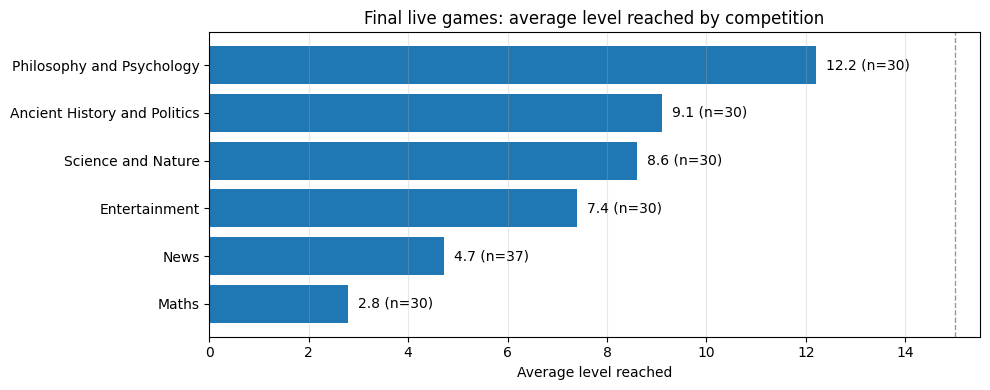

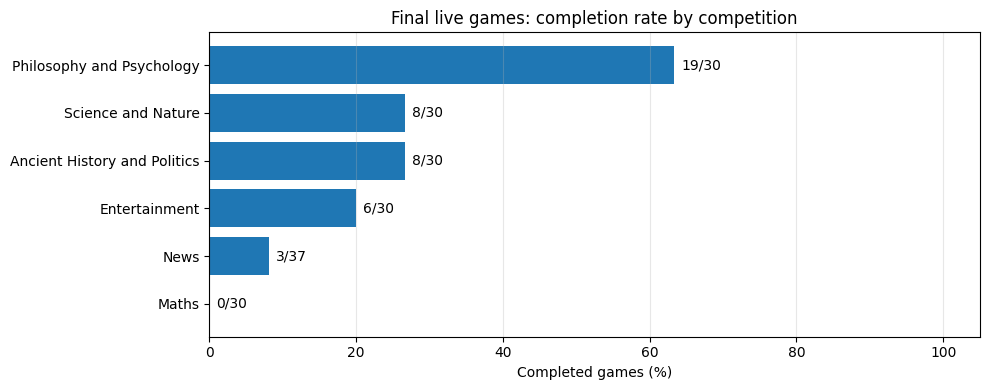

In [ ]:
def plot_final_level_reached(summary_df):
    if len(summary_df) == 0:
        return

    plot_df = summary_df.sort_values("avg_level_reached", ascending=True)
    labels = plot_df["competition"]

    fig, ax = plt.subplots(figsize=(10, max(4, 0.6 * len(plot_df))))
    bars = ax.barh(labels, plot_df["avg_level_reached"])
    ax.set_title("Final live games: average level reached by competition")
    ax.set_xlabel("Average level reached")
    ax.set_xlim(0, 15.5)
    ax.axvline(15, linestyle="--", linewidth=1, color="gray", alpha=0.8)
    ax.grid(axis="x", alpha=0.3)

    for bar, value, games in zip(bars, plot_df["avg_level_reached"], plot_df["games"]):
        ax.text(value + 0.2, bar.get_y() + bar.get_height() / 2, f"{value:.1f} (n={games})", va="center")

    plt.tight_layout()
    plt.show()


def plot_final_completion_rate(summary_df):
    if len(summary_df) == 0:
        return

    plot_df = summary_df.sort_values("completion_rate", ascending=True)
    labels = plot_df["competition"]

    fig, ax = plt.subplots(figsize=(10, max(4, 0.6 * len(plot_df))))
    bars = ax.barh(labels, plot_df["completion_rate"] * 100)
    ax.set_title("Final live games: completion rate by competition")
    ax.set_xlabel("Completed games (%)")
    ax.set_xlim(0, 105)
    ax.grid(axis="x", alpha=0.3)

    for bar, value, completed, games in zip(bars, plot_df["completion_rate"], plot_df["completed_games"], plot_df["games"]):
        ax.text(value * 100 + 1, bar.get_y() + bar.get_height() / 2, f"{completed}/{games}", va="center")

    plt.tight_layout()
    plt.show()


plot_final_level_reached(final_live_summary_df)
plot_final_completion_rate(final_live_summary_df)


## Survival and per-question behavior

A single wrong answer ends a PoliMillionaire game, so accuracy alone is not enough: early mistakes matter much more than late mistakes. The survival curve shows the percentage of final live runs that reach each question level. The per-question chart then shows where the model is reliable and where the final failure happened.


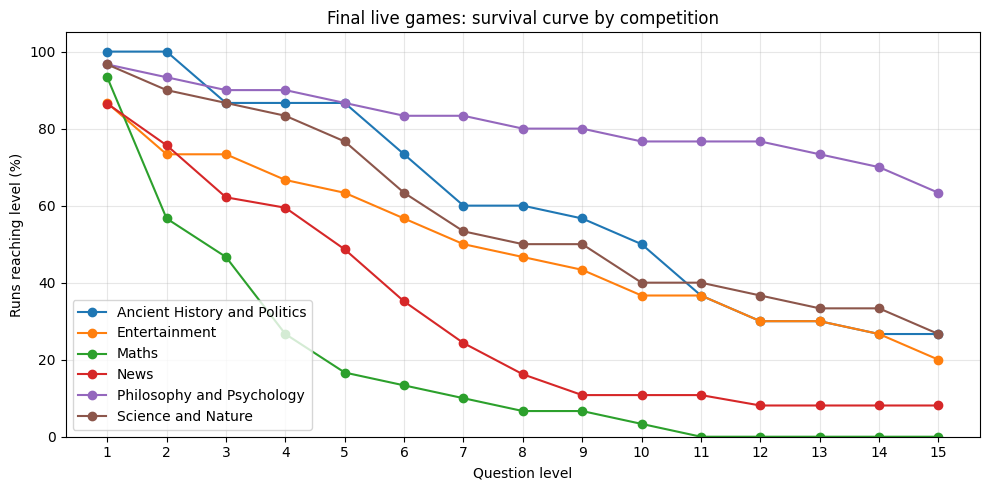

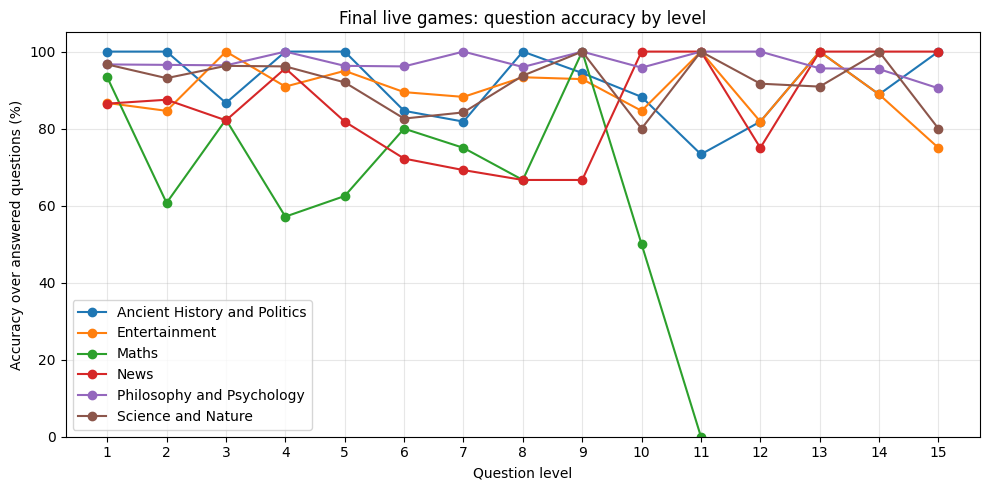

In [ ]:
def plot_final_survival_curve(game_df):
    if len(game_df) == 0:
        return

    survival_rows = []
    for competition, group in game_df.groupby("competition"):
        for level in range(1, 16):
            survival_rows.append({
                "competition": competition,
                "level": level,
                "survival_rate": group["level_reached"].ge(level).mean(),
            })
    survival_df = pd.DataFrame(survival_rows)

    fig, ax = plt.subplots(figsize=(10, 5))
    for competition, group in survival_df.groupby("competition"):
        ax.plot(group["level"], group["survival_rate"] * 100, marker="o", label=competition)
    ax.set_title("Final live games: survival curve by competition")
    ax.set_xlabel("Question level")
    ax.set_ylabel("Runs reaching level (%)")
    ax.set_xticks(range(1, 16))
    ax.set_ylim(0, 105)
    ax.grid(alpha=0.3)
    ax.legend(loc="best")
    plt.tight_layout()
    plt.show()


def plot_final_question_accuracy(question_df):
    if len(question_df) == 0:
        return

    level_df = (
        question_df
        .dropna(subset=["question_level"])
        .groupby(["competition", "question_level"], as_index=False)
        .agg(
            accuracy=("is_correct", "mean"),
            n_questions=("is_correct", "size"),
        )
    )

    if len(level_df) == 0:
        print("No question-level information available.")
        return

    fig, ax = plt.subplots(figsize=(10, 5))
    for competition, group in level_df.groupby("competition"):
        ax.plot(group["question_level"], group["accuracy"] * 100, marker="o", label=competition)
    ax.set_title("Final live games: question accuracy by level")
    ax.set_xlabel("Question level")
    ax.set_ylabel("Accuracy over answered questions (%)")
    ax.set_xticks(range(1, 16))
    ax.set_ylim(0, 105)
    ax.grid(alpha=0.3)
    ax.legend(loc="best")
    plt.tight_layout()
    plt.show()

plot_final_survival_curve(final_game_df)
plot_final_question_accuracy(final_question_df)


## Latency and remaining failures

The final model, other than being correct, also needs to answer before the server timer expires. The latency plot separates competitions and model variants, making it easier to see whether failures are caused by model errors or by the cost of retrieval/code execution.


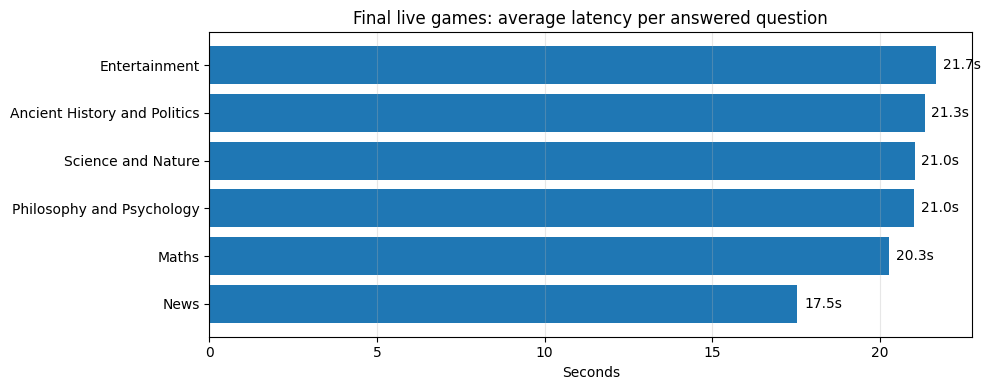

,failure_reason,n_games
1,wrong,137
0,timeout,6


,competition,failure_reason,n_games
1,Ancient History and Politics,wrong,21
0,Ancient History and Politics,timeout,1
2,Entertainment,wrong,24
3,Maths,wrong,30
5,News,wrong,29
4,News,timeout,5
6,Philosophy and Psychology,wrong,11
7,Science and Nature,wrong,22


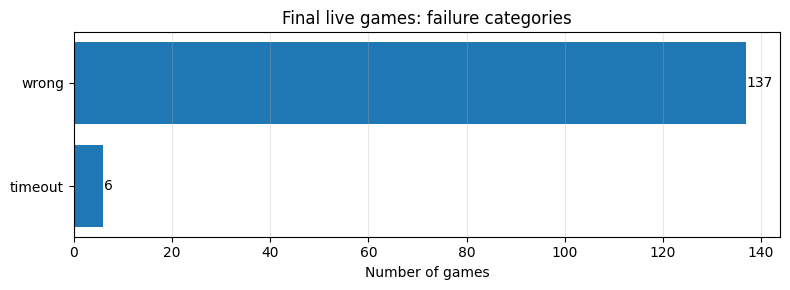

In [ ]:
def plot_final_latency(summary_df):
    if len(summary_df) == 0 or "avg_latency_seconds" not in summary_df.columns:
        return

    plot_df = summary_df.dropna(subset=["avg_latency_seconds"]).sort_values("avg_latency_seconds", ascending=True)
    if len(plot_df) == 0:
        print("No latency data available.")
        return

    labels = plot_df["competition"]
    fig, ax = plt.subplots(figsize=(10, max(4, 0.6 * len(plot_df))))
    bars = ax.barh(labels, plot_df["avg_latency_seconds"])
    ax.set_title("Final live games: average latency per answered question")
    ax.set_xlabel("Seconds")
    ax.grid(axis="x", alpha=0.3)

    for bar, value in zip(bars, plot_df["avg_latency_seconds"]):
        ax.text(value + 0.2, bar.get_y() + bar.get_height() / 2, f"{value:.1f}s", va="center")

    plt.tight_layout()
    plt.show()


def display_final_failure_summary(game_df):
    if len(game_df) == 0:
        return

    failed_games = game_df[~game_df["completed_game"]].copy()
    if len(failed_games) == 0:
        print("All final live games were completed.")
        return

    failure_counts = (
        failed_games
        .groupby("failure_reason", dropna=False)
        .size()
        .reset_index(name="n_games")
        .sort_values("n_games", ascending=False)
    )
    display(failure_counts)

    failure_by_competition = (
        failed_games
        .groupby(["competition", "failure_reason"], dropna=False)
        .size()
        .reset_index(name="n_games")
        .sort_values(["competition", "n_games"], ascending=[True, False])
    )
    display(failure_by_competition)

    fig, ax = plt.subplots(figsize=(8, max(3, 0.5 * len(failure_counts))))
    bars = ax.barh(failure_counts["failure_reason"], failure_counts["n_games"])
    ax.set_title("Final live games: failure categories")
    ax.set_xlabel("Number of games")
    ax.invert_yaxis()
    ax.grid(axis="x", alpha=0.3)

    for bar, value in zip(bars, failure_counts["n_games"]):
        ax.text(value + 0.05, bar.get_y() + bar.get_height() / 2, int(value), va="center")

    plt.tight_layout()
    plt.show()

plot_final_latency(final_live_summary_df)
display_final_failure_summary(final_game_df)

## Final takeaway

The final system combines different strategies. For most categories, the model uses Qwen with LLM-generated search queries, BM25 and embedding candidate retrieval, reciprocal-rank fusion and reranking. The model for the Mathematics category uses a separate final router/code-oriented model, because arithmetic and symbolic questions benefit from a different solution path.

The live-game plots above show how far the system gets in each competition, which games were completed, where failures remain, and if latency is compatible with the online setting.
